In [1]:
import os

print(os.listdir('/kaggle/input'))

['competitions']


In [2]:
for item in os.listdir('/kaggle/input'):
    print(item)

competitions


In [3]:
BASE_PATH = '/kaggle/input/competitions/rsna-knee-abnormality-detection'

print(os.listdir(BASE_PATH))

['test_series.csv', 'train_series.csv', 'sample_submission.csv', 'test_series', 'train_series', 'train.csv', 'test.csv']


In [4]:
import pandas as pd
import os

train = pd.read_csv(os.path.join(BASE_PATH, "train.csv"))

print("Shape:", train.shape)
print("\nColumns:")
print(train.columns.tolist())

display(train.head())

Shape: (4407, 14)

Columns:
['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   StudyInstanceUID  4407 non-null   object 
 1   Report            4407 non-null   object 
 2   ACL               58 non-null     float64
 3   MCL               58 non-null     float64
 4   Medial Meniscus   58 non-null     float64
 5   Lateral Meniscus  58 non-null     float64
 6   Medial OA         58 non-null     float64
 7   Lateral OA        58 non-null     float64
 8   PF OA             58 non-null     float64
 9   Effusion          58 non-null     float64
 10  Synovitis         58 non-null     float64
 11  Baker's           58 non-null     float64
 12  Contusion         58 non-null     float64
 13  Fracture          58 non-null     float64
dtypes: float64(12), object(2)
memory usage: 482.1+ KB


In [6]:
print(train[['ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
             'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
             'Synovitis', "Baker's", 'Contusion', 'Fracture']].notna().sum())

ACL                 58
MCL                 58
Medial Meniscus     58
Lateral Meniscus    58
Medial OA           58
Lateral OA          58
PF OA               58
Effusion            58
Synovitis           58
Baker's             58
Contusion           58
Fracture            58
dtype: int64


In [7]:
display(train[train['ACL'].notna()].head())

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
29,1.2.826.0.1.3680043.8.498.10095687747295410396...,Antecedentes Clínicos:\nEsguince rodilla. [DAT...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
63,1.2.826.0.1.3680043.8.498.10170898615867673028...,The study reveals normal knee joint alignment...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
109,1.2.826.0.1.3680043.8.498.10306159113324811538...,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Da...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
445,1.2.826.0.1.3680043.8.498.11287937729196958426...,"MRI of left Knee with \n-3-Plane Loc R'T, Sag ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
470,1.2.826.0.1.3680043.8.498.11382021393803389951...,"In the medial compartment, there is longitudi...",1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
train_series = pd.read_csv(
    os.path.join(BASE_PATH, "train_series.csv")
)

print("Shape:", train_series.shape)
print("Columns:", train_series.columns.tolist())

display(train_series.head())

Shape: (24371, 5)
Columns: ['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal


In [9]:
train_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24371 entries, 0 to 24370
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   StudyInstanceUID   24371 non-null  object
 1   SeriesInstanceUID  24371 non-null  object
 2   Fluid_Sensitive    24371 non-null  int64 
 3   Fat_Suppression    24371 non-null  int64 
 4   Anatomical_Plane   24371 non-null  object
dtypes: int64(2), object(3)
memory usage: 952.1+ KB


In [10]:
train_series['Anatomical_Plane'].value_counts()

Anatomical_Plane
Sagittal    9864
Coronal     8609
Axial       5898
Name: count, dtype: int64

In [11]:
train_series['Fluid_Sensitive'].value_counts()

Fluid_Sensitive
1    14010
0    10361
Name: count, dtype: int64

In [12]:
train_series['Fat_Suppression'].value_counts()

Fat_Suppression
1    14010
0    10361
Name: count, dtype: int64

In [13]:
series_per_study = train_series.groupby('StudyInstanceUID').size()

print(series_per_study.describe())

count    4407.000000
mean        5.530066
std         1.393826
min         3.000000
25%         5.000000
50%         5.000000
75%         6.000000
max        14.000000
dtype: float64


In [14]:
labeled_study = train[train['ACL'].notna()].iloc[0]['StudyInstanceUID']

print(labeled_study)

1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149


In [15]:
study_series = train_series[
    train_series['StudyInstanceUID'] == labeled_study
]

print(study_series.shape)
display(study_series)

(5, 5)


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
163,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.10791858932231443712...,0,0,Sagittal
164,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.12451507871565834868...,0,0,Coronal
165,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
166,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
167,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial


In [16]:
series_uid = study_series.iloc[3]['SeriesInstanceUID']

print(series_uid)

1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429


In [17]:
study_uid = labeled_study

print("Study UID:", study_uid)
print("Series UID:", series_uid)

Study UID: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149
Series UID: 1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429


In [18]:
series_path = os.path.join(
    BASE_PATH,
    "train_series",
    study_uid,
    series_uid
)

print(series_path)
print(os.path.exists(series_path))

/kaggle/input/competitions/rsna-knee-abnormality-detection/train_series/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429
True


In [19]:
dicom_files = sorted(os.listdir(series_path))

print("Number of files:", len(dicom_files))
print("First 5 files:", dicom_files[:5])

Number of files: 36
First 5 files: ['1.2.826.0.1.3680043.8.498.10510575059177468411555373275759922508.dcm', '1.2.826.0.1.3680043.8.498.10952016037843177599128697353782635584.dcm', '1.2.826.0.1.3680043.8.498.11173384594863599162701922864860545586.dcm', '1.2.826.0.1.3680043.8.498.11412319853384360156851724961091181876.dcm', '1.2.826.0.1.3680043.8.498.11674795861279575960305380899707531245.dcm']


In [20]:
import pydicom
import os

slices = []

for file in dicom_files:
    path = os.path.join(series_path, file)
    ds = pydicom.dcmread(path)
    slices.append(ds)

print("Number of slices:", len(slices))
print("Image shape:", slices[0].pixel_array.shape)

Number of slices: 36
Image shape: (320, 320)


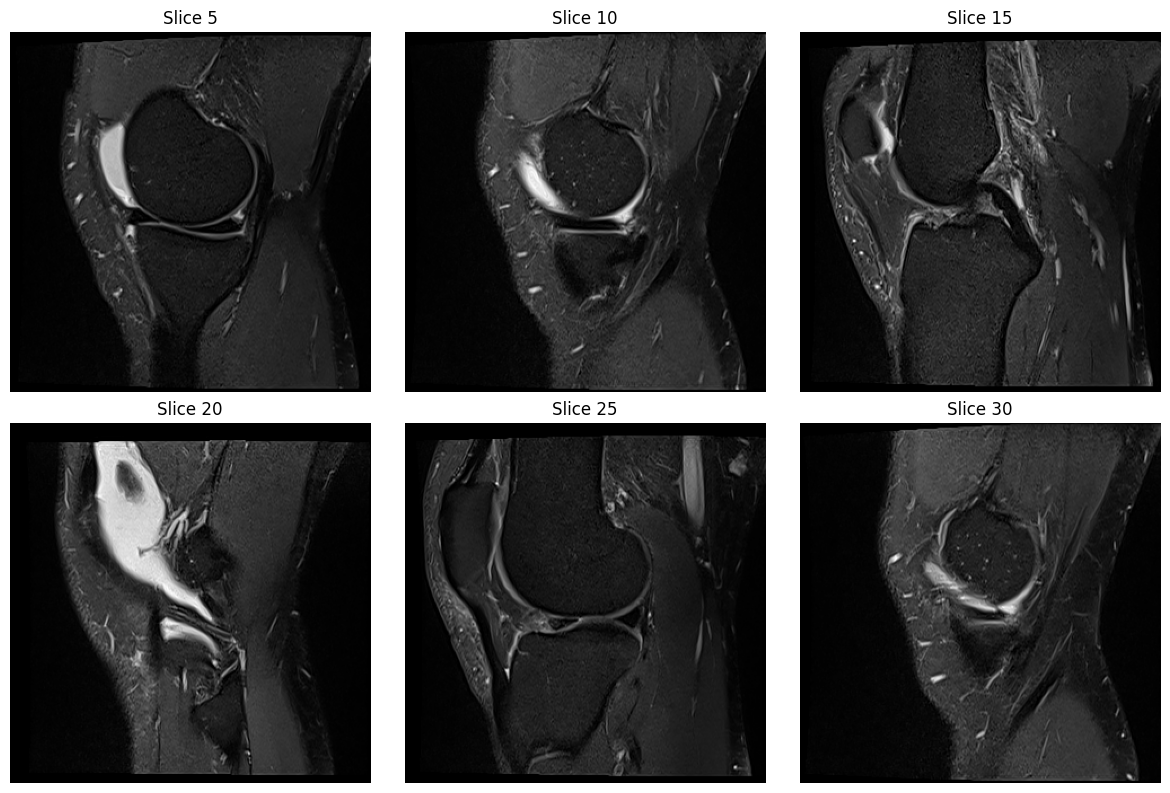

In [21]:
import matplotlib.pyplot as plt

indices = [5, 10, 15, 20, 25, 30]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, i in zip(axes.ravel(), indices):
    ax.imshow(slices[i].pixel_array, cmap='gray')
    ax.set_title(f"Slice {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
study_info = train[train['StudyInstanceUID'] == study_uid]

display(
    study_info[
        ['StudyInstanceUID', 'Report', 'ACL', 'MCL',
         'Medial Meniscus', 'Lateral Meniscus',
         'Medial OA', 'Lateral OA', 'PF OA',
         'Effusion', 'Synovitis', "Baker's",
         'Contusion', 'Fracture']
    ]
)

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
29,1.2.826.0.1.3680043.8.498.10095687747295410396...,Antecedentes Clínicos:\nEsguince rodilla. [DAT...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


In [23]:
label_cols = [
    'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
    'Medial OA', 'Lateral OA', 'PF OA',
    'Effusion', 'Synovitis', "Baker's",
    'Contusion', 'Fracture'
]

label_counts = train[label_cols].dropna().sum().sort_values(ascending=False)

print("Number of positive cases:")
display(label_counts)

Number of positive cases:


Effusion            35.0
Synovitis           27.0
Medial Meniscus     26.0
ACL                 24.0
Lateral Meniscus    23.0
PF OA               21.0
Contusion           19.0
Fracture            18.0
Medial OA           15.0
Baker's             12.0
Lateral OA          11.0
MCL                  9.0
dtype: float64

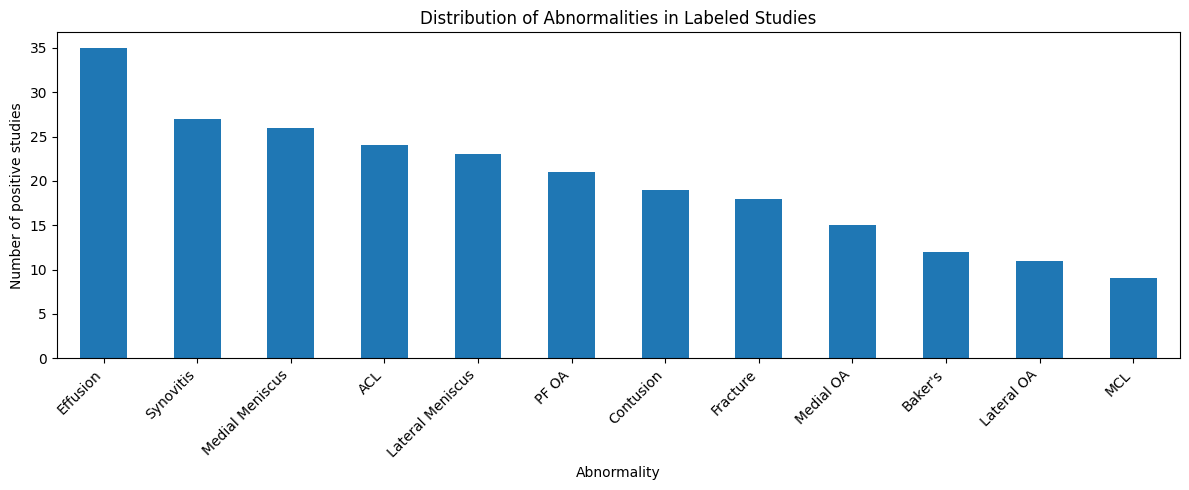

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.ylabel("Number of positive studies")
plt.xlabel("Abnormality")
plt.title("Distribution of Abnormalities in Labeled Studies")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
print("Total studies:", train['StudyInstanceUID'].nunique())
print("Labeled studies:", train[train['ACL'].notna()]['StudyInstanceUID'].nunique())
print("Total series:", train_series['SeriesInstanceUID'].nunique())

Total studies: 4407
Labeled studies: 58
Total series: 24371


In [26]:
print("Missing labels:")
display(train[label_cols].isna().sum())

Missing labels:


ACL                 4349
MCL                 4349
Medial Meniscus     4349
Lateral Meniscus    4349
Medial OA           4349
Lateral OA          4349
PF OA               4349
Effusion            4349
Synovitis           4349
Baker's             4349
Contusion           4349
Fracture            4349
dtype: int64

In [27]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt

In [28]:
def load_dicom_series(series_path):
#    Load all DICOM files from a series and sort them using DICOM spatial metadata.
    dicom_slices = []
    for filename in os.listdir(series_path):
        filepath = os.path.join(series_path, filename)
        try:
            ds = pydicom.dcmread(filepath)
            # Make sure the file contains image data
            if hasattr(ds, "PixelData"):
                dicom_slices.append(ds)
        except Exception as e:
            print(f"Could not read {filename}: {e}")
    # Sort using ImagePositionPatient when available
    if all(hasattr(ds, "ImagePositionPatient") for ds in dicom_slices):
        dicom_slices.sort(key=lambda ds: float(ds.ImagePositionPatient[2]))
    # Otherwise fall back to InstanceNumber
    elif all(hasattr(ds, "InstanceNumber") for ds in dicom_slices):
        dicom_slices.sort( key=lambda ds: int(ds.InstanceNumber))

    return dicom_slices

In [29]:
ordered_slices = load_dicom_series(series_path)

print("Number of slices:", len(ordered_slices))
print("Image shape:", ordered_slices[0].pixel_array.shape)

Number of slices: 36
Image shape: (320, 320)


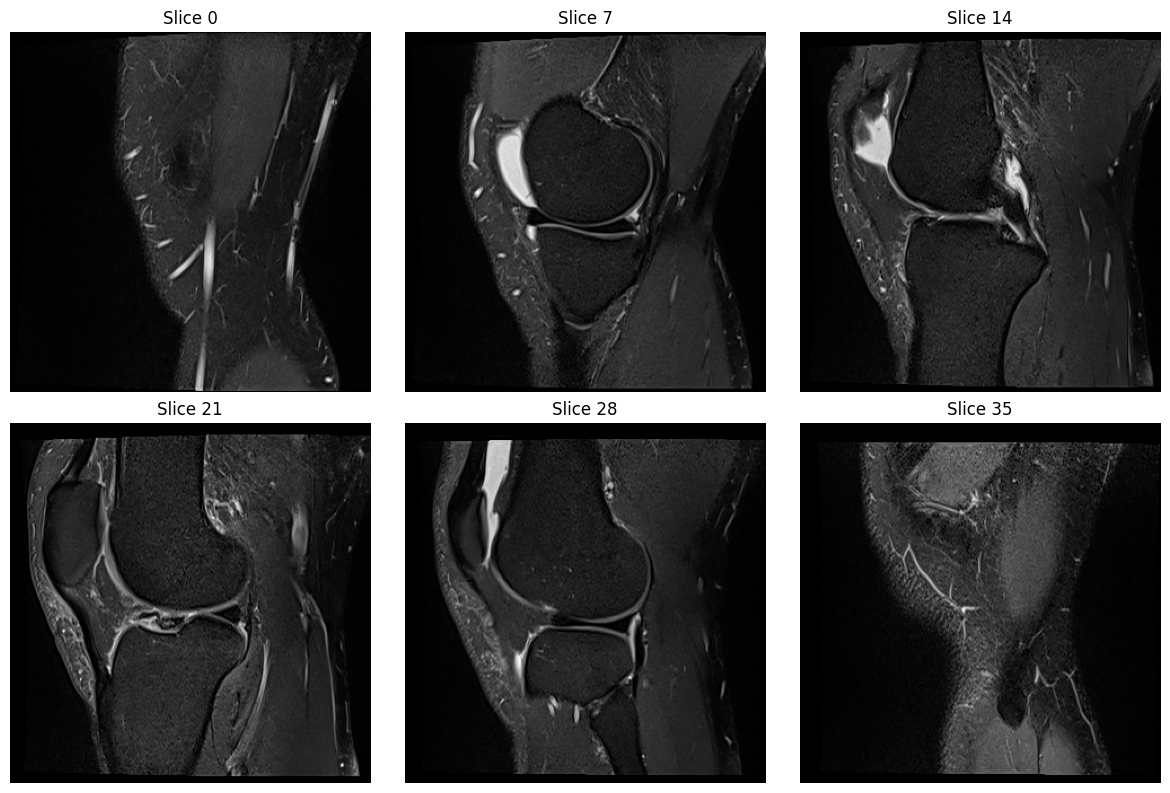

In [30]:
indices = np.linspace(
    0,
    len(ordered_slices) - 1,
    6,
    dtype=int
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, i in zip(axes.ravel(), indices):
    ax.imshow(
        ordered_slices[i].pixel_array,
        cmap="gray"
    )
    ax.set_title(f"Slice {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [31]:
ds = ordered_slices[len(ordered_slices)//2]

metadata_fields = [
    "PatientID",
    "StudyInstanceUID",
    "SeriesInstanceUID",
    "Modality",
    "Manufacturer",
    "MagneticFieldStrength",
    "SliceThickness",
    "SpacingBetweenSlices",
    "PixelSpacing",
    "ImageOrientationPatient",
    "ImagePositionPatient",
    "InstanceNumber",
    "Rows",
    "Columns"
]

for field in metadata_fields:
    if hasattr(ds, field):
        print(f"{field}: {getattr(ds, field)}")

PatientID: e0f1600d-2e2
StudyInstanceUID: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149
SeriesInstanceUID: 1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429
Modality: MR
Manufacturer: Siemens Healthineers
MagneticFieldStrength: 1.5
SliceThickness: 2.5
SpacingBetweenSlices: 2.875
PixelSpacing: [0.5, 0.5]
ImageOrientationPatient: [-0.0703218, 0.987788, 0.139034, -0.109149, 0.130922, -0.985366]
ImagePositionPatient: [-96.3461, -141.06, 85.8924]
InstanceNumber: 18
Rows: 320
Columns: 320


In [32]:
def get_pixel_array(dicom_slices):
   # Convert DICOM slices into a NumPy array.
    images = []
    for ds in dicom_slices:
        image = ds.pixel_array.astype(np.float32)
        images.append(image)
    return np.stack(images)

In [33]:
volume = get_pixel_array(ordered_slices)

print("Volume shape:", volume.shape)
print("Data type:", volume.dtype)
print("Minimum:", volume.min())
print("Maximum:", volume.max())

Volume shape: (36, 320, 320)
Data type: float32
Minimum: 0.0
Maximum: 788.0


In [34]:
def normalize_volume(volume):    
    lower = np.percentile(volume, 1)
    upper = np.percentile(volume, 99)
    volume = np.clip(volume, lower, upper)
    volume = (volume - lower) / (upper - lower + 1e-8)
    return volume

In [35]:
normalized_volume = normalize_volume(volume)

print("Minimum:", normalized_volume.min())
print("Maximum:", normalized_volume.max())

Minimum: 0.0
Maximum: 1.0


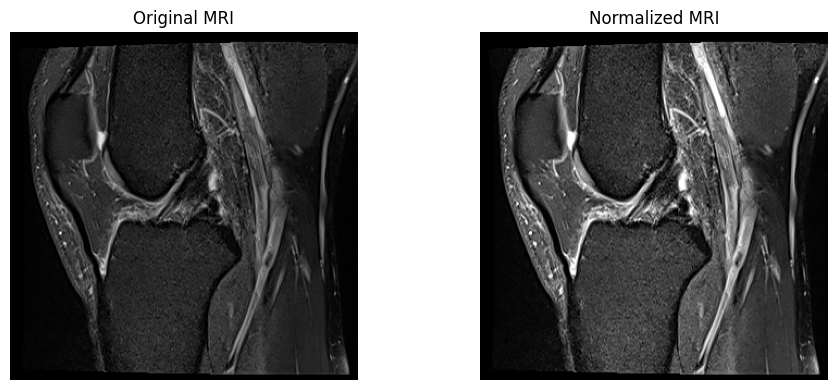

In [36]:
middle = len(normalized_volume) // 2

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(
    volume[middle],
    cmap="gray"
)
plt.title("Original MRI")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(
    normalized_volume[middle],
    cmap="gray"
)
plt.title("Normalized MRI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
def get_candidate_series(study_uid, train_series):    
    candidates = train_series[
        (train_series["StudyInstanceUID"] == study_uid) &
        (train_series["Fluid_Sensitive"] == 1) &
        (train_series["Fat_Suppression"] == 1)
    ].copy()
    
    return candidates

In [38]:
candidates = get_candidate_series(study_uid, train_series)

print("Study UID:", study_uid)
print("Number of candidate series:", len(candidates))

display(candidates)

Study UID: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149
Number of candidate series: 3


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
165,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
166,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
167,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial


In [39]:
display(
    candidates[
        ["SeriesInstanceUID",
         "Fluid_Sensitive",
         "Fat_Suppression",
         "Anatomical_Plane"]
    ]
)

,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
165,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
166,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
167,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial


In [40]:
def get_candidate_series(study_uid, train_series):
    candidates = train_series[
        (train_series["StudyInstanceUID"] == study_uid) &
        (train_series["Fluid_Sensitive"] == 1) &
        (train_series["Fat_Suppression"] == 1)
    ].copy()

    return candidates

In [41]:
label_columns = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

labeled_studies = train.dropna(
    subset=label_columns
).copy()

print("Number of labeled studies:", len(labeled_studies))

Number of labeled studies: 58


In [42]:
candidate_series = train_series[
    (train_series["StudyInstanceUID"].isin(
        labeled_studies["StudyInstanceUID"]
    )) &
    (train_series["Fluid_Sensitive"] == 1) &
    (train_series["Fat_Suppression"] == 1)
].copy()

print("Candidate series:", len(candidate_series))

display(
    candidate_series[
        [
            "StudyInstanceUID",
            "SeriesInstanceUID",
            "Fluid_Sensitive",
            "Fat_Suppression",
            "Anatomical_Plane"
        ]
    ].head(20)
)

Candidate series: 192


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
165,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,1,1,Coronal
166,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,1,1,Sagittal
167,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,1,1,Axial
353,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.25511961362790207336...,1,1,Axial
355,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.45571369239262736508...,1,1,Coronal
357,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.55642842745139279565...,1,1,Sagittal
358,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.71876353677262220297...,1,1,Axial
611,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.10903465965639594231...,1,1,Sagittal
613,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.19770471468778499025...,1,1,Axial
614,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.28095032587022735220...,1,1,Coronal


In [43]:
print(
    candidate_series["Anatomical_Plane"]
    .value_counts()
)

Anatomical_Plane
Coronal     65
Sagittal    64
Axial       63
Name: count, dtype: int64


In [44]:
# Show the abnormality labels for the first few labeled studies

display(
    labeled_studies[
        ["StudyInstanceUID"] + label_columns
    ].head(10)
)

,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
29,1.2.826.0.1.3680043.8.498.10095687747295410396...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
63,1.2.826.0.1.3680043.8.498.10170898615867673028...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
109,1.2.826.0.1.3680043.8.498.10306159113324811538...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
445,1.2.826.0.1.3680043.8.498.11287937729196958426...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
470,1.2.826.0.1.3680043.8.498.11382021393803389951...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
533,1.2.826.0.1.3680043.8.498.11548045715264151632...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
537,1.2.826.0.1.3680043.8.498.11557620559191469069...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
607,1.2.826.0.1.3680043.8.498.11771393824519892797...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
632,1.2.826.0.1.3680043.8.498.11851412923016044948...,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
656,1.2.826.0.1.3680043.8.498.11915937982684988073...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0


In [45]:
# Check which anatomical planes are available for each labeled study

plane_availability = (
    candidate_series
    .groupby("StudyInstanceUID")["Anatomical_Plane"]
    .apply(lambda x: ", ".join(sorted(x.unique())))
    .reset_index()
)

display(plane_availability.head(10))

,StudyInstanceUID,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,"Axial, Coronal, Sagittal"
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,"Axial, Coronal, Sagittal"
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,"Axial, Coronal, Sagittal"
3,1.2.826.0.1.3680043.8.498.11287937729196958426...,"Axial, Coronal, Sagittal"
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,"Axial, Coronal, Sagittal"
5,1.2.826.0.1.3680043.8.498.11548045715264151632...,"Axial, Coronal, Sagittal"
6,1.2.826.0.1.3680043.8.498.11557620559191469069...,"Axial, Coronal, Sagittal"
7,1.2.826.0.1.3680043.8.498.11771393824519892797...,"Axial, Coronal, Sagittal"
8,1.2.826.0.1.3680043.8.498.11851412923016044948...,"Axial, Coronal, Sagittal"
9,1.2.826.0.1.3680043.8.498.11915937982684988073...,"Axial, Coronal, Sagittal"


In [46]:
# Count how many studies have each combination of planes

plane_combination_counts = (
    plane_availability["Anatomical_Plane"]
    .value_counts()
)

print(plane_combination_counts)

Anatomical_Plane
Axial, Coronal, Sagittal    54
Axial, Sagittal              2
Axial, Coronal               2
Name: count, dtype: int64


In [47]:
# Check number of candidate series per plane for each study

series_per_plane = (
    candidate_series
    .groupby(["StudyInstanceUID", "Anatomical_Plane"])
    .size()
    .reset_index(name="Number_of_Series")
)

display(series_per_plane.head(20))

,StudyInstanceUID,Anatomical_Plane,Number_of_Series
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,Axial,1
1,1.2.826.0.1.3680043.8.498.10095687747295410396...,Coronal,1
2,1.2.826.0.1.3680043.8.498.10095687747295410396...,Sagittal,1
3,1.2.826.0.1.3680043.8.498.10170898615867673028...,Axial,2
4,1.2.826.0.1.3680043.8.498.10170898615867673028...,Coronal,1
5,1.2.826.0.1.3680043.8.498.10170898615867673028...,Sagittal,1
6,1.2.826.0.1.3680043.8.498.10306159113324811538...,Axial,2
7,1.2.826.0.1.3680043.8.498.10306159113324811538...,Coronal,2
8,1.2.826.0.1.3680043.8.498.10306159113324811538...,Sagittal,1
9,1.2.826.0.1.3680043.8.498.11287937729196958426...,Axial,1


In [48]:
print(
    series_per_plane["Number_of_Series"].value_counts()
)

Number_of_Series
1    149
2     20
3      1
Name: count, dtype: int64


In [49]:
# Find study-plane combinations with more than one candidate series

multiple_series = series_per_plane[
    series_per_plane["Number_of_Series"] > 1
].copy()

print("Study-plane combinations with multiple series:",
      len(multiple_series))

display(multiple_series)

Study-plane combinations with multiple series: 21


,StudyInstanceUID,Anatomical_Plane,Number_of_Series
3,1.2.826.0.1.3680043.8.498.10170898615867673028...,Axial,2
6,1.2.826.0.1.3680043.8.498.10306159113324811538...,Axial,2
7,1.2.826.0.1.3680043.8.498.10306159113324811538...,Coronal,2
11,1.2.826.0.1.3680043.8.498.11287937729196958426...,Sagittal,2
13,1.2.826.0.1.3680043.8.498.11382021393803389951...,Coronal,3
16,1.2.826.0.1.3680043.8.498.11548045715264151632...,Coronal,2
23,1.2.826.0.1.3680043.8.498.11771393824519892797...,Sagittal,2
30,1.2.826.0.1.3680043.8.498.12448079646359892252...,Axial,2
37,1.2.826.0.1.3680043.8.498.12606657226568558340...,Coronal,2
47,1.2.826.0.1.3680043.8.498.13267780356245120052...,Sagittal,2


In [50]:
# Show the actual candidate series for the duplicated study-plane combinations

duplicate_series = candidate_series.merge(
    multiple_series[
        ["StudyInstanceUID", "Anatomical_Plane"]
    ],
    on=["StudyInstanceUID", "Anatomical_Plane"],
    how="inner"
)

display(
    duplicate_series[
        [
            "StudyInstanceUID",
            "SeriesInstanceUID",
            "Fluid_Sensitive",
            "Fat_Suppression",
            "Anatomical_Plane"
        ]
    ]
)

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.25511961362790207336...,1,1,Axial
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.71876353677262220297...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.19770471468778499025...,1,1,Axial
3,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.28095032587022735220...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.51945041305607216480...,1,1,Coronal
5,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.52935759841844767282...,1,1,Axial
6,1.2.826.0.1.3680043.8.498.11287937729196958426...,1.2.826.0.1.3680043.8.498.10819304863029245505...,1,1,Sagittal
7,1.2.826.0.1.3680043.8.498.11287937729196958426...,1.2.826.0.1.3680043.8.498.93698495301744954009...,1,1,Sagittal
8,1.2.826.0.1.3680043.8.498.11382021393803389951...,1.2.826.0.1.3680043.8.498.10450090035285223893...,1,1,Coronal
9,1.2.826.0.1.3680043.8.498.11382021393803389951...,1.2.826.0.1.3680043.8.498.29866461247060130198...,1,1,Coronal


In [51]:
def count_dicom_slices(series_path):
    #Count DICOM files in a series directory.
    
    count = 0

    for filename in os.listdir(series_path):
        filepath = os.path.join(series_path, filename)

        try:
            ds = pydicom.dcmread(filepath)

            if hasattr(ds, "PixelData"):
                count += 1

        except:
            pass

    return count

In [52]:
# Count slices for the duplicated candidate series

slice_counts = []

for _, row in duplicate_series.iterrows():

    series_path = os.path.join(
        BASE_PATH,
        "train_series",
        row["StudyInstanceUID"],
        row["SeriesInstanceUID"]
    )

    count = count_dicom_slices(series_path)

    slice_counts.append(count)

duplicate_series = duplicate_series.copy()
duplicate_series["Number_of_Slices"] = slice_counts

display(
    duplicate_series[
        [
            "StudyInstanceUID",
            "SeriesInstanceUID",
            "Anatomical_Plane",
            "Number_of_Slices"
        ]
    ]
)

,StudyInstanceUID,SeriesInstanceUID,Anatomical_Plane,Number_of_Slices
0,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.25511961362790207336...,Axial,16
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.71876353677262220297...,Axial,40
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.19770471468778499025...,Axial,40
3,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.28095032587022735220...,Coronal,32
4,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.51945041305607216480...,Coronal,30
5,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.52935759841844767282...,Axial,30
6,1.2.826.0.1.3680043.8.498.11287937729196958426...,1.2.826.0.1.3680043.8.498.10819304863029245505...,Sagittal,19
7,1.2.826.0.1.3680043.8.498.11287937729196958426...,1.2.826.0.1.3680043.8.498.93698495301744954009...,Sagittal,19
8,1.2.826.0.1.3680043.8.498.11382021393803389951...,1.2.826.0.1.3680043.8.498.10450090035285223893...,Coronal,16
9,1.2.826.0.1.3680043.8.498.11382021393803389951...,1.2.826.0.1.3680043.8.498.29866461247060130198...,Coronal,16


In [53]:
# Take the first study with multiple series in the same plane

example_study = multiple_series.iloc[0]["StudyInstanceUID"]
example_plane = multiple_series.iloc[0]["Anatomical_Plane"]

print("Study:", example_study)
print("Plane:", example_plane)

display(
    duplicate_series[
        (duplicate_series["StudyInstanceUID"] == example_study) &
        (duplicate_series["Anatomical_Plane"] == example_plane)
    ]
)

Study: 1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269
Plane: Axial


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane,Number_of_Slices
0,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.25511961362790207336...,1,1,Axial,16
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.71876353677262220297...,1,1,Axial,40


In [54]:
# Inspect metadata of the two candidate series

example_candidates = duplicate_series[
    (duplicate_series["StudyInstanceUID"] == example_study) &
    (duplicate_series["Anatomical_Plane"] == example_plane)
]

for _, row in example_candidates.iterrows():

    series_path = os.path.join(
        BASE_PATH,
        "train_series",
        row["StudyInstanceUID"],
        row["SeriesInstanceUID"]
    )

    slices = load_dicom_series(series_path)
    ds = slices[len(slices) // 2]

    print("\n-----------------------------")
    print("Series UID:", row["SeriesInstanceUID"])
    print("Plane:", row["Anatomical_Plane"])
    print("Number of slices:", len(slices))
    print("Image shape:", ds.pixel_array.shape)

    for field in [
        "SliceThickness",
        "SpacingBetweenSlices",
        "PixelSpacing",
        "MagneticFieldStrength",
        "ImageOrientationPatient"
    ]:
        if hasattr(ds, field):
            print(f"{field}: {getattr(ds, field)}")


-----------------------------
Series UID: 1.2.826.0.1.3680043.8.498.25511961362790207336672525814885780079
Plane: Axial
Number of slices: 16
Image shape: (480, 480)
SliceThickness: 2.5
SpacingBetweenSlices: 3
PixelSpacing: [0.27083334326744, 0.27083334326744]
MagneticFieldStrength: 3
ImageOrientationPatient: [0.98052859306335, -0.1944152116775, -0.0276844855397, 0.18223179876804, 0.84828066825866, 0.49720367789268]

-----------------------------
Series UID: 1.2.826.0.1.3680043.8.498.71876353677262220297725143243928050962
Plane: Axial
Number of slices: 40
Image shape: (640, 640)
SliceThickness: 3
SpacingBetweenSlices: 3.3
PixelSpacing: [0.25, 0.25]
MagneticFieldStrength: 3
ImageOrientationPatient: [0.98052859306335, -0.1944152116775, -0.0276844967156, 0.19526775181293, 0.98021465539932, 0.03239994868636]


In [55]:
# Compare additional DICOM information for the duplicate series

for _, row in example_candidates.iterrows():

    series_path = os.path.join(
        BASE_PATH,
        "train_series",
        row["StudyInstanceUID"],
        row["SeriesInstanceUID"]
    )

    slices = load_dicom_series(series_path)
    ds = slices[len(slices) // 2]

    print("\n==============================")
    print("Series UID:", row["SeriesInstanceUID"])
    print("Plane:", row["Anatomical_Plane"])

    for field in [
        "SeriesDescription",
        "SequenceName",
        "ScanningSequence",
        "SequenceVariant",
        "MRAcquisitionType",
        "RepetitionTime",
        "EchoTime",
        "FlipAngle"
    ]:
        if hasattr(ds, field):
            print(f"{field}: {getattr(ds, field)}")


Series UID: 1.2.826.0.1.3680043.8.498.25511961362790207336672525814885780079
Plane: Axial
SeriesDescription: RT.COR ACL T2W FS
ScanningSequence: SE
SequenceVariant: SK
MRAcquisitionType: 2D
RepetitionTime: 2500
EchoTime: 75
FlipAngle: 90

Series UID: 1.2.826.0.1.3680043.8.498.71876353677262220297725143243928050962
Plane: Axial
SeriesDescription: RT.Tra_T2W_TSE_SPAIR
ScanningSequence: SE
SequenceVariant: SK
MRAcquisitionType: 2D
RepetitionTime: 3987.607421875
EchoTime: 83.008
FlipAngle: 90


In [56]:
# Compare the series descriptions of all duplicate candidate series

for _, row in duplicate_series.iterrows():

    series_path = os.path.join(
        BASE_PATH,
        "train_series",
        row["StudyInstanceUID"],
        row["SeriesInstanceUID"]
    )

    try:
        slices = load_dicom_series(series_path)
        ds = slices[len(slices) // 2]

        description = getattr(
            ds,
            "SeriesDescription",
            "Not available"
        )

        print(
            f"{row['Anatomical_Plane']:8} | "
            f"{len(slices):3} slices | "
            f"{description}"
        )

    except Exception as e:
        print("Error:", e)

Axial    |  16 slices | RT.COR ACL T2W FS
Axial    |  40 slices | RT.Tra_T2W_TSE_SPAIR
Axial    |  40 slices | Ax T2 FSE FS_sm_AIRS
Coronal  |  32 slices | Cor T2 FSE FS_sm_AIRS
Coronal  |  30 slices | cor STIR_sm_AIRS
Axial    |  30 slices | ax STIR_sm_AIRS
Sagittal |  19 slices | Sag T2 FS
Sagittal |  19 slices | Sag PD FS
Coronal  |  16 slices | LT_t2_tse_fs_cor_obl_PCL
Coronal  |  16 slices | LT_t2_tse_fs_cor_obl_ACL
Coronal  |  30 slices | LT_pd_tse_fs_cor
Coronal  |  18 slices | RT.COR ACL T2W FS
Coronal  |  30 slices | RT.Cor_PDW_TSE_SPAIR
Sagittal |  24 slices | SG PD FatSat
Sagittal |  24 slices | SG T2W FS
Axial    |  12 slices | AXI T2 SPIR SENSE
Axial    |  22 slices | STIR_aTSE_TR_16 SENSE
Coronal  |  16 slices | LT.COR ACL T2W FS
Coronal  |  30 slices | LT.Cor_PDW_TSE_SPAIR
Sagittal |  19 slices | Sag T2 fs
Sagittal |  19 slices | Sag PD  F/S
Coronal  |  30 slices | DummySeriesDesc!
Sagittal |  28 slices | DummySeriesDesc!
Sagittal |  28 slices | DummySeriesDesc!
Coronal 

In [57]:
# Count the different series descriptions

print(
    duplicate_series.shape[0],
    "duplicate candidate series found."
)

series_descriptions = []

for _, row in duplicate_series.iterrows():

    series_path = os.path.join(
        BASE_PATH,
        "train_series",
        row["StudyInstanceUID"],
        row["SeriesInstanceUID"]
    )

    try:
        slices = load_dicom_series(series_path)

        if len(slices) > 0:
            ds = slices[len(slices) // 2]

            description = getattr(
                ds,
                "SeriesDescription",
                "Unknown"
            )

            series_descriptions.append(description)

    except Exception as e:
        print("Error:", e)

print("\nUnique Series Descriptions:\n")

for description in sorted(set(series_descriptions)):
    print(description)

43 duplicate candidate series found.

Unique Series Descriptions:

AXI DP SPIR
AXI STIR F
AXI T2 SPIR SENSE
Ax T2 FSE FS_sm_AIRS
Cor T2 FSE FS_sm_AIRS
DummySeriesDesc!
LT.COR ACL T2W FS
LT.COR PDW_TSE_SPAIR
LT.Cor_PDW_TSE_SPAIR
LT.OBL_ACLT2W_FS
LT_pd_tse_fs_cor
LT_t2_tse_fs_cor_obl_ACL
LT_t2_tse_fs_cor_obl_PCL
PDW_SPIR
RT.COR ACL T2W FS
RT.Cor_PDW_TSE_SPAIR
RT.Tra_T2W_TSE_SPAIR
SG PD FatSat
SG T2W FS
STIR_aTSE_TR_16 SENSE
Sag PD  F/S
Sag PD FS
Sag PD frFSE
Sag T2 FS
Sag T2 fs
Sag T2W frFSE FS
ax STIR_sm_AIRS
cor STIR_sm_AIRS
pd_tse_fs_cor_d


In [58]:
# Count the different series descriptions
# among our candidate series

from collections import Counter

description_counts = Counter(series_descriptions)

for description, count in description_counts.most_common():
    print(f"{count:2}  |  {description}")

 4  |  DummySeriesDesc!
 3  |  RT.COR ACL T2W FS
 3  |  Sag T2 FS
 3  |  Sag PD FS
 2  |  RT.Cor_PDW_TSE_SPAIR
 2  |  AXI T2 SPIR SENSE
 2  |  STIR_aTSE_TR_16 SENSE
 2  |  PDW_SPIR
 2  |  pd_tse_fs_cor_d
 1  |  RT.Tra_T2W_TSE_SPAIR
 1  |  Ax T2 FSE FS_sm_AIRS
 1  |  Cor T2 FSE FS_sm_AIRS
 1  |  cor STIR_sm_AIRS
 1  |  ax STIR_sm_AIRS
 1  |  LT_t2_tse_fs_cor_obl_PCL
 1  |  LT_t2_tse_fs_cor_obl_ACL
 1  |  LT_pd_tse_fs_cor
 1  |  SG PD FatSat
 1  |  SG T2W FS
 1  |  LT.COR ACL T2W FS
 1  |  LT.Cor_PDW_TSE_SPAIR
 1  |  Sag T2 fs
 1  |  Sag PD  F/S
 1  |  LT.COR PDW_TSE_SPAIR
 1  |  LT.OBL_ACLT2W_FS
 1  |  Sag T2W frFSE FS
 1  |  Sag PD frFSE
 1  |  AXI DP SPIR
 1  |  AXI STIR F


In [59]:
# Get SeriesDescription for all candidate series

all_series_info = []

for _, row in candidate_series.iterrows():

    series_path = os.path.join(
        BASE_PATH,
        "train_series",
        row["StudyInstanceUID"],
        row["SeriesInstanceUID"]
    )

    try:
        slices = load_dicom_series(series_path)

        if len(slices) == 0:
            continue

        ds = slices[len(slices) // 2]

        description = getattr(
            ds,
            "SeriesDescription",
            "Unknown"
        )

        all_series_info.append({
            "StudyInstanceUID": row["StudyInstanceUID"],
            "SeriesInstanceUID": row["SeriesInstanceUID"],
            "Anatomical_Plane": row["Anatomical_Plane"],
            "Number_of_Slices": len(slices),
            "SeriesDescription": description
        })

    except Exception as e:
        print("Error:", e)

all_series_info = pd.DataFrame(all_series_info)

print("Total series inspected:", len(all_series_info))

display(all_series_info.head(20))

Total series inspected: 192


,StudyInstanceUID,SeriesInstanceUID,Anatomical_Plane,Number_of_Slices,SeriesDescription
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.21497837050858589852...,Coronal,30,pd_tse_fs_cor
1,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.37372672584387115708...,Sagittal,36,pd_tse_fs_sag
2,1.2.826.0.1.3680043.8.498.10095687747295410396...,1.2.826.0.1.3680043.8.498.67495435033389756963...,Axial,32,pd_tse_fs_tra
3,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.25511961362790207336...,Axial,16,RT.COR ACL T2W FS
4,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.45571369239262736508...,Coronal,30,RT.Cor_PDW_TSE_SPAIR
5,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.55642842745139279565...,Sagittal,29,RT.Sag_PDW_TSE_SPAIR_Sag
6,1.2.826.0.1.3680043.8.498.10170898615867673028...,1.2.826.0.1.3680043.8.498.71876353677262220297...,Axial,40,RT.Tra_T2W_TSE_SPAIR
7,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.10903465965639594231...,Sagittal,24,Sag T2 FSE FS_sm_AIRS
8,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.19770471468778499025...,Axial,40,Ax T2 FSE FS_sm_AIRS
9,1.2.826.0.1.3680043.8.498.10306159113324811538...,1.2.826.0.1.3680043.8.498.28095032587022735220...,Coronal,32,Cor T2 FSE FS_sm_AIRS


In [60]:
all_description_counts = (
    all_series_info["SeriesDescription"]
    .value_counts()
)

display(all_description_counts)

SeriesDescription
DummySeriesDesc!     14
Unknown              12
pd_tse_fs_tra_320     6
pd_tse_fs_sag_320     5
pd_tse_fs_cor_320     5
                     ..
Sag T2W frFSE FS      1
Sag PD frFSE          1
AX T2W frFSE FS       1
AXI DP SPIR           1
AXI STIR F            1
Name: count, Length: 93, dtype: int64

In [61]:
# Show the most common sequence descriptions
# among all candidate series

all_description_counts = (
    all_series_info["SeriesDescription"]
    .value_counts()
)

print("Number of unique descriptions:",
      len(all_description_counts))

print("\nTop 20 descriptions:\n")

display(all_description_counts.head(20))

Number of unique descriptions: 93

Top 20 descriptions:



SeriesDescription
DummySeriesDesc!            14
Unknown                     12
pd_tse_fs_tra_320            6
pd_tse_fs_sag_320            5
pd_tse_fs_cor_320            5
AX T2 FS                     4
RT.Sag_PDW_TSE_SPAIR_Sag     4
RT.Tra_T2W_TSE_SPAIR         4
RT.Cor_PDW_TSE_SPAIR         4
SAG DP SPIR                  4
RT.COR ACL T2W FS            3
Sag PD FS                    3
SAG T2 FS                    3
pd_tse_fs_tra_np             3
pd_tse_fs_cor_np             3
pd_tse_fs_cor_d              3
pd_tse_fs_cor_384            3
pd_tse_fs_sag_384            3
Cor T2 FS                    3
PDW_TSE_SPAIR_Sag            3
Name: count, dtype: int64

In [62]:
# Look at the candidate series distribution for each plane

plane_summary = (
    all_series_info
    .groupby("Anatomical_Plane")
    .agg(
        Number_of_Series=("SeriesInstanceUID", "count"),
        Number_of_Studies=("StudyInstanceUID", "nunique")
    )
    .sort_index()
)

display(plane_summary)

,Number_of_Series,Number_of_Studies
Anatomical_Plane,,
Axial,63,58
Coronal,65,56
Sagittal,64,56


In [63]:
# Most common sequence descriptions for each anatomical plane

for plane in ["Sagittal", "Coronal", "Axial"]:

    print("\n==============================")
    print(f"{plane} sequences")
    print("==============================")

    counts = (
        all_series_info[
            all_series_info["Anatomical_Plane"] == plane
        ]["SeriesDescription"]
        .value_counts()
        .head(15)
    )

    display(counts)


Sagittal sequences


SeriesDescription
pd_tse_fs_sag_320                     5
DummySeriesDesc!                      5
RT.Sag_PDW_TSE_SPAIR_Sag              4
Unknown                               4
SAG DP SPIR                           4
Sag PD FS                             3
pd_tse_fs_sag_np                      3
PDW_TSE_SPAIR_Sag                     3
pd_tse_fs_sag_384                     3
SAG T2 FS                             3
Sag T2 FS                             3
int_tse_sag_fs_p3_s2_2.5mm_drb_384    2
pd_tse_fs_sag                         2
PDW_SPIR                              2
R- Sag PD FSE FS                      2
Name: count, dtype: int64


Coronal sequences


SeriesDescription
DummySeriesDesc!               5
pd_tse_fs_cor_320              5
Unknown                        4
RT.Cor_PDW_TSE_SPAIR           4
pd_tse_fs_cor_d                3
COR DP SPAIR                   3
Cor T2 FS                      3
PDW_TSE_SPAIR_Cor              3
pd_tse_fs_cor_np               3
pd_tse_fs_cor_384              3
pd_tse_fs_cor                  2
R- CORPD FSE FS                2
pd_tse_fs_cor_320_p4_s2_DRB    2
RT.COR ACL T2W FS              2
COR T2 FS                      2
Name: count, dtype: int64


Axial sequences


SeriesDescription
pd_tse_fs_tra_320               6
RT.Tra_T2W_TSE_SPAIR            4
DummySeriesDesc!                4
Unknown                         4
AX T2 FS                        4
PDW_TSE_SPAIR_Tra               3
pd_tse_fs_tra_np                3
pd_tse_fs_tra                   2
R- Ax PD FSE FS                 2
AXI T2 SPIR SENSE               2
STIR_aTSE_TR_16 SENSE           2
t2_pd_fs_TRA                    2
t2_de3d_we_tra_Patella_fit_T    2
Ax T2 FS                        2
pd_tse_fs_tra_448_p4_s2_DRB     2
Name: count, dtype: int64

In [64]:
def classify_sequence(description):
    """
    Assign a broad MRI sequence family based on SeriesDescription.
    """

    desc = str(description).lower()

    # Unknown / unusable descriptions
    if "dummy" in desc or desc == "unknown":
        return "Unknown"

    # STIR
    if "stir" in desc:
        return "STIR"

    # PD + fat suppression
    if (
        ("pd" in desc or "pdw" in desc)
        and (
            "fs" in desc
            or "fat" in desc
            or "spir" in desc
            or "spair" in desc
        )
    ):
        return "PD_FS"

    # T2 + fat suppression
    if (
        ("t2" in desc)
        and (
            "fs" in desc
            or "fat" in desc
            or "spir" in desc
            or "spair" in desc
        )
    ):
        return "T2_FS"

    return "Other"

In [65]:
all_series_info["Sequence_Family"] = (
    all_series_info["SeriesDescription"]
    .apply(classify_sequence)
)

display(
    all_series_info[
        [
            "Anatomical_Plane",
            "SeriesDescription",
            "Sequence_Family"
        ]
    ].head(30)
)

,Anatomical_Plane,SeriesDescription,Sequence_Family
0,Coronal,pd_tse_fs_cor,PD_FS
1,Sagittal,pd_tse_fs_sag,PD_FS
2,Axial,pd_tse_fs_tra,PD_FS
3,Axial,RT.COR ACL T2W FS,T2_FS
4,Coronal,RT.Cor_PDW_TSE_SPAIR,PD_FS
5,Sagittal,RT.Sag_PDW_TSE_SPAIR_Sag,PD_FS
6,Axial,RT.Tra_T2W_TSE_SPAIR,T2_FS
7,Sagittal,Sag T2 FSE FS_sm_AIRS,T2_FS
8,Axial,Ax T2 FSE FS_sm_AIRS,T2_FS
9,Coronal,Cor T2 FSE FS_sm_AIRS,T2_FS


In [66]:
family_counts = (
    all_series_info["Sequence_Family"]
    .value_counts()
)

display(family_counts)

Sequence_Family
PD_FS      96
T2_FS      49
Unknown    26
Other      15
STIR        6
Name: count, dtype: int64

In [67]:
family_by_plane = pd.crosstab(
    all_series_info["Anatomical_Plane"],
    all_series_info["Sequence_Family"]
)

display(family_by_plane)

Sequence_Family,Other,PD_FS,STIR,T2_FS,Unknown
Anatomical_Plane,,,,,
Axial,4,25,5,21,8
Coronal,4,35,1,16,9
Sagittal,7,36,0,12,9


In [68]:
study_family_coverage = (
    all_series_info
    .groupby(["Sequence_Family", "Anatomical_Plane"])
    ["StudyInstanceUID"]
    .nunique()
    .unstack(fill_value=0)
)

display(study_family_coverage)

Anatomical_Plane,Axial,Coronal,Sagittal
Sequence_Family,,,
Other,4,4,7
PD_FS,25,34,35
STIR,5,1,0
T2_FS,20,15,12
Unknown,8,8,8


In [69]:
# Check how many studies have at least one usable sequence
# in each anatomical plane.

usable_families = ["PD_FS", "T2_FS", "STIR", "Other"]

usable_series = all_series_info[
    all_series_info["Sequence_Family"].isin(usable_families)
]

usable_plane_coverage = (
    usable_series
    .groupby("Anatomical_Plane")["StudyInstanceUID"]
    .nunique()
)

print("Studies with at least one usable series:")
print(usable_plane_coverage)

Studies with at least one usable series:
Anatomical_Plane
Axial       50
Coronal     48
Sagittal    48
Name: StudyInstanceUID, dtype: int64


In [70]:
# Check which studies are missing a usable series in any plane

usable_by_study_plane = (
    usable_series[
        ["StudyInstanceUID", "Anatomical_Plane"]
    ]
    .drop_duplicates()
)

expected_planes = {
    "Axial",
    "Coronal",
    "Sagittal"
}

missing_planes = []

for study_uid in labeled_studies["StudyInstanceUID"]:

    available = set(
        usable_by_study_plane[
            usable_by_study_plane["StudyInstanceUID"] == study_uid
        ]["Anatomical_Plane"]
    )

    missing = expected_planes - available

    if missing:
        missing_planes.append({
            "StudyInstanceUID": study_uid,
            "Missing_Planes": ", ".join(sorted(missing))
        })

missing_planes = pd.DataFrame(missing_planes)

print("Studies missing at least one usable plane:",
      len(missing_planes))

display(missing_planes)

Studies missing at least one usable plane: 12


,StudyInstanceUID,Missing_Planes
0,1.2.826.0.1.3680043.8.498.16060119389060497136...,"Axial, Coronal, Sagittal"
1,1.2.826.0.1.3680043.8.498.17844546765907321649...,"Axial, Coronal, Sagittal"
2,1.2.826.0.1.3680043.8.498.26790702379506190936...,"Axial, Coronal, Sagittal"
3,1.2.826.0.1.3680043.8.498.27437263843446879932...,"Axial, Coronal, Sagittal"
4,1.2.826.0.1.3680043.8.498.29764868091238287072...,"Axial, Coronal, Sagittal"
5,1.2.826.0.1.3680043.8.498.48946580946665031852...,Coronal
6,1.2.826.0.1.3680043.8.498.56512564464301544960...,"Axial, Coronal, Sagittal"
7,1.2.826.0.1.3680043.8.498.62465595376489211274...,Coronal
8,1.2.826.0.1.3680043.8.498.73926443729786165628...,Sagittal
9,1.2.826.0.1.3680043.8.498.77362718298550276679...,"Axial, Coronal, Sagittal"


In [71]:
# Inspect all candidate series belonging to studies
# where we are currently missing usable planes

problem_studies = missing_planes["StudyInstanceUID"].tolist()

problem_series = all_series_info[
    all_series_info["StudyInstanceUID"].isin(problem_studies)
].copy()

display(
    problem_series[
        [
            "StudyInstanceUID",
            "Anatomical_Plane",
            "SeriesDescription",
            "Sequence_Family",
            "Number_of_Slices"
        ]
    ].sort_values(
        ["StudyInstanceUID", "Anatomical_Plane"]
    )
)

,StudyInstanceUID,Anatomical_Plane,SeriesDescription,Sequence_Family,Number_of_Slices
66,1.2.826.0.1.3680043.8.498.16060119389060497136...,Axial,Unknown,Unknown,35
67,1.2.826.0.1.3680043.8.498.16060119389060497136...,Coronal,Unknown,Unknown,35
65,1.2.826.0.1.3680043.8.498.16060119389060497136...,Sagittal,Unknown,Unknown,32
69,1.2.826.0.1.3680043.8.498.17844546765907321649...,Axial,DummySeriesDesc!,Unknown,30
68,1.2.826.0.1.3680043.8.498.17844546765907321649...,Coronal,DummySeriesDesc!,Unknown,30
72,1.2.826.0.1.3680043.8.498.17844546765907321649...,Coronal,DummySeriesDesc!,Unknown,30
70,1.2.826.0.1.3680043.8.498.17844546765907321649...,Sagittal,DummySeriesDesc!,Unknown,28
71,1.2.826.0.1.3680043.8.498.17844546765907321649...,Sagittal,DummySeriesDesc!,Unknown,28
82,1.2.826.0.1.3680043.8.498.26790702379506190936...,Axial,DummySeriesDesc!,Unknown,30
83,1.2.826.0.1.3680043.8.498.26790702379506190936...,Coronal,DummySeriesDesc!,Unknown,28


In [72]:
series_uid = study_series.iloc[3]["SeriesInstanceUID"]

In [73]:
def select_best_series(study_uid, plane):
    """
    Select one candidate MRI series for a given study and anatomical plane.
    Priority:
    1. PD + Fat Suppression
    2. T2 + Fat Suppression
    3. STIR
    4. Other
    5. Unknown / Dummy as last fallback
    """

    # Get all candidate series for this study and plane
    candidates = all_series_info[
        (all_series_info["StudyInstanceUID"] == study_uid) &
        (all_series_info["Anatomical_Plane"] == plane)
    ].copy()

    if candidates.empty:
        return None

    # Sequence priority
    priority = {
        "PD_FS": 1,
        "T2_FS": 2,
        "STIR": 3,
        "Other": 4,
        "Unknown": 5
    }

    candidates["Priority"] = (
        candidates["Sequence_Family"]
        .map(priority)
        .fillna(5)
    )

    # Sort by sequence priority.
    # If multiple series have the same priority,
    # prefer the one with more slices.
    candidates = candidates.sort_values(
        ["Priority", "Number_of_Slices"],
        ascending=[True, False]
    )

    return candidates.iloc[0]

In [74]:
example_study = labeled_studies.iloc[0]["StudyInstanceUID"]

for plane in ["Axial", "Coronal", "Sagittal"]:

    selected = select_best_series(
        example_study,
        plane
    )

    print("\n", plane)

    if selected is None:
        print("No series available")
    else:
        print("Series UID:", selected["SeriesInstanceUID"])
        print("Description:", selected["SeriesDescription"])
        print("Sequence family:", selected["Sequence_Family"])
        print("Number of slices:", selected["Number_of_Slices"])


 Axial
Series UID: 1.2.826.0.1.3680043.8.498.67495435033389756963800730529101229430
Description: pd_tse_fs_tra
Sequence family: PD_FS
Number of slices: 32

 Coronal
Series UID: 1.2.826.0.1.3680043.8.498.21497837050858589852101556928971904198
Description: pd_tse_fs_cor
Sequence family: PD_FS
Number of slices: 30

 Sagittal
Series UID: 1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429
Description: pd_tse_fs_sag
Sequence family: PD_FS
Number of slices: 36


In [75]:
selected_series = []

for study_uid in labeled_studies["StudyInstanceUID"]:

    for plane in ["Axial", "Coronal", "Sagittal"]:

        selected = select_best_series(
            study_uid,
            plane
        )

        if selected is not None:

            selected_series.append({
                "StudyInstanceUID": study_uid,
                "Anatomical_Plane": plane,
                "SeriesInstanceUID": selected["SeriesInstanceUID"],
                "SeriesDescription": selected["SeriesDescription"],
                "Sequence_Family": selected["Sequence_Family"],
                "Number_of_Slices": selected["Number_of_Slices"]
            })

selected_series = pd.DataFrame(selected_series)

print("Selected series:", len(selected_series))

display(selected_series.head(20))

Selected series: 170


,StudyInstanceUID,Anatomical_Plane,SeriesInstanceUID,SeriesDescription,Sequence_Family,Number_of_Slices
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,Axial,1.2.826.0.1.3680043.8.498.67495435033389756963...,pd_tse_fs_tra,PD_FS,32
1,1.2.826.0.1.3680043.8.498.10095687747295410396...,Coronal,1.2.826.0.1.3680043.8.498.21497837050858589852...,pd_tse_fs_cor,PD_FS,30
2,1.2.826.0.1.3680043.8.498.10095687747295410396...,Sagittal,1.2.826.0.1.3680043.8.498.37372672584387115708...,pd_tse_fs_sag,PD_FS,36
3,1.2.826.0.1.3680043.8.498.10170898615867673028...,Axial,1.2.826.0.1.3680043.8.498.71876353677262220297...,RT.Tra_T2W_TSE_SPAIR,T2_FS,40
4,1.2.826.0.1.3680043.8.498.10170898615867673028...,Coronal,1.2.826.0.1.3680043.8.498.45571369239262736508...,RT.Cor_PDW_TSE_SPAIR,PD_FS,30
5,1.2.826.0.1.3680043.8.498.10170898615867673028...,Sagittal,1.2.826.0.1.3680043.8.498.55642842745139279565...,RT.Sag_PDW_TSE_SPAIR_Sag,PD_FS,29
6,1.2.826.0.1.3680043.8.498.10306159113324811538...,Axial,1.2.826.0.1.3680043.8.498.19770471468778499025...,Ax T2 FSE FS_sm_AIRS,T2_FS,40
7,1.2.826.0.1.3680043.8.498.10306159113324811538...,Coronal,1.2.826.0.1.3680043.8.498.28095032587022735220...,Cor T2 FSE FS_sm_AIRS,T2_FS,32
8,1.2.826.0.1.3680043.8.498.10306159113324811538...,Sagittal,1.2.826.0.1.3680043.8.498.10903465965639594231...,Sag T2 FSE FS_sm_AIRS,T2_FS,24
9,1.2.826.0.1.3680043.8.498.11287937729196958426...,Axial,1.2.826.0.1.3680043.8.498.12552728774210526013...,AX T2 FS,T2_FS,30


In [76]:
# Inspect the selected MRI series

selected_series_df = pd.DataFrame(selected_series)

print("Shape:", selected_series_df.shape)
print("\nColumns:")
print(selected_series_df.columns.tolist())

display(selected_series_df.head(10))

Shape: (170, 6)

Columns:
['StudyInstanceUID', 'Anatomical_Plane', 'SeriesInstanceUID', 'SeriesDescription', 'Sequence_Family', 'Number_of_Slices']


,StudyInstanceUID,Anatomical_Plane,SeriesInstanceUID,SeriesDescription,Sequence_Family,Number_of_Slices
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,Axial,1.2.826.0.1.3680043.8.498.67495435033389756963...,pd_tse_fs_tra,PD_FS,32
1,1.2.826.0.1.3680043.8.498.10095687747295410396...,Coronal,1.2.826.0.1.3680043.8.498.21497837050858589852...,pd_tse_fs_cor,PD_FS,30
2,1.2.826.0.1.3680043.8.498.10095687747295410396...,Sagittal,1.2.826.0.1.3680043.8.498.37372672584387115708...,pd_tse_fs_sag,PD_FS,36
3,1.2.826.0.1.3680043.8.498.10170898615867673028...,Axial,1.2.826.0.1.3680043.8.498.71876353677262220297...,RT.Tra_T2W_TSE_SPAIR,T2_FS,40
4,1.2.826.0.1.3680043.8.498.10170898615867673028...,Coronal,1.2.826.0.1.3680043.8.498.45571369239262736508...,RT.Cor_PDW_TSE_SPAIR,PD_FS,30
5,1.2.826.0.1.3680043.8.498.10170898615867673028...,Sagittal,1.2.826.0.1.3680043.8.498.55642842745139279565...,RT.Sag_PDW_TSE_SPAIR_Sag,PD_FS,29
6,1.2.826.0.1.3680043.8.498.10306159113324811538...,Axial,1.2.826.0.1.3680043.8.498.19770471468778499025...,Ax T2 FSE FS_sm_AIRS,T2_FS,40
7,1.2.826.0.1.3680043.8.498.10306159113324811538...,Coronal,1.2.826.0.1.3680043.8.498.28095032587022735220...,Cor T2 FSE FS_sm_AIRS,T2_FS,32
8,1.2.826.0.1.3680043.8.498.10306159113324811538...,Sagittal,1.2.826.0.1.3680043.8.498.10903465965639594231...,Sag T2 FSE FS_sm_AIRS,T2_FS,24
9,1.2.826.0.1.3680043.8.498.11287937729196958426...,Axial,1.2.826.0.1.3680043.8.498.12552728774210526013...,AX T2 FS,T2_FS,30


In [77]:
# Check how many selected series each study has

selected_count = (
    selected_series_df
    .groupby("StudyInstanceUID")
    .size()
)

print("Selected series per study:")
print(selected_count.value_counts().sort_index())

Selected series per study:
2     4
3    54
Name: count, dtype: int64


In [78]:
# Check whether each study has all 3 anatomical planes

plane_check = (
    selected_series_df
    .groupby("StudyInstanceUID")["Anatomical_Plane"]
    .apply(set)
)

complete_studies = plane_check[
    plane_check.apply(
        lambda x: x == {"Axial", "Coronal", "Sagittal"}
    )
]

print("Total labeled studies:", len(labeled_studies))
print("Studies with all 3 planes:", len(complete_studies))
print(
    "Studies missing at least one plane:",
    len(labeled_studies) - len(complete_studies)
)

Total labeled studies: 58
Studies with all 3 planes: 54
Studies missing at least one plane: 4


In [79]:
print(all_series_info.columns.tolist())

['StudyInstanceUID', 'SeriesInstanceUID', 'Anatomical_Plane', 'Number_of_Slices', 'SeriesDescription', 'Sequence_Family']


In [80]:
# Show variables that may contain dataset paths / DICOM information
for name in [
    "DATA_DIR",
    "TRAIN_DIR",
    "train_dir",
    "data_dir",
    "ROOT_DIR",
    "root_dir"
]:
    if name in globals():
        print(name, "=", globals()[name])

In [81]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(name, "->", obj.shape)

train -> (4407, 14)
train_series -> (24371, 5)
study_series -> (5, 5)
study_info -> (1, 14)
candidates -> (3, 5)
labeled_studies -> (58, 14)
candidate_series -> (192, 5)
plane_availability -> (58, 2)
series_per_plane -> (170, 3)
multiple_series -> (21, 3)
duplicate_series -> (43, 6)
example_candidates -> (2, 6)
all_series_info -> (192, 6)
plane_summary -> (3, 2)
family_by_plane -> (3, 5)
study_family_coverage -> (5, 3)
usable_series -> (166, 6)
usable_by_study_plane -> (146, 2)
missing_planes -> (12, 2)
problem_series -> (35, 6)
selected_series -> (170, 6)
selected_series_df -> (170, 6)


In [82]:
# Show variables containing anything related to paths/directories/data
for name in list(globals().keys()):
    if any(word in name.lower() for word in ["path", "dir", "root", "input", "data"]):
        print(name, "=", globals()[name])

BASE_PATH = /kaggle/input/competitions/rsna-knee-abnormality-detection
series_path = /kaggle/input/competitions/rsna-knee-abnormality-detection/train_series/1.2.826.0.1.3680043.8.498.97274720257634584071500649275217521662/1.2.826.0.1.3680043.8.498.96963728552261384768664457442339822107
path = /kaggle/input/competitions/rsna-knee-abnormality-detection/train_series/1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149/1.2.826.0.1.3680043.8.498.37372672584387115708078590109474719429/1.2.826.0.1.3680043.8.498.97566330181984474842290561715961030780.dcm
metadata_fields = ['PatientID', 'StudyInstanceUID', 'SeriesInstanceUID', 'Modality', 'Manufacturer', 'MagneticFieldStrength', 'SliceThickness', 'SpacingBetweenSlices', 'PixelSpacing', 'ImageOrientationPatient', 'ImagePositionPatient', 'InstanceNumber', 'Rows', 'Columns']


In [83]:
display(train_series.head(1))

,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal


In [84]:
# Show the first selected series
display(selected_series.head(3))

,StudyInstanceUID,Anatomical_Plane,SeriesInstanceUID,SeriesDescription,Sequence_Family,Number_of_Slices
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,Axial,1.2.826.0.1.3680043.8.498.67495435033389756963...,pd_tse_fs_tra,PD_FS,32
1,1.2.826.0.1.3680043.8.498.10095687747295410396...,Coronal,1.2.826.0.1.3680043.8.498.21497837050858589852...,pd_tse_fs_cor,PD_FS,30
2,1.2.826.0.1.3680043.8.498.10095687747295410396...,Sagittal,1.2.826.0.1.3680043.8.498.37372672584387115708...,pd_tse_fs_sag,PD_FS,36


In [85]:
import os
import numpy as np
import pydicom


def load_series_volume(study_uid, series_uid):
    """
    Load a DICOM series and return a 3D NumPy volume.
    Slices are ordered using DICOM spatial metadata.
    """

    # Path to this specific series
    series_path = os.path.join(
        BASE_PATH,
        "train_series",
        str(study_uid),
        str(series_uid)
    )

    if not os.path.exists(series_path):
        print(f"Series directory not found: {series_path}")
        return None

    # Find all DICOM files
    dicom_files = [
        os.path.join(series_path, f)
        for f in os.listdir(series_path)
        if f.lower().endswith(".dcm")
    ]

    if not dicom_files:
        print("No DICOM files found.")
        return None

    # Read DICOM slices
    slices = []

    for file_path in dicom_files:
        try:
            ds = pydicom.dcmread(file_path)

            if hasattr(ds, "PixelData"):
                slices.append(ds)

        except Exception as e:
            print(f"Could not read {file_path}: {e}")

    if not slices:
        print("No readable DICOM slices found.")
        return None
    # Sort slices using DICOM spatial metadata

    if all(
        hasattr(ds, "ImageOrientationPatient") and
        hasattr(ds, "ImagePositionPatient")
        for ds in slices
    ):

        orientation = np.array(
            slices[0].ImageOrientationPatient,
            dtype=np.float64
        )

        row_direction = orientation[:3]
        column_direction = orientation[3:]

        # Direction perpendicular to the image plane
        slice_direction = np.cross(
            row_direction,
            column_direction
        )

        # Sort according to position along slice direction
        slices.sort(
            key=lambda ds: np.dot(
                np.array(
                    ds.ImagePositionPatient,
                    dtype=np.float64
                ),
                slice_direction
            )
        )

    # Fallback if spatial information is unavailable
    elif all(hasattr(ds, "InstanceNumber") for ds in slices):

        slices.sort(
            key=lambda ds: int(ds.InstanceNumber)
        )

    # Convert slices into a 3D NumPy volume
    volume = np.stack(
        [ds.pixel_array for ds in slices],
        axis=0
    )

    return volume

In [86]:
test_row = selected_series_df.iloc[0]

test_study = test_row["StudyInstanceUID"]
test_series = test_row["SeriesInstanceUID"]
test_plane = test_row["Anatomical_Plane"]

volume = load_series_volume(
    test_study,
    test_series
)

print("Plane:", test_plane)
print("Volume shape:", volume.shape)
print("Data type:", volume.dtype)
print("Min:", volume.min())
print("Max:", volume.max())

Plane: Axial
Volume shape: (32, 320, 320)
Data type: uint16
Min: 0
Max: 770


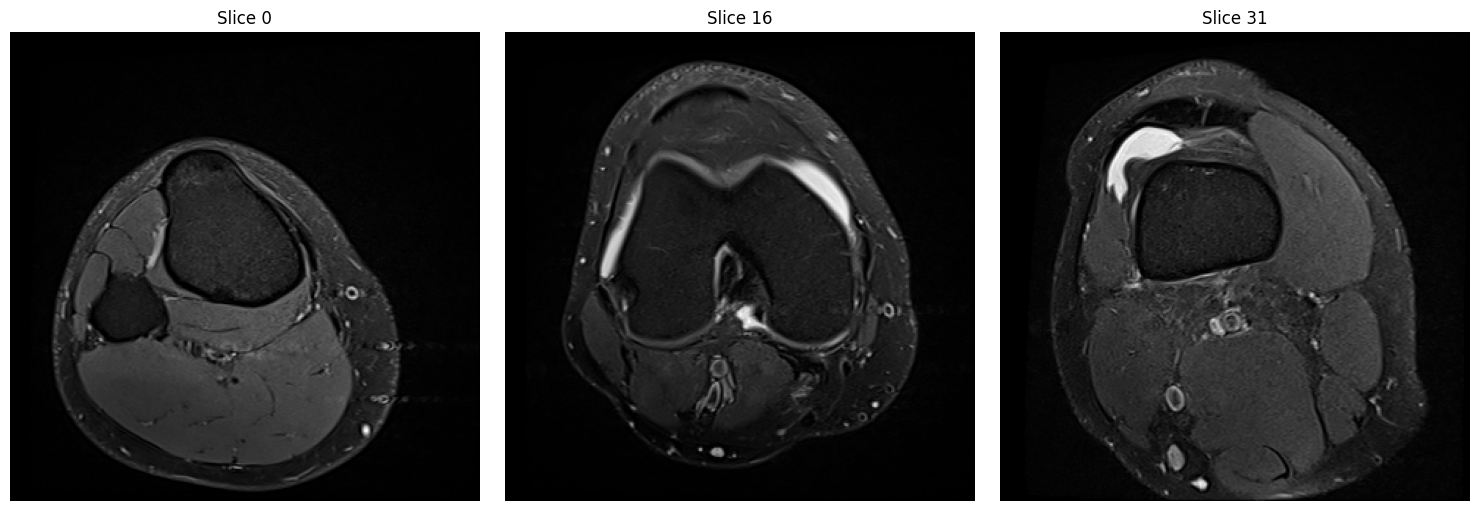

In [87]:
import matplotlib.pyplot as plt

indices = [
    0,
    volume.shape[0] // 2,
    volume.shape[0] - 1
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx in zip(axes, indices):
    ax.imshow(volume[idx], cmap="gray")
    ax.set_title(f"Slice {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [88]:
def normalize_volume(volume):
#Normalize a 3D MRI volume to [0, 1]
    volume = volume.astype(np.float32)

    min_val = volume.min()
    max_val = volume.max()

    if max_val > min_val:
        volume = (volume - min_val) / (max_val - min_val)
    else:
        volume = np.zeros_like(volume, dtype=np.float32)

    return volume

In [89]:
normalized_volume = normalize_volume(volume)

print("Shape:", normalized_volume.shape)
print("Data type:", normalized_volume.dtype)
print("Min:", normalized_volume.min())
print("Max:", normalized_volume.max())

Shape: (32, 320, 320)
Data type: float32
Min: 0.0
Max: 1.0


In [90]:
print("Testing one selected series from each anatomical plane:\n")

for plane in ["Axial", "Coronal", "Sagittal"]:

    plane_rows = selected_series_df[
        selected_series_df["Anatomical_Plane"] == plane
    ]

    if len(plane_rows) == 0:
        print(f"{plane}: No series found")
        continue

    row = plane_rows.iloc[0]

    vol = load_series_volume(
        row["StudyInstanceUID"],
        row["SeriesInstanceUID"]
    )

    print(
        f"{plane:10} | "
        f"shape = {vol.shape} | "
        f"dtype = {vol.dtype} | "
        f"range = ({vol.min()}, {vol.max()})"
    )

Testing one selected series from each anatomical plane:

Axial      | shape = (32, 320, 320) | dtype = uint16 | range = (0, 770)
Coronal    | shape = (30, 320, 320) | dtype = uint16 | range = (0, 659)
Sagittal   | shape = (36, 320, 320) | dtype = uint16 | range = (0, 788)


In [91]:
target_columns = [
    "acl",
    "mcl",
    "meniscus",
    "acl_tear",
    "mcl_tear",
    "meniscus_tear",
    "bone_contusion",
    "cartilage",
    "fracture",
    "effusion",
    "synovitis",
    "osteoarthritis"
]

print("Number of targets:", len(target_columns))

Number of targets: 12


In [92]:
print(train.columns.tolist())

['StudyInstanceUID', 'Report', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']


In [93]:
target_columns = [
    "ACL",
    "MCL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "Medial OA",
    "Lateral OA",
    "PF OA",
    "Effusion",
    "Synovitis",
    "Baker's",
    "Contusion",
    "Fracture"
]

study_labels = train[
    ["StudyInstanceUID"] + target_columns
].copy()

print("Study-level label table shape:", study_labels.shape)
print("\nColumns:")
print(study_labels.columns.tolist())

print("\nFirst 5 rows:")
display(study_labels.head())

Study-level label table shape: (4407, 13)

Columns:
['StudyInstanceUID', 'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus', 'Medial OA', 'Lateral OA', 'PF OA', 'Effusion', 'Synovitis', "Baker's", 'Contusion', 'Fracture']

First 5 rows:


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [94]:
print("Missing values per label:\n")

print(
    study_labels[target_columns]
    .isna()
    .sum()
)

print("\nUnique values per label:\n")

for col in target_columns:
    print(f"{col:20}:", study_labels[col].dropna().unique())

Missing values per label:

ACL                 4349
MCL                 4349
Medial Meniscus     4349
Lateral Meniscus    4349
Medial OA           4349
Lateral OA          4349
PF OA               4349
Effusion            4349
Synovitis           4349
Baker's             4349
Contusion           4349
Fracture            4349
dtype: int64

Unique values per label:

ACL                 : [0. 1.]
MCL                 : [0. 1.]
Medial Meniscus     : [0. 1.]
Lateral Meniscus    : [0. 1.]
Medial OA           : [0. 1.]
Lateral OA          : [0. 1.]
PF OA               : [1. 0.]
Effusion            : [1. 0.]
Synovitis           : [0. 1.]
Baker's             : [0. 1.]
Contusion           : [0. 1.]
Fracture            : [0. 1.]


In [95]:
labeled_selected_series = selected_series_df[
    selected_series_df["StudyInstanceUID"].isin(
        labeled_studies["StudyInstanceUID"]
    )
].copy()

print("Selected series from labeled studies:")
print("Shape:", labeled_selected_series.shape)

print("\nSeries per anatomical plane:")
print(
    labeled_selected_series["Anatomical_Plane"]
    .value_counts()
)

print("\nStudies represented:")
print(
    labeled_selected_series["StudyInstanceUID"].nunique()
)

Selected series from labeled studies:
Shape: (170, 6)

Series per anatomical plane:
Anatomical_Plane
Axial       58
Coronal     56
Sagittal    56
Name: count, dtype: int64

Studies represented:
58


In [96]:
print("Selected series by plane and sequence family:\n")

display(
    labeled_selected_series
    .groupby(["Anatomical_Plane", "Sequence_Family"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Anatomical_Plane", "Count"], ascending=[True, False])
)

print("\nSlice-count statistics:\n")

display(
    labeled_selected_series
    .groupby("Anatomical_Plane")["Number_of_Slices"]
    .describe()
)

Selected series by plane and sequence family:



,Anatomical_Plane,Sequence_Family,Count
1,Axial,PD_FS,25
3,Axial,T2_FS,20
4,Axial,Unknown,8
0,Axial,Other,3
2,Axial,STIR,2
6,Coronal,PD_FS,34
7,Coronal,T2_FS,10
8,Coronal,Unknown,8
5,Coronal,Other,4
10,Sagittal,PD_FS,35



Slice-count statistics:



,count,mean,std,min,25%,50%,75%,max
Anatomical_Plane,,,,,,,,
Axial,58.0,36.086207,23.516537,12.0,30.00,32.0,40.0,160.0
Coronal,56.0,28.946429,6.299840,15.0,26.00,30.0,32.0,42.0
Sagittal,56.0,33.660714,39.521813,15.0,23.75,29.0,34.0,320.0


In [97]:
series_count_per_study = (
    labeled_selected_series
    .groupby("StudyInstanceUID")
    .size()
    .reset_index(name="Series_Count")
)

print("Series count per study:")
print(
    series_count_per_study["Series_Count"]
    .value_counts()
    .sort_index()
)

print("\nStatistics:")
print(
    series_count_per_study["Series_Count"].describe()
)

print("\nStudies with multiple selected series:")
display(
    series_count_per_study[
        series_count_per_study["Series_Count"] > 3
    ].sort_values("Series_Count", ascending=False)
)

Series count per study:
Series_Count
2     4
3    54
Name: count, dtype: int64

Statistics:
count    58.000000
mean      2.931034
std       0.255609
min       2.000000
25%       3.000000
50%       3.000000
75%       3.000000
max       3.000000
Name: Series_Count, dtype: float64

Studies with multiple selected series:


,StudyInstanceUID,Series_Count


In [98]:
# Study-level model index

study_index = labeled_studies[
    ["StudyInstanceUID"] + target_columns
].copy()

for plane in ["Axial", "Coronal", "Sagittal"]:

    plane_df = (
        labeled_selected_series[
            labeled_selected_series["Anatomical_Plane"] == plane
        ][["StudyInstanceUID", "SeriesInstanceUID"]]
        .rename(
            columns={
                "SeriesInstanceUID": f"{plane}_SeriesUID"
            }
        )
    )

    study_index = study_index.merge(
        plane_df,
        on="StudyInstanceUID",
        how="left"
    )

print("Study-level model index shape:", study_index.shape)

print("\nMissing series:")
print(
    study_index[
        ["Axial_SeriesUID", "Coronal_SeriesUID", "Sagittal_SeriesUID"]
    ].isna().sum()
)

display(study_index.head())

Study-level model index shape: (58, 16)

Missing series:
Axial_SeriesUID       0
Coronal_SeriesUID     2
Sagittal_SeriesUID    2
dtype: int64


,StudyInstanceUID,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture,Axial_SeriesUID,Coronal_SeriesUID,Sagittal_SeriesUID
0,1.2.826.0.1.3680043.8.498.10095687747295410396...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.2.826.0.1.3680043.8.498.67495435033389756963...,1.2.826.0.1.3680043.8.498.21497837050858589852...,1.2.826.0.1.3680043.8.498.37372672584387115708...
1,1.2.826.0.1.3680043.8.498.10170898615867673028...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.2.826.0.1.3680043.8.498.71876353677262220297...,1.2.826.0.1.3680043.8.498.45571369239262736508...,1.2.826.0.1.3680043.8.498.55642842745139279565...
2,1.2.826.0.1.3680043.8.498.10306159113324811538...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.2.826.0.1.3680043.8.498.19770471468778499025...,1.2.826.0.1.3680043.8.498.28095032587022735220...,1.2.826.0.1.3680043.8.498.10903465965639594231...
3,1.2.826.0.1.3680043.8.498.11287937729196958426...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.2.826.0.1.3680043.8.498.12552728774210526013...,1.2.826.0.1.3680043.8.498.11454182648928474635...,1.2.826.0.1.3680043.8.498.93698495301744954009...
4,1.2.826.0.1.3680043.8.498.11382021393803389951...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.2.826.0.1.3680043.8.498.14985374264812063212...,1.2.826.0.1.3680043.8.498.93215173970625947969...,1.2.826.0.1.3680043.8.498.91903627435354016135...


In [99]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cpu
CUDA available: False


In [100]:
def prepare_volume(volume, target_shape=(32, 128, 128)):
    #Normalize and resize a 3D MRI volume to a fixed shape.

    #Input: volume: NumPy array of shape (slices, height, width)

    #Output: torch.Tensor of shape (1, D, H, W)
    # Normalize intensity
    volume = normalize_volume(volume)

    # Convert to tensor
    volume = torch.from_numpy(volume).float()

    # Add batch and channel dimensions
    volume = volume.unsqueeze(0).unsqueeze(0)

    # Resize the 3D volume
    volume = torch.nn.functional.interpolate(
        volume,
        size=target_shape,
        mode="trilinear",
        align_corners=False
    )

    # Remove batch dimension
    volume = volume.squeeze(0)

    return volume

In [101]:
class RSNAKneeDataset(Dataset):

    def __init__(self, dataframe, target_shape=(32, 128, 128)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.target_shape = target_shape

    def __len__(self):
        return len(self.dataframe)

    def _load_plane(self, study_uid, series_uid):
        # Missing plane
        if pd.isna(series_uid):
            return torch.zeros(
                (1, *self.target_shape),
                dtype=torch.float32
            )

        volume = load_series_volume(
            study_uid,
            series_uid
        )

        if volume is None:
            return torch.zeros(
                (1, *self.target_shape),
                dtype=torch.float32
            )

        return prepare_volume(
            volume,
            target_shape=self.target_shape
        )

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        study_uid = row["StudyInstanceUID"]

        # Load the three anatomical planes
        axial = self._load_plane(
            study_uid,
            row["Axial_SeriesUID"]
        )

        coronal = self._load_plane(
            study_uid,
            row["Coronal_SeriesUID"]
        )

        sagittal = self._load_plane(
            study_uid,
            row["Sagittal_SeriesUID"]
        )

        # Stack planes as separate input channels
        image = torch.cat(
            [axial, coronal, sagittal],
            dim=0
        )

        # 12 abnormality labels
        labels = torch.tensor(
            row[target_columns].values.astype(np.float32)
        )

        return image, labels

In [102]:
test_dataset = RSNAKneeDataset(
    study_index,
    target_shape=(32, 128, 128)
)

image, labels = test_dataset[0]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Image range:", (image.min().item(), image.max().item()))

print("\nLabels shape:", labels.shape)
print("Labels:", labels)

Image shape: torch.Size([3, 32, 128, 128])
Image dtype: torch.float32
Image range: (0.0, 0.9213473796844482)

Labels shape: torch.Size([12])
Labels: tensor([0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0.])


In [103]:
train_loader = DataLoader(
    test_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([2, 3, 32, 128, 128])
Batch label shape: torch.Size([2, 12])


In [104]:
class RSNAKnee3DCNN(nn.Module):

    def __init__(self, num_classes=12):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv3d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool3d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = RSNAKnee3DCNN(num_classes=len(target_columns))

print(model)

RSNAKnee3DCNN(
  (features): Sequential(
    (0): Conv3d(3, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (5): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (9): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool3d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace

In [105]:
model.eval()

with torch.no_grad():
    outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Output values:", outputs)

Input shape: torch.Size([2, 3, 32, 128, 128])
Output shape: torch.Size([2, 12])
Output values: tensor([[-0.1016,  0.0743, -0.0435,  0.1003, -0.1009, -0.0306, -0.0017, -0.1002,
         -0.1265,  0.0051, -0.0396,  0.0751],
        [-0.1013,  0.0743, -0.0438,  0.1000, -0.1009, -0.0304, -0.0019, -0.1005,
         -0.1267,  0.0052, -0.0393,  0.0751]])


In [106]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    study_index,
    test_size=0.20,
    random_state=42
)

print("Training studies:", len(train_df))
print("Validation studies:", len(val_df))

print("\nTraining label counts:")
print(train_df[target_columns].sum().sort_values(ascending=False))

print("\nValidation label counts:")
print(val_df[target_columns].sum().sort_values(ascending=False))

Training studies: 46
Validation studies: 12

Training label counts:
Effusion            27.0
Synovitis           23.0
ACL                 21.0
Medial Meniscus     21.0
Lateral Meniscus    19.0
Fracture            18.0
Contusion           17.0
PF OA               17.0
Medial OA           11.0
Lateral OA          11.0
Baker's             10.0
MCL                  6.0
dtype: float64

Validation label counts:
Effusion            8.0
Medial Meniscus     5.0
Medial OA           4.0
Lateral Meniscus    4.0
PF OA               4.0
Synovitis           4.0
ACL                 3.0
MCL                 3.0
Contusion           2.0
Baker's             2.0
Lateral OA          0.0
Fracture            0.0
dtype: float64


In [107]:
try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    print("Multilabel stratification: AVAILABLE")
except ImportError:
    print("Multilabel stratification: NOT AVAILABLE")

Multilabel stratification: NOT AVAILABLE


In [108]:
def multilabel_split(df, test_size=0.20, random_state=42):

    rng = np.random.RandomState(random_state)

    labels = df[target_columns].values.astype(int)
    n_samples = len(df)
    n_val = int(round(n_samples * test_size))

    # Start with the rarest labels
    label_counts = labels.sum(axis=0)
    label_order = np.argsort(label_counts)

    val_indices = set()
    remaining = set(range(n_samples))

    # Target number of positives for each label in validation
    target_val_counts = np.round(label_counts * test_size).astype(int)

    for label_idx in label_order:

        candidates = [
            i for i in remaining
            if labels[i, label_idx] == 1
        ]

        rng.shuffle(candidates)

        needed = target_val_counts[label_idx]

        selected = candidates[:needed]

        for i in selected:
            val_indices.add(i)
            remaining.discard(i)

    # Fill remaining validation slots
    remaining_candidates = list(remaining)
    rng.shuffle(remaining_candidates)

    while len(val_indices) < n_val:
        val_indices.add(remaining_candidates.pop())

    val_indices = sorted(val_indices)
    train_indices = sorted(set(range(n_samples)) - set(val_indices))

    train_df = df.iloc[train_indices].copy()
    val_df = df.iloc[val_indices].copy()

    return train_df, val_df


train_df, val_df = multilabel_split(
    study_index,
    test_size=0.20,
    random_state=42
)

print("Training studies:", len(train_df))
print("Validation studies:", len(val_df))

print("\nTraining label counts:")
print(train_df[target_columns].sum().sort_values(ascending=False))

print("\nValidation label counts:")
print(val_df[target_columns].sum().sort_values(ascending=False))

Training studies: 11
Validation studies: 47

Training label counts:
MCL                 3.0
Medial Meniscus     3.0
Lateral Meniscus    2.0
PF OA               2.0
Fracture            2.0
ACL                 1.0
Baker's             1.0
Medial OA           1.0
Contusion           1.0
Lateral OA          0.0
Effusion            0.0
Synovitis           0.0
dtype: float64

Validation label counts:
Effusion            35.0
Synovitis           27.0
ACL                 23.0
Medial Meniscus     23.0
Lateral Meniscus    21.0
PF OA               19.0
Contusion           18.0
Fracture            16.0
Medial OA           14.0
Lateral OA          11.0
Baker's             11.0
MCL                  6.0
dtype: float64


In [109]:
train_df, val_df = train_test_split(
    study_index,
    test_size=12,
    random_state=42,
    shuffle=True
)

print("Training studies:", len(train_df))
print("Validation studies:", len(val_df))

print("\nValidation positive counts:")
print(val_df[target_columns].sum())

Training studies: 46
Validation studies: 12

Validation positive counts:
ACL                 3.0
MCL                 3.0
Medial Meniscus     5.0
Lateral Meniscus    4.0
Medial OA           4.0
Lateral OA          0.0
PF OA               4.0
Effusion            8.0
Synovitis           4.0
Baker's             2.0
Contusion           2.0
Fracture            0.0
dtype: float64


In [110]:
train_dataset = RSNAKneeDataset(train_df)
val_dataset = RSNAKneeDataset(val_df)

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Training dataset size: 46
Validation dataset size: 12


In [111]:
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 23
Validation batches: 6


In [112]:
positive_counts = train_df[target_columns].sum().values
negative_counts = len(train_df) - positive_counts

pos_weight = negative_counts / positive_counts

pos_weight = torch.tensor(
    pos_weight,
    dtype=torch.float32
)

print("Class weights:")
for label, weight in zip(target_columns, pos_weight):
    print(f"{label:20s}: {weight.item():.2f}")

Class weights:
ACL                 : 1.19
MCL                 : 6.67
Medial Meniscus     : 1.19
Lateral Meniscus    : 1.42
Medial OA           : 3.18
Lateral OA          : 3.18
PF OA               : 1.71
Effusion            : 0.70
Synovitis           : 1.00
Baker's             : 3.60
Contusion           : 1.71
Fracture            : 1.56


In [113]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)


In [114]:
model.train()

images, labels = next(iter(train_loader))

optimizer.zero_grad()

outputs = model(images)

loss = criterion(outputs, labels)

loss.backward()

optimizer.step()

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Output shape:", outputs.shape)
print("Loss:", loss.item())

Batch image shape: torch.Size([2, 3, 32, 128, 128])
Batch label shape: torch.Size([2, 12])
Output shape: torch.Size([2, 12])
Loss: 0.7418511509895325


In [115]:
model = RSNAKnee3DCNN(num_classes=len(target_columns))

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

num_epochs = 10

print("Model reset.")
print("Epochs:", num_epochs)
print("Learning rate:", 1e-4)
print("Batch size:", train_loader.batch_size)

Model reset.
Epochs: 10
Learning rate: 0.0001
Batch size: 2


In [116]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)
   
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

Epoch [1/10] Train Loss: 0.8874 | Val Loss: 0.8808
Epoch [2/10] Train Loss: 0.8830 | Val Loss: 0.8856
Epoch [3/10] Train Loss: 0.8799 | Val Loss: 0.8901
Epoch [4/10] Train Loss: 0.8813 | Val Loss: 0.8905
Epoch [5/10] Train Loss: 0.8789 | Val Loss: 0.8932
Epoch [6/10] Train Loss: 0.8754 | Val Loss: 0.8935
Epoch [7/10] Train Loss: 0.8757 | Val Loss: 0.8939
Epoch [8/10] Train Loss: 0.8799 | Val Loss: 0.8936
Epoch [9/10] Train Loss: 0.8797 | Val Loss: 0.8931
Epoch [10/10] Train Loss: 0.8774 | Val Loss: 0.8951


In [117]:
from sklearn.metrics import roc_auc_score

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in val_loader:

        outputs = model(images)
        probabilities = torch.sigmoid(outputs)

        all_labels.append(labels.numpy())
        all_probs.append(probabilities.numpy())

all_labels = np.concatenate(all_labels, axis=0)
all_probs = np.concatenate(all_probs, axis=0)

print("Validation labels shape:", all_labels.shape)
print("Validation predictions shape:", all_probs.shape)

print("\nPer-abnormality ROC-AUC:")

auc_scores = {}

for i, label in enumerate(target_columns):

    unique_classes = np.unique(all_labels[:, i])

    if len(unique_classes) < 2:
        auc_scores[label] = np.nan
        print(f"{label:20s}: N/A (only one class in validation)")
    else:
        auc = roc_auc_score(
            all_labels[:, i],
            all_probs[:, i]
        )
        auc_scores[label] = auc
        print(f"{label:20s}: {auc:.4f}")

valid_auc = [
    score for score in auc_scores.values()
    if not np.isnan(score)
]

print(
    f"\nMean ROC-AUC (valid labels): "
    f"{np.mean(valid_auc):.4f}"
)

Validation labels shape: (12, 12)
Validation predictions shape: (12, 12)

Per-abnormality ROC-AUC:
ACL                 : 0.6667
MCL                 : 0.3333
Medial Meniscus     : 0.6000
Lateral Meniscus    : 0.3750
Medial OA           : 0.3438
Lateral OA          : N/A (only one class in validation)
PF OA               : 0.6562
Effusion            : 0.8438
Synovitis           : 0.2812
Baker's             : 0.4000
Contusion           : 0.8000
Fracture            : N/A (only one class in validation)

Mean ROC-AUC (valid labels): 0.5300


In [118]:
class PlaneEncoder3D(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv3d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm3d(16),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool3d(1)
        )

    def forward(self, x):
        x = self.features(x)
        return x.flatten(1)


class RSNAKneeMultiPlane3DCNN(nn.Module):
    def __init__(self, num_classes=12):
        super().__init__()

        # One encoder for each anatomical plane
        self.axial_encoder = PlaneEncoder3D()
        self.coronal_encoder = PlaneEncoder3D()
        self.sagittal_encoder = PlaneEncoder3D()

        # Fuse the learned representations
        self.classifier = nn.Sequential(
            nn.Linear(64 * 3, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x shape: [batch, 3, depth, height, width]

        axial = x[:, 0:1, :, :, :]
        coronal = x[:, 1:2, :, :, :]
        sagittal = x[:, 2:3, :, :, :]

        axial_features = self.axial_encoder(axial)
        coronal_features = self.coronal_encoder(coronal)
        sagittal_features = self.sagittal_encoder(sagittal)

        fused_features = torch.cat(
            [axial_features, coronal_features, sagittal_features],
            dim=1
        )

        return self.classifier(fused_features)

In [119]:
# Create the new multi-plane model
multi_plane_model = RSNAKneeMultiPlane3DCNN(
    num_classes=len(target_columns)
)
images, labels = next(iter(train_loader))

with torch.no_grad():
    outputs = multi_plane_model(images)

print("Input shape :", images.shape)
print("Label shape :", labels.shape)
print("Output shape:", outputs.shape)
print("Output dtype:", outputs.dtype)

Input shape : torch.Size([2, 3, 32, 128, 128])
Label shape : torch.Size([2, 12])
Output shape: torch.Size([2, 12])
Output dtype: torch.float32


In [120]:
multi_plane_model = RSNAKneeMultiPlane3DCNN(
    num_classes=len(target_columns)
)

# Use the same class-imbalance handling as the baseline
multi_plane_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

multi_plane_optimizer = torch.optim.Adam(
    multi_plane_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

print("Model, loss function, and optimizer initialized.")

Model, loss function, and optimizer initialized.


In [121]:
images, labels = next(iter(train_loader))
multi_plane_model.train()
outputs = multi_plane_model(images)
loss = multi_plane_criterion(outputs, labels)
multi_plane_optimizer.zero_grad()
loss.backward()
multi_plane_optimizer.step()

print("Batch image shape :", images.shape)
print("Batch label shape :", labels.shape)
print("Output shape      :", outputs.shape)
print("Training loss     :", loss.item())

Batch image shape : torch.Size([2, 3, 32, 128, 128])
Batch label shape : torch.Size([2, 12])
Output shape      : torch.Size([2, 12])
Training loss     : 0.8446650505065918


In [122]:
num_epochs = 10

multi_plane_train_losses = []
multi_plane_val_losses = []

for epoch in range(num_epochs):
    multi_plane_model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:
        multi_plane_optimizer.zero_grad()

        outputs = multi_plane_model(images)
        loss = multi_plane_criterion(outputs, labels)

        loss.backward()
        multi_plane_optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    multi_plane_model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = multi_plane_model(images)
            loss = multi_plane_criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    multi_plane_train_losses.append(avg_train_loss)
    multi_plane_val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch 01/10 | Train Loss: 0.8859 | Val Loss: 0.8609
Epoch 02/10 | Train Loss: 0.8865 | Val Loss: 0.8581
Epoch 03/10 | Train Loss: 0.8763 | Val Loss: 0.8679
Epoch 04/10 | Train Loss: 0.8769 | Val Loss: 0.8730
Epoch 05/10 | Train Loss: 0.8760 | Val Loss: 0.8740
Epoch 06/10 | Train Loss: 0.8741 | Val Loss: 0.8797
Epoch 07/10 | Train Loss: 0.8631 | Val Loss: 0.8797
Epoch 08/10 | Train Loss: 0.8784 | Val Loss: 0.8824
Epoch 09/10 | Train Loss: 0.8695 | Val Loss: 0.8861
Epoch 10/10 | Train Loss: 0.8725 | Val Loss: 0.8866


In [123]:
from sklearn.metrics import roc_auc_score

multi_plane_model.eval()

all_labels_mp = []
all_probs_mp = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = multi_plane_model(images)
        probabilities = torch.sigmoid(outputs)

        all_labels_mp.append(labels.numpy())
        all_probs_mp.append(probabilities.numpy())

all_labels_mp = np.concatenate(all_labels_mp, axis=0)
all_probs_mp = np.concatenate(all_probs_mp, axis=0)

print("Validation labels shape:", all_labels_mp.shape)
print("Validation predictions shape:", all_probs_mp.shape)

print("\nMulti-plane model ROC-AUC:")

mp_auc_scores = {}

for i, label in enumerate(target_columns):

    unique_classes = np.unique(all_labels_mp[:, i])

    if len(unique_classes) < 2:
        mp_auc_scores[label] = np.nan
        print(f"{label:20s}: N/A (only one class in validation)")
    else:
        auc = roc_auc_score(
            all_labels_mp[:, i],
            all_probs_mp[:, i]
        )
        mp_auc_scores[label] = auc
        print(f"{label:20s}: {auc:.4f}")

valid_mp_auc = [
    score for score in mp_auc_scores.values()
    if not np.isnan(score)
]

print(f"\nMean ROC-AUC (valid labels): {np.mean(valid_mp_auc):.4f}")

Validation labels shape: (12, 12)
Validation predictions shape: (12, 12)

Multi-plane model ROC-AUC:
ACL                 : 0.8889
MCL                 : 0.2222
Medial Meniscus     : 0.5143
Lateral Meniscus    : 0.3125
Medial OA           : 0.4062
Lateral OA          : N/A (only one class in validation)
PF OA               : 0.6250
Effusion            : 0.5938
Synovitis           : 0.5938
Baker's             : 0.1000
Contusion           : 0.4000
Fracture            : N/A (only one class in validation)

Mean ROC-AUC (valid labels): 0.4657


In [124]:
import os

print("Files/folders in competition directory:\n")

for item in os.listdir(BASE_PATH):
    path = os.path.join(BASE_PATH, item)
    if os.path.isdir(path):
        print(f"[DIR ] {item}")
    else:
        print(f"[FILE] {item}")

Files/folders in competition directory:

[FILE] test_series.csv
[FILE] train_series.csv
[FILE] sample_submission.csv
[DIR ] test_series
[DIR ] train_series
[FILE] train.csv
[FILE] test.csv


In [125]:
model = RSNAKnee3DCNN(
    num_classes=len(target_columns)
)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)
print("Baseline model restored.")

Baseline model restored.


In [126]:
print("Total studies:", len(train))

print("\nReports available:")
print(train["Report"].notna().sum())

print("\nReports missing:")
print(train["Report"].isna().sum())

print("\nStudies with at least one official label:")
print(train[target_columns].notna().any(axis=1).sum())

print("\nStudies with all 12 official labels:")
print(train[target_columns].notna().all(axis=1).sum())

Total studies: 4407

Reports available:
4407

Reports missing:
0

Studies with at least one official label:
58

Studies with all 12 official labels:
58


In [127]:
reports = train["Report"].dropna().astype(str)

print("Number of reports:", len(reports))

print("\nReport length statistics:")
print(reports.str.len().describe())

print("\nSample reports:\n")
for i, report in enumerate(reports.sample(10, random_state=42)):
    print(f"\n--- Report {i+1} ---")
    print(report[:1000])

Number of reports: 4407

Report length statistics:
count    4407.000000
mean     1097.905605
std       693.948925
min        52.000000
25%       587.500000
50%       977.000000
75%      1459.500000
max      4743.000000
Name: Report, dtype: float64

Sample reports:


--- Report 1 ---
Regelrechte Stellungsverhältnisse im Kniegelenk. Allseits regelrechtes Knochenmarksignal. Kein Hinweis auf eine Fraktur oder ein Bone-bruise. Stigmata der medial betonten Gonarthrose mit Gelenkspaltverschmälerung und osteophytären Randausziehungen sowie Chondropathie femorotibial bds. Keine höhergradige Chondropathie femoropatellar. Vorderes und hinteres Kreuzband sowie LCL intakt. Quadrizeps- und Patellarsehne intakt ohne Signalalteration. Der Innenmeniskus mukoide mit horizontaler Rissbildung. Auch der Außenmeniskus mukoid verändert ohne Nachweis einer Rissbildung. Fibroostosen der Quadrizepssehne. Geringer Gelenkerguss. Unauffällige Darstellung der Weichteile.

--- Report 2 ---
SAĞ DİZ MRG. Tetkik protok

In [128]:
language_keywords = {
    "English": ["MRI", "knee", "ACL", "meniscus", "tear", "effusion"],
    "German": ["Knie", "Meniskus", "Kreuzband", "Gelenkerguss", "Knorpel"],
    "Spanish": ["rodilla", "menisco", "ligamento", "derrame", "rotura"],
    "Turkish": ["diz", "menisküs", "bağ", "yırtık", "eklem"],
    "Greek": ["γόνατο", "μηνίσκου", "ρήξη", "σύνδεσμο", "ύδραρθρο"],
    "Croatian/Bosnian/Serbian": ["koljena", "meniska", "ruptura", "ligament", "izljev"],
    "French": ["genou", "ménisque", "rupture", "ligament", "épanchement"],
}

for language, keywords in language_keywords.items():
    mask = train["Report"].str.lower().apply(
        lambda x: any(keyword.lower() in x for keyword in keywords)
    )
    print(f"{language:25s}: {mask.sum()} reports")

English                  : 2018 reports
German                   : 414 reports
Spanish                  : 1018 reports
Turkish                  : 546 reports
Greek                    : 237 reports
Croatian/Bosnian/Serbian : 2189 reports
French                   : 2179 reports


In [129]:
labeled_reports = train[
    train[target_columns].notna().all(axis=1)
].copy()

print("Officially labeled studies:", len(labeled_reports))

for _, row in labeled_reports.head(10).iterrows():
    print("\n" + "=" * 80)
    print("Study:", row["StudyInstanceUID"])
    print("\nOfficial labels:")
    
    for target in target_columns:
        print(f"  {target:20s}: {int(row[target])}")
    
    print("\nReport:")
    print(row["Report"][:1500])

Officially labeled studies: 58

Study: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149

Official labels:
  ACL                 : 0
  MCL                 : 0
  Medial Meniscus     : 0
  Lateral Meniscus    : 0
  Medial OA           : 0
  Lateral OA          : 0
  PF OA               : 1
  Effusion            : 1
  Synovitis           : 0
  Baker's             : 0
  Contusion           : 0
  Fracture            : 0

Report:
Antecedentes Clínicos:
Esguince rodilla. [DATE].
Hallazgos:
No hay alteraciones de señal significativas de la médula ósea.
Ligamentos cruzados y colaterales dentro de límites normales.
Amputación marginal del cuerpo del menisco lateral. Menisco medial de morfología y señal
conservada, sin signos de rotura.
Cartílagos de los compartimentos femorotibiales sin alteraciones.
Fina úlcera condral focal de espesor total del aspecto inferior de la vertiente medial de la tróclea
femoral con mínimos cambios óseos secundarios. Fenómenos condrales reparativos de 

In [130]:
import re
import numpy as np

def extract_acl(report):
 
    text = str(report).lower()

    # Strong negative patterns
    negative_patterns = [
        r"\bacl\b.*\bintact\b",
        r"\bacl\b.*\bnormal\b",
        r"\bacl\b.*\bpreserved\b",
        r"\bacl\b.*\bwithin normal\b",
        r"\bno (?:evidence of )?(?:acl )?(?:tear|rupture)\b",
        r"acl.*(?:ohne.*ruptur|intakt)",
        r"(?:lca).*?(?:sin alteraciones|intacto)",
        r"(?:lca).*?(?:sin signos|sin caracteres).*?(?:rotura|ruptura)",
    ]

    # Strong positive patterns
    positive_patterns = [
        r"\bacl\b.*\btear\b",
        r"\bacl\b.*\brupture\b",
        r"\bacl\b.*\binjury\b",
        r"\bacl\b.*\bsprain\b",
        r"\bcomplete tear of the anterior cruciate ligament\b",
        r"\bpartial tear of the anterior cruciate ligament\b",
        r"\binterstitial tear of the anterior cruciate ligament\b",
        
        # Common non-English terminology
        r"\blca\b.*\brotura\b",
        r"\blca\b.*\bruptura\b",
        r"\blca\b.*\blesi[oó]n\b",
        r"\bkreuzband\b.*\briss\b",
        r"\bkreuzband\b.*\bruptur\b",
        r"\bmenisküs\b",  # deliberately NOT sufficient; placeholder avoided below
    ]

    # Remove the deliberately unsafe generic pattern above
    positive_patterns = positive_patterns[:-1]

    # Check negatives first
    for pattern in negative_patterns:
        if re.search(pattern, text, flags=re.IGNORECASE):
            return 0

    # Then positives
    for pattern in positive_patterns:
        if re.search(pattern, text, flags=re.IGNORECASE):
            return 1

    return np.nan

In [131]:
labeled_reports["ACL_extracted"] = labeled_reports["Report"].apply(extract_acl)

comparison = labeled_reports[
    ["ACL", "ACL_extracted"]
].copy()

print(comparison.to_string(index=False))

print("\nAgreement:")
print(
    (comparison["ACL"] == comparison["ACL_extracted"])
    .sum(),
    "out of",
    comparison["ACL"].notna().sum()
)

print("\nConfusion table:")
print(
    pd.crosstab(
        comparison["ACL"],
        comparison["ACL_extracted"],
        dropna=False
    )
)

 ACL  ACL_extracted
 0.0            NaN
 0.0            0.0
 0.0            0.0
 0.0            0.0
 1.0            1.0
 0.0            1.0
 1.0            NaN
 0.0            0.0
 0.0            0.0
 0.0            NaN
 0.0            NaN
 1.0            1.0
 1.0            1.0
 0.0            NaN
 0.0            NaN
 0.0            1.0
 1.0            NaN
 0.0            NaN
 0.0            0.0
 1.0            NaN
 1.0            NaN
 0.0            0.0
 0.0            NaN
 1.0            0.0
 0.0            0.0
 0.0            NaN
 1.0            0.0
 1.0            NaN
 1.0            NaN
 1.0            1.0
 0.0            NaN
 0.0            NaN
 1.0            1.0
 0.0            NaN
 0.0            NaN
 1.0            NaN
 0.0            NaN
 0.0            0.0
 1.0            NaN
 1.0            0.0
 1.0            NaN
 0.0            NaN
 0.0            1.0
 0.0            NaN
 1.0            0.0
 0.0            NaN
 0.0            0.0
 1.0            1.0
 0.0            NaN


In [132]:
import re

def get_acl_sentences(report):
    text = str(report)

    # Split reports into reasonably sized sentences/lines
    sentences = re.split(r'(?<=[.!?])\s+|\n+', text)

    acl_terms = [
        "ACL",
        "LCA",
        "anterior cruciate",
        "cruciate ligament",
        "vorderes kreuzband",
        "kreuzband",
        "ön çapraz",
        "ön çapraz bağ",
        "πρόσθιου χιαστού",
        "πρόσθιος χιαστός",
        "prednjeg križnog",
        "prednjeg ukrštenog",
        "ligamento cruzado anterior",
        "ligamentum cruciatum anterius",
    ]

    matched = []

    for sentence in sentences:
        sentence_lower = sentence.lower()

        if any(term.lower() in sentence_lower for term in acl_terms):
            matched.append(sentence.strip())

    return matched


# Show ACL-related sentences from the 58 official studies
for _, row in labeled_reports.head(10).iterrows():
    print("\n" + "=" * 80)
    print("Official ACL:", int(row["ACL"]))

    for sentence in get_acl_sentences(row["Report"]):
        print("→", sentence)


Official ACL: 0

Official ACL: 0
→ ACL is intact.

Official ACL: 0
→ CRUCIATE LIGAMENTS:
→ Anterior cruciate ligament (ACL): Normal with both bundles intact.
→ Posterior cruciate ligament (PCL): Normal.

Official ACL: 0
→ > There is no increased intensity in the ACL, MCL and LCL, it appears to be normal

Official ACL: 1
→ In the intercondylar notch, there is complete tear of the anterior cruciate ligament, at mid substance.
→ The posterior cruciate ligament is intact.
→ -- Complete tear of the anterior cruciate ligament, at mid substance.

Official ACL: 0
→ In the intercondylar notch, there is interstitial tear of the anterior cruciate ligament, at mid substance.
→ The posterior cruciate ligament is intact.
→ Interstitial tear of the anterior cruciate ligament, at mid substance.

Official ACL: 1
→ Rotura espesor y ancho total de la unión del tercio medio del tercio proximal del LCA asociado a
→ Rotura espesor y ancho total del LCA.

Official ACL: 0
→ * Interstitial hyperintense signal

In [133]:
for _, row in labeled_reports.iterrows():
    acl_sentences = get_acl_sentences(row["Report"])

    print("\n" + "=" * 100)
    print("Official ACL:", int(row["ACL"]))

    for sentence in acl_sentences:
        print("→", sentence)


Official ACL: 0

Official ACL: 0
→ ACL is intact.

Official ACL: 0
→ CRUCIATE LIGAMENTS:
→ Anterior cruciate ligament (ACL): Normal with both bundles intact.
→ Posterior cruciate ligament (PCL): Normal.

Official ACL: 0
→ > There is no increased intensity in the ACL, MCL and LCL, it appears to be normal

Official ACL: 1
→ In the intercondylar notch, there is complete tear of the anterior cruciate ligament, at mid substance.
→ The posterior cruciate ligament is intact.
→ -- Complete tear of the anterior cruciate ligament, at mid substance.

Official ACL: 0
→ In the intercondylar notch, there is interstitial tear of the anterior cruciate ligament, at mid substance.
→ The posterior cruciate ligament is intact.
→ Interstitial tear of the anterior cruciate ligament, at mid substance.

Official ACL: 1
→ Rotura espesor y ancho total de la unión del tercio medio del tercio proximal del LCA asociado a
→ Rotura espesor y ancho total del LCA.

Official ACL: 0
→ * Interstitial hyperintense signal

In [134]:
import re
import numpy as np

def extract_acl_v2(report):
    text = str(report).lower()
    # 1. HIGH-CONFIDENCE NEGATIVE
    negative_patterns = [
        # English
        r"\bacl\b[^.\n]{0,120}\bintact\b",
        r"\bacl\b[^.\n]{0,120}\bnormal\b",
        r"\bacl\b[^.\n]{0,120}\bunremarkable\b",
        r"\banterior cruciate ligament\b[^.\n]{0,120}\bintact\b",
        r"\banterior cruciate ligament\b[^.\n]{0,120}\bnormal\b",
        r"\banterior cruciate ligament\b[^.\n]{0,120}\bno tear\b",
        r"\bno tear\b[^.\n]{0,120}\b(?:acl|anterior cruciate ligament)\b",

        # Spanish
        r"\blca\b[^.\n]{0,120}\bsin\b[^.\n]{0,40}(?:rotura|ruptura)",
        r"\blca\b[^.\n]{0,120}\bnormal\b",
        r"\blca\b[^.\n]{0,120}\bintacto\b",

        # Turkish
        r"\bön çapraz bağ\b[^.\n]{0,120}\bnormal\b",
        r"\bön çapraz bağ\b[^.\n]{0,120}\bkorun",
        
        # Croatian / Bosnian / Serbian
        r"\bprednjeg križnog ligamenta\b[^.\n]{0,120}\buredan\b",
        r"\bprednjeg križnog ligamenta\b[^.\n]{0,120}\bočuvan\b",
    ]
    # 2. HIGH-CONFIDENCE POSITIVE
    positive_patterns = [
        # English
        r"\bcomplete tear\b[^.\n]{0,100}\b(?:acl|anterior cruciate ligament)\b",
        r"\bcomplete rupture\b[^.\n]{0,100}\b(?:acl|anterior cruciate ligament)\b",
        r"\b(?:acl|anterior cruciate ligament)\b[^.\n]{0,100}\bcomplete tear\b",
        r"\b(?:acl|anterior cruciate ligament)\b[^.\n]{0,100}\bcomplete rupture\b",

        r"\b(?:acl|anterior cruciate ligament)\b[^.\n]{0,100}\btear\b",
        r"\b(?:acl|anterior cruciate ligament)\b[^.\n]{0,100}\brupture\b",

        # High-grade partial tear
        r"\bhigh[- ]grade partial[- ]thickness tear\b[^.\n]{0,100}\b(?:acl|anterior cruciate ligament)\b",
        r"\bhigh[- ]grade partial[- ]thickness tear\b[^.\n]{0,100}\b",

        # Spanish
        r"\brotura\b[^.\n]{0,100}\blca\b",
        r"\bruptura\b[^.\n]{0,100}\blca\b",
        r"\blca\b[^.\n]{0,100}\brotura\b",
        r"\blca\b[^.\n]{0,100}\bruptura\b",

        # Turkish
        r"\bön çapraz bağ\b[^.\n]{0,120}\b(?:tam kat|komplet|tam)\b[^.\n]{0,60}(?:yırtık|rüptür)",
        r"\bön çapraz bağ\b[^.\n]{0,120}\b(?:yırtık|rüptür)\b",

        # Greek
        r"\bπρόσθι(?:ου|ος)\s+χιαστ(?:ού|ός)\s+συνδέσμου\b[^.\n]{0,120}\bρήξη\b",
        r"\bρήξη\b[^.\n]{0,120}\bπρόσθι(?:ου|ος)\s+χιαστ",

        # Croatian / Bosnian / Serbian
        r"\bpotpuna ruptura\b[^.\n]{0,100}\bprednjeg križnog ligamenta\b",
        r"\bruptura\b[^.\n]{0,100}\bprednjeg križnog ligamenta\b",
        r"\bprednjeg križnog ligamenta\b[^.\n]{0,100}\bruptura\b",
    ]
    # 3. IMPORTANT: Ignore low-grade / equivocal findings.
    uncertain_patterns = [
        r"\bgrade\s*[12]\b[^.\n]{0,100}\b(?:acl|anterior cruciate ligament)\b",
        r"\b(?:acl|anterior cruciate ligament)\b[^.\n]{0,100}\bgrade\s*[12]\b",
        r"\blow[- ]grade\b[^.\n]{0,100}\b(?:acl|anterior cruciate ligament)\b",
        r"\binterstitial\b[^.\n]{0,100}\b(?:acl|anterior cruciate ligament)\b",
        r"\b(?:acl|anterior cruciate ligament)\b[^.\n]{0,100}\binterstitial\b",
        r"\bsprain\b[^.\n]{0,100}\b(?:acl|anterior cruciate ligament)\b",
        r"\b(?:acl|anterior cruciate ligament)\b[^.\n]{0,100}\bsprain\b",
        r"\bsignal\b[^.\n]{0,100}\b(?:acl|anterior cruciate ligament)\b",
        r"\b(?:acl|anterior cruciate ligament)\b[^.\n]{0,100}\bmyxoid\b",
        r"\b(?:acl|anterior cruciate ligament)\b[^.\n]{0,100}\bmucoid\b",
    ]

    # Negative gets priority only when the same local statement
    # clearly says the ACL is normal.
    for pattern in negative_patterns:
        if re.search(pattern, text, flags=re.IGNORECASE):
            return 0

    # Strong positives next
    for pattern in positive_patterns:
        if re.search(pattern, text, flags=re.IGNORECASE):
            return 1

    # Explicitly uncertain findings
    for pattern in uncertain_patterns:
        if re.search(pattern, text, flags=re.IGNORECASE):
            return np.nan

    return np.nan

In [135]:
labeled_reports["ACL_extracted_v2"] = labeled_reports["Report"].apply(
    extract_acl_v2
)

comparison = labeled_reports[
    ["ACL", "ACL_extracted_v2"]
].copy()

print(comparison.to_string(index=False))

print("\nValue counts:")
print(comparison["ACL_extracted_v2"].value_counts(dropna=False))

print("\nConfusion table:")
print(
    pd.crosstab(
        comparison["ACL"],
        comparison["ACL_extracted_v2"],
        dropna=False
    )
)

known = comparison["ACL_extracted_v2"].notna()

print("\nCoverage:",
      f"{known.sum()}/{len(comparison)} "
      f"({known.mean()*100:.1f}%)")

if known.any():
    print("Agreement among extracted cases:",
          f"{(comparison.loc[known, 'ACL'] == comparison.loc[known, 'ACL_extracted_v2']).mean()*100:.1f}%")

 ACL  ACL_extracted_v2
 0.0               NaN
 0.0               0.0
 0.0               0.0
 0.0               0.0
 1.0               1.0
 0.0               NaN
 1.0               1.0
 0.0               0.0
 0.0               0.0
 0.0               NaN
 0.0               NaN
 1.0               1.0
 1.0               1.0
 0.0               NaN
 0.0               NaN
 0.0               NaN
 1.0               NaN
 0.0               NaN
 0.0               0.0
 1.0               NaN
 1.0               NaN
 0.0               0.0
 0.0               NaN
 1.0               1.0
 0.0               0.0
 0.0               NaN
 1.0               1.0
 1.0               1.0
 1.0               NaN
 1.0               1.0
 0.0               NaN
 0.0               NaN
 1.0               1.0
 0.0               NaN
 0.0               NaN
 1.0               1.0
 0.0               NaN
 0.0               0.0
 1.0               NaN
 1.0               1.0
 1.0               NaN
 0.0               NaN
 0.0       

In [136]:
def get_mcl_sentences(report):
    text = str(report)

    sentences = re.split(r'(?<=[.!?])\s+|\n+', text)

    mcl_terms = [
        "MCL",
        "medial collateral ligament",
        "ligamento colateral medial",
        "ligamento colateral interno",
        "ligamentum collaterale mediale",
        "medial collateral",
        "medijalnog kolateralnog",
        "medijalni kolateralni",
        "medialnog kolateralnog",
        "medial collateral",
        "medial collateral ligament",
        "medial collateral ligamen",
        "medial collateral ligament",
        "medial collateral",
        "medial collateral",
        "medial collateral",
        "medial collateral",
        "medial collateral",
    ]

    matched = []

    for sentence in sentences:
        s = sentence.lower()

        if any(term.lower() in s for term in mcl_terms):
            matched.append(sentence.strip())

    return matched


for _, row in labeled_reports.iterrows():
    sentences = get_mcl_sentences(row["Report"])

    if sentences:
        print("\n" + "=" * 100)
        print("Official MCL:", int(row["MCL"]))

        for sentence in sentences:
            print("→", sentence)


Official MCL: 0
→ The MCL is intact.

Official MCL: 0
→ Medial collateral ligament (MCL): Normal.

Official MCL: 0
→ > There is no increased intensity in the ACL, MCL and LCL, it appears to be normal

Official MCL: 0
→ The medial collateral ligament complexes are intact.

Official MCL: 1
→ * High signal in the soft tissue medial to the medial collateral ligament with mild increased signal intensity of proximal ligament, suspect grade 2 injury.
→ Suspect grade 2 injury of MCL with adjacent soft tissue edema over anteromedial aspect of right knee.

Official MCL: 0
→ Medial collateral ligament (MCL): Normal.

Official MCL: 0
→ - Low-grade sprain of the medial collateral ligament.

Official MCL: 1
→ There is grade II ligamentous sprain (partial tear) of the medial collateral ligament.
→ - Grade II ligamentous sprain (partial tear) of the medial collateral ligament.

Official MCL: 0
→ MCL normal.

Official MCL: 0
→ Medial collateral ligament (MCL): Normal.

Official MCL: 0
→ Normal PCL, MC

In [137]:
def extract_mcl_v2(report):
    text = str(report).lower()
    negative_patterns = [
        r"\bmcl\b[^.\n]{0,100}\bintact\b",
        r"\bmcl\b[^.\n]{0,100}\bnormal\b",
        r"\bmedial collateral ligament\b[^.\n]{0,100}\bintact\b",
        r"\bmedial collateral ligament\b[^.\n]{0,100}\bnormal\b",
        r"\bno tear\b[^.\n]{0,100}\b(?:mcl|medial collateral ligament)\b",

        # Low-grade findings were officially negative
        r"\blow[- ]grade sprain\b[^.\n]{0,100}\b(?:mcl|medial collateral ligament)\b",
        r"\blow[- ]grade partial[- ](?:thickness )?tear\b[^.\n]{0,100}\b(?:mcl|medial collateral ligament)\b",
        r"\blow[- ]grade partial tear\b[^.\n]{0,100}\b(?:mcl|medial collateral ligament)\b",
    ]
    positive_patterns = [
        # Complete injury
        r"\bcomplete rupture\b[^.\n]{0,100}\b(?:mcl|medial collateral ligament)\b",
        r"\bcomplete tear\b[^.\n]{0,100}\b(?:mcl|medial collateral ligament)\b",

        r"\b(?:mcl|medial collateral ligament)\b[^.\n]{0,100}\bcomplete rupture\b",
        r"\b(?:mcl|medial collateral ligament)\b[^.\n]{0,100}\bcomplete tear\b",

        # High-grade tear
        r"\bhigh[- ]grade tear\b[^.\n]{0,100}\b(?:mcl|medial collateral ligament)\b",
        r"\b(?:mcl|medial collateral ligament)\b[^.\n]{0,100}\bhigh[- ]grade tear\b",

        # Spanish pattern observed in an official-positive case
        r"\besguince grado ii\b[^.\n]{0,120}\bligamento colateral medial\b",
        r"\besguince grado 2\b[^.\n]{0,120}\bligamento colateral medial\b",

        # Explicit Spanish rupture
        r"\brotura\b[^.\n]{0,100}\bligamento colateral medial\b",
        r"\bruptura\b[^.\n]{0,100}\bligamento colateral medial\b",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text, flags=re.IGNORECASE):
            return 0

    for pattern in positive_patterns:
        if re.search(pattern, text, flags=re.IGNORECASE):
            return 1

    # Everything else remains unknown
    return np.nan

In [138]:
labeled_reports["MCL_extracted_v2"] = labeled_reports["Report"].apply(
    extract_mcl_v2
)

comparison = labeled_reports[
    ["MCL", "MCL_extracted_v2"]
].copy()

print(comparison.to_string(index=False))

print("\nValue counts:")
print(comparison["MCL_extracted_v2"].value_counts(dropna=False))

print("\nConfusion table:")
print(
    pd.crosstab(
        comparison["MCL"],
        comparison["MCL_extracted_v2"],
        dropna=False
    )
)

known = comparison["MCL_extracted_v2"].notna()

print("\nCoverage:",
      f"{known.sum()}/{len(comparison)} "
      f"({known.mean()*100:.1f}%)")

if known.any():
    print(
        "Agreement among extracted cases:",
        f"{(comparison.loc[known, 'MCL'] == comparison.loc[known, 'MCL_extracted_v2']).mean()*100:.1f}%"
    )

 MCL  MCL_extracted_v2
 0.0               NaN
 0.0               0.0
 0.0               0.0
 0.0               0.0
 0.0               NaN
 0.0               0.0
 0.0               NaN
 1.0               NaN
 0.0               0.0
 0.0               0.0
 0.0               NaN
 1.0               NaN
 1.0               NaN
 0.0               NaN
 0.0               NaN
 0.0               NaN
 0.0               NaN
 0.0               NaN
 0.0               0.0
 0.0               NaN
 0.0               NaN
 0.0               0.0
 0.0               NaN
 0.0               NaN
 0.0               0.0
 0.0               NaN
 0.0               NaN
 0.0               NaN
 1.0               NaN
 0.0               NaN
 0.0               NaN
 0.0               NaN
 0.0               NaN
 0.0               NaN
 1.0               1.0
 0.0               0.0
 0.0               NaN
 0.0               0.0
 0.0               NaN
 1.0               1.0
 1.0               NaN
 0.0               NaN
 1.0       

In [139]:
import re
import pandas as pd

def get_medial_meniscus_sentences(row):
    report = str(row["Report"])
    
    sentences = re.split(r'(?<=[.!?])\s+', report)
    
    keywords = [
        "medial meniscus",
        "medialis meniscus",
        "meniscus medialis",
        "medial menisc",
        "menisco medial",
        "menisco interno",
        "medial menisk",
        "meniskus medialis",
        "meniskus medial",
        "meniskus medialis",
        "medialni menisk",
        "medijalni menisk",
        "medial menisküs",
        "medialni meniskus",
        "medialni menisk"
    ]
    
    matched = []
    
    for sentence in sentences:
        sentence_lower = sentence.lower()
        
        if any(keyword in sentence_lower for keyword in keywords):
            matched.append(sentence.strip())
    
    return " ".join(matched)


medial_meniscus_cases = labeled_reports[
    labeled_reports["Medial Meniscus"].notna()
].copy()

medial_meniscus_cases["Medial_Meniscus_sentences"] = (
    medial_meniscus_cases.apply(
        get_medial_meniscus_sentences,
        axis=1
    )
)

print(
    medial_meniscus_cases[
        ["Medial Meniscus", "Medial_Meniscus_sentences"]
    ].to_string(index=False)
)

 Medial Meniscus                                                                                                                                                                                                                                                                                            Medial_Meniscus_sentences
             0.0                                                                                                                                                                                                                                              Menisco medial de morfología y señal\nconservada, sin signos de rotura.
             0.0                                                                                                                                                                                                                                                                                         Medial meniscus is not torn.
             1.0      

In [140]:
def extract_medial_meniscus_v2(report):
    text = str(report).lower()

    negative_patterns = [
        # English
        r"\bmedial meniscus\b.*\b(?:intact|normal)\b",
        r"\bmedial meniscus\b.*\bno tear\b",
        r"\bmedial meniscus\b.*\bnot torn\b",
        r"\bmedial meniscus\b.*\bwithout.*tear\b",

        # Spanish
        r"menisco (?:medial|interno).*sin.*(?:rotura|desgarro)",
        r"sin signos de (?:rotura|desgarro).*menisco",

        # Turkish
        r"medial menisküs.*(?:normal|intakt)",
        r"medial menisküs.*yırtık.*(?:yok|izlenmedi)",

        # Croatian / Bosnian / Serbian
        r"medijalni menisk.*bez.*ruptur",
        r"medijalni menisk.*bez.*rascjep",
        r"medijalni meniskus.*bez.*ruptur",

        # Explicit degeneration without tear
        r"degeneration.*without.*tear",
        r"degeneración.*sin.*rotura",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    uncertain_patterns = [
        r"\bsuspect\b.*\b(?:tear|lesion)\b",
        r"\bsuspicious for\b.*\btear\b",
        r"\br/o\b.*\b(?:tear|lesion)\b",
        r"\bcould represent\b.*\blesion\b",
        r"\bpossible\b.*\btear\b",

        # Degeneration by itself is NOT a tear
        r"\bmucoid degeneration\b",
        r"\bintrasubstance degeneration\b",
        r"\bgrade [i1-ii2]+\s+degeneration\b",
        r"degeneración",
        r"dejenerasyon",
    ]


    sentences = re.split(r'(?<=[.!?])\s+|\n+', text)

    medial_terms = [
        "medial meniscus",
        "meniscus medialis",
        "medialis meniscus",
        "medial menisk",
        "menisco medial",
        "menisco interno",
        "meniskus medialis",
        "medial menisküs",
        "medijalni menisk",
        "medijalni meniskus",
    ]

    strong_tear_terms = [
        # English
        "complete tear",
        "complete tearing",
        "radial tear",
        "root tear",
        "bucket-handle tear",
        "bucket handle tear",
        "complex tear",
        "vertical tear",
        "horizontal tear",
        "tear of the medial meniscus",
        "medial meniscus tear",

        # Spanish
        "rotura del menisco medial",
        "rotura del menisco interno",
        "rotura de menisco interno",
        "desgarro del menisco medial",
        "desgarro del menisco interno",

        # Turkish
        "radial yırtık",
        "horizontal yırtık",
        "vertikal yırtık",
        "kova sapı yırtığı",
        "yırtık ile uyumlu",

        # Croatian/Bosnian/Serbian
        "ruptura medijalnog menisk",
        "ruptura medijalni menisk",
        "rascjep medijalnog menisk",
    ]

    for sentence in sentences:
        has_medial = any(term in sentence for term in medial_terms)
        has_tear = any(term in sentence for term in strong_tear_terms)

        if has_medial and has_tear:

            # Avoid uncertain formulations
            if any(
                term in sentence
                for term in [
                    "suspect",
                    "suspicious",
                    "r/o",
                    "could represent",
                    "possible",
                    "podozren",
                    "može predstavljati",
                ]
            ):
                continue

            return 1

    for sentence in sentences:
        has_medial = any(term in sentence for term in medial_terms)

        if has_medial and any(
            term in sentence
            for term in [
                "no tear",
                "not torn",
                "without tear",
                "sin signos de rotura",
                "sin criterios",
                "sin desgarro",
                "sin rotura",
                "yırtık yok",
                "normal",
                "intact",
                "intacto",
                "intacta",
            ]
        ):
            return 0

    return np.nan

In [141]:
labeled_reports["Medial_Meniscus_extracted_v2"] = (
    labeled_reports["Report"].apply(
        extract_medial_meniscus_v2
    )
)

comparison = labeled_reports[
    ["Medial Meniscus", "Medial_Meniscus_extracted_v2"]
].copy()

known = comparison["Medial_Meniscus_extracted_v2"].notna()

official = comparison.loc[known, "Medial Meniscus"]
pred = comparison.loc[known, "Medial_Meniscus_extracted_v2"]

print(comparison.to_string(index=False))

print("\nValue counts:")
print(
    comparison["Medial_Meniscus_extracted_v2"]
    .value_counts(dropna=False)
)

print("\nConfusion table:")
print(pd.crosstab(official, pred))

print(
    f"\nCoverage: {known.sum()}/{len(comparison)} "
    f"({known.mean()*100:.1f}%)"
)

if known.sum() > 0:
    agreement = (official == pred).mean() * 100
    print(
        f"Agreement among extracted cases: "
        f"{agreement:.1f}%"
    )

 Medial Meniscus  Medial_Meniscus_extracted_v2
             0.0                           NaN
             0.0                           0.0
             1.0                           1.0
             0.0                           0.0
             1.0                           1.0
             0.0                           NaN
             0.0                           NaN
             0.0                           NaN
             1.0                           1.0
             0.0                           0.0
             0.0                           NaN
             0.0                           1.0
             0.0                           NaN
             1.0                           NaN
             0.0                           NaN
             0.0                           0.0
             1.0                           NaN
             0.0                           1.0
             1.0                           1.0
             0.0                           NaN
             

In [142]:
mismatch_v2 = comparison[
    comparison["Medial_Meniscus_extracted_v2"].notna()
    & (
        comparison["Medial Meniscus"]
        != comparison["Medial_Meniscus_extracted_v2"]
    )
].copy()

mismatch_v2["Report"] = labeled_reports.loc[
    mismatch_v2.index, "Report"
]

print(
    mismatch_v2[
        [
            "Medial Meniscus",
            "Medial_Meniscus_extracted_v2",
            "Report"
        ]
    ].to_string(index=False)
)

 Medial Meniscus  Medial_Meniscus_extracted_v2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [143]:
def get_lateral_meniscus_sentences(row):
    report = str(row["Report"])
    
    sentences = re.split(r'(?<=[.!?])\s+', report)
    
    keywords = [
        "lateral meniscus",
        "meniscus lateralis",
        "lateralis meniscus",
        "lateral menisc",
        "menisco lateral",
        "menisco externo",
        "meniskus lateralis",
        "lateral menisküs",
        "lateralni menisk",
        "lateralni meniskus",
        "laterální menisk",
    ]
    
    matched = []
    
    for sentence in sentences:
        sentence_lower = sentence.lower()
        
        if any(keyword in sentence_lower for keyword in keywords):
            matched.append(sentence.strip())
    
    return " ".join(matched)


lateral_meniscus_cases = labeled_reports[
    labeled_reports["Lateral Meniscus"].notna()
].copy()

lateral_meniscus_cases["Lateral_Meniscus_sentences"] = (
    lateral_meniscus_cases.apply(
        get_lateral_meniscus_sentences,
        axis=1
    )
)

print(
    lateral_meniscus_cases[
        ["Lateral Meniscus", "Lateral_Meniscus_sentences"]
    ].to_string(index=False)
)

 Lateral Meniscus                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                Lateral_Meniscus_sentences
              0.0                                                                                                                                                           

In [144]:
def extract_lateral_meniscus_v1(report):
    text = str(report).lower()

    if (
        "lateral menisküs" in text
        and "kova sapı yırtığı" in text
    ):
        return 1

    negative_patterns = [
        # English
        r"\blateral meniscus\b.*\bno tear\b",
        r"\bno lateral meniscal tear\b",
        r"\bno evidence of tear\b.*\b(?:lateral|meniscus)\b",
        r"\blateral meniscus\b.*\bnormal\b",
        r"\blateral meniscus\b.*\bintact\b",
        r"\bnormal medial and lateral menisci\b",

        # Spanish
        r"menisco lateral.*sin signos de rotura",
        r"menisco lateral.*sin.*rotura",
        r"menisco externo.*sin.*rotura",

        # Turkish
        r"lateral menisküs.*normal",
        r"lateral menisküs.*yırtık.*yok",

        # Croatian / Bosnian / Serbian
        r"lateralni menisk.*bez znakova rupture",
        r"lateralni menisk.*bez.*rupture",
        r"lateralni menisk.*bez.*degeneracije ili rupture",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    sentences = re.split(
        r'(?<=[.!?])\s+|\n+',
        text
    )

    lateral_terms = [
        "lateral meniscus",
        "lateral menisc",
        "meniscus lateralis",
        "lateralis meniscus",
        "menisco lateral",
        "menisco externo",
        "lateral menisküs",
        "lateralni menisk",
        "lateralni meniskus",
    ]

    strong_tear_terms = [
        # English
        "complete tear",
        "complete tearing",
        "radial tear",
        "root tear",
        "bucket-handle tear",
        "bucket handle tear",
        "buckethandle tear",
        "complex tear",
        "vertical tear",
        "horizontal tear",
        "oblique tear",
        "tear of anterior horn",
        "tear of the lateral meniscus",
        "lateral meniscus tear",
        "recurrent tear",

        # Spanish
        "rotura del menisco lateral",
        "rotura de menisco lateral",
        "rotura del menisco externo",
        "rotura de menisco externo",

        # Turkish
        "radial yırtık",
        "horizontal yırtık",
        "kova sapı yırtığı",
        "yırtık ile uyumlu",

        # Croatian / Bosnian / Serbian
        "ruptura lateralnog menisk",
        "ruptura lateralni menisk",
    ]

    for sentence in sentences:

        has_lateral = any(
            term in sentence
            for term in lateral_terms
        )

        has_tear = any(
            term in sentence
            for term in strong_tear_terms
        )

        if has_lateral and has_tear:

            # Explicit uncertainty → unknown
            uncertain_terms = [
                "suspected",
                "suspicious",
                "possible",
                "r/o",
                "could represent",
            ]

            if any(
                term in sentence
                for term in uncertain_terms
            ):
                continue

            return 1

    return np.nan

In [145]:
labeled_reports["Lateral_Meniscus_extracted_v1"] = (
    labeled_reports["Report"].apply(
        extract_lateral_meniscus_v1
    )
)

comparison = labeled_reports[
    ["Lateral Meniscus",
     "Lateral_Meniscus_extracted_v1"]
].copy()

known = comparison[
    "Lateral_Meniscus_extracted_v1"
].notna()

official = comparison.loc[
    known, "Lateral Meniscus"
]

pred = comparison.loc[
    known, "Lateral_Meniscus_extracted_v1"
]

print(comparison.to_string(index=False))

print("\nValue counts:")
print(
    comparison[
        "Lateral_Meniscus_extracted_v1"
    ].value_counts(dropna=False)
)

print("\nConfusion table:")
print(pd.crosstab(official, pred))

print(
    f"\nCoverage: {known.sum()}/{len(comparison)} "
    f"({known.mean()*100:.1f}%)"
)

if known.sum() > 0:
    agreement = (official == pred).mean() * 100
    print(
        f"Agreement among extracted cases: "
        f"{agreement:.1f}%"
    )

 Lateral Meniscus  Lateral_Meniscus_extracted_v1
              0.0                            NaN
              1.0                            1.0
              0.0                            NaN
              0.0                            NaN
              0.0                            NaN
              0.0                            1.0
              1.0                            NaN
              0.0                            0.0
              1.0                            1.0
              1.0                            1.0
              0.0                            NaN
              1.0                            NaN
              1.0                            1.0
              1.0                            NaN
              0.0                            NaN
              1.0                            1.0
              1.0                            NaN
              1.0                            NaN
              1.0                            1.0
              0.0   

In [146]:
mismatch_lat = comparison[
    comparison["Lateral_Meniscus_extracted_v1"].notna()
    & (
        comparison["Lateral Meniscus"]
        != comparison["Lateral_Meniscus_extracted_v1"]
    )
].copy()

mismatch_lat["Report"] = labeled_reports.loc[
    mismatch_lat.index, "Report"
]

print(
    mismatch_lat[
        [
            "Lateral Meniscus",
            "Lateral_Meniscus_extracted_v1",
            "Report"
        ]
    ].to_string(index=False)
)

 Lateral Meniscus  Lateral_Meniscus_extracted_v1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [147]:
def get_medial_oa_sentences(row):
    report = str(row["Report"]).replace("\n", " ")
    
    sentences = re.split(r'(?<=[.!?])\s+', report)
    
    keywords = [
        # English
        "medial osteoarthritis",
        "medial oa",
        "medial compartment",
        "medial femorotibial",
        "medial femorotibial compartment",
        "medial femoral condyle",
        "medial tibial plateau",
        "medial joint space",
        "medial joint-space",
        "medial compartment cartilage",
        "medial cartilage",
        "medial chondrosis",
        "medial chondropathy",
        "medial degenerative",
        "osteoarthritis medial",

        # Spanish
        "compartimento medial",
        "femorotibial medial",
        "cóndilo femoral medial",
        "platillo tibial medial",

        # Turkish
        "medial kompartman",
        "medial femorotibial",
        "medial kondil",
        "medial tibial plato",

        # Croatian / Bosnian / Serbian
        "medijalni kompart",
        "medijalni kondil",
        "medijalni tibijalni",
    ]
    
    matched = []
    
    for sentence in sentences:
        sentence_lower = sentence.lower()
        
        if any(keyword in sentence_lower for keyword in keywords):
            matched.append(sentence.strip())
    
    return " ".join(matched)


medial_oa_cases = labeled_reports[
    labeled_reports["Medial OA"].notna()
].copy()

medial_oa_cases["Medial_OA_sentences"] = (
    medial_oa_cases.apply(
        get_medial_oa_sentences,
        axis=1
    )
)

print(
    medial_oa_cases[
        ["Medial OA", "Medial_OA_sentences"]
    ].to_string(index=False)
)

 Medial OA                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             Medial_OA_sentences
       0.0                                                                                                                                                                                                                                                                                                                                                                                                   

In [148]:
# Recreate the clean labeled reports dataframe
labeled_reports = train[
    train[target_columns].notna().all(axis=1)
].copy()

print(labeled_reports.shape)

(58, 14)


In [149]:
[name for name in globals() if "medial_oa" in name.lower()]

['get_medial_oa_sentences', 'medial_oa_cases']

In [150]:
import re
import numpy as np

def extract_medial_oa_v2(report):
    text = str(report).lower()
    negative_patterns = [
        # English
        r"medial compartment cartilage\s*:\s*intact",
        r"medial compartment cartilage.*\bnormal\b",
        r"medial cartilage.*\bintact\b",
        r"medial cartilage.*\bnormal\b",
        r"medial compartment.*no.*chondrosis",
        r"medial compartment.*without.*chondral",
        r"medial compartment.*no.*cartilage loss",
        r"medial compartment.*preserved",

        # Spanish
        r"compartimento femorotibial medial.*sin alteraciones",
        r"compartimento medial.*sin.*condropat",
        r"compartimento medial.*cart[ií]lago.*normal",
        r"cart[ií]lago.*compartimento medial.*normal",

        # Turkish
        r"medial kompartman.*normal",
        r"medial kompartman.*intakt",
        r"medial kompartman.*kıkırdak.*normal",
        r"medial kompartman.*kıkırdak.*sağlam",

        # Croatian / Bosnian / Serbian
        r"medijalni kompart.*bez.*promjena",
        r"medijalni kompart.*uredan",
        r"medijalni kompartment.*bez.*promjena",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0
    positive_patterns = [
        # English
        r"\bmedial osteoarthritis\b",
        r"\bosteoarthritis\b.*\bmedial compartment\b",
        r"\bmedial compartment\b.*\bosteoarthritis\b",
        r"\boa of medial compartment\b",
        r"\bmedial oa\b",

        # Spanish
        r"osteoartritis.*compartimento medial",
        r"artrosis.*compartimento medial",
        r"oa femorotibial medial",

        # Turkish
        r"medial kompartman.*osteoartrit",
        r"medial kompartman.*artroz",

        # Croatian / Bosnian / Serbian
        r"medijalni kompart.*artroz",
        r"medijalni kompart.*osteoartr",

        # Strong cartilage loss / degeneration
        r"full[- ]thickness cartilage loss.*medial",
        r"high[- ]grade cartilage.*medial",
        r"high[- ]grade.*chondrosis.*medial",
        r"diffuse high[- ]grade.*chondrosis.*medial",

        # Spanish high-grade chondropathy
        r"condropat[ií]a.*grado [3-4].*c[oó]ndilo femoral medial",
        r"condropat[ií]a.*grado [3-4].*compartimento medial",
    ]

    for pattern in positive_patterns:
        if re.search(pattern, text):
            return 1

    return np.nan

In [151]:
comparison = labeled_reports.copy()

comparison["Medial_OA_extracted_v2"] = (
    labeled_reports["Report"].apply(extract_medial_oa_v2)
)

print(comparison["Medial_OA_extracted_v2"].value_counts(dropna=False))

Medial_OA_extracted_v2
NaN    46
1.0     7
0.0     5
Name: count, dtype: int64


In [152]:
mask = comparison["Medial_OA_extracted_v2"].notna()

print("\nConfusion:")
print(
    pd.crosstab(
        labeled_reports.loc[mask, "Medial OA"],
        comparison.loc[mask, "Medial_OA_extracted_v2"],
        rownames=["Official"],
        colnames=["Extracted"]
    )
)

print(
    "\nCoverage:",
    mask.sum(),
    "/",
    len(comparison),
    "=",
    round(mask.mean() * 100, 1),
    "%"
)

print(
    "Agreement:",
    round(
        (
            labeled_reports.loc[mask, "Medial OA"]
            ==
            comparison.loc[mask, "Medial_OA_extracted_v2"]
        ).mean() * 100,
        1
    ),
    "%"
)


Confusion:
Extracted  0.0  1.0
Official           
0.0          5    1
1.0          0    6

Coverage: 12 / 58 = 20.7 %
Agreement: 91.7 %


In [153]:
mismatch_medoa_v2 = comparison[
    comparison["Medial_OA_extracted_v2"].notna()
    & (
        labeled_reports["Medial OA"]
        != comparison["Medial_OA_extracted_v2"]
    )
].copy()

mismatch_medoa_v2["Medial OA"] = labeled_reports.loc[
    mismatch_medoa_v2.index, "Medial OA"
]

mismatch_medoa_v2["Report"] = labeled_reports.loc[
    mismatch_medoa_v2.index, "Report"
]

print(
    mismatch_medoa_v2[
        [
            "Medial OA",
            "Medial_OA_extracted_v2",
            "Report"
        ]
    ].to_string(index=False)
)

 Medial OA  Medial_OA_extracted_v2                                                                                                                                                                                                                                                                                                                                                                                                   Report
       0.0                     1.0 Técnica: RMN de la rodilla. Resultados: Cambios de señal en el menisco interno sin signos de desgarro. Secuelas de osteocondritis de la tuberosidad tibial. OA femorotibial medial y lateral. OA patelofemoral. Derrame con sinovitis. Quiste subcondral en la meseta tibial lateral. Impresión: Cambios de señal en el menisco interno sin signos de desgarro. OA patelofemoral. Derrame con sinovitis.


In [154]:
lateral_oa_inspection = labeled_reports[
    ["Lateral OA", "Report"]
].copy()

print(
    lateral_oa_inspection[
        lateral_oa_inspection["Lateral OA"].notna()
    ].to_string(index=False)
)

 Lateral OA                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [155]:
def extract_lateral_oa_v1(report):
    text = str(report).lower()

    negative_patterns = [
        # English
        r"lateral compartment cartilage\s*:\s*intact",
        r"lateral compartment cartilage.*\bnormal\b",
        r"lateral cartilage.*\bintact\b",
        r"lateral cartilage.*\bnormal\b",
        r"lateral compartment.*no focal chondrosis",
        r"lateral compartment.*no focal chondral injury",
        r"preserved.*lateral femorotibial articular cartilage",

        # Spanish
        r"cart[ií]lagos.*compartimento.*sin alteraciones",
        r"compartimento femorotibial lateral.*sin alteraciones",
        r"compartimento lateral.*sin alteraciones",

        # Turkish
        r"lateral kompartman.*normal",
        r"lateral kompartman.*intakt",
        r"lateral kompartman.*k[kı]k[kı]rdak.*normal",

        # Croatian / Bosnian / Serbian
        r"lateralni kompartment.*bez.*promjena",
        r"lateralni kompartment.*uredan",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    positive_patterns = [
        # English
        r"\blateral osteoarthritis\b",
        r"\bosteoarthritis\b.*\blateral compartment\b",
        r"\blateral compartment\b.*\bosteoarthritis\b",
        r"\btricompartmental osteoarthritis\b",
        r"\btricompartmental .*oa\b",
        r"\blateral oa\b",

        # Spanish
        r"oa femorotibial.*lateral",
        r"osteoartritis.*compartimento.*lateral",
        r"artrosis.*compartimento.*lateral",

        # Croatian / Bosnian / Serbian
        r"oa.*lateralno",
        r"oa.*lateral",
        r"osteoartr.*lateral",
        r"artroz.*lateral",
    ]

    for pattern in positive_patterns:
        if re.search(pattern, text):
            return 1

    high_grade_lateral_patterns = [
        # English
        r"advanced.*lateral.*cartilage.*loss",
        r"full[- ]thickness cartilage loss.*lateral",
        r"high[- ]grade.*chondrosis.*lateral",
        r"high[- ]grade.*cartilage.*lateral",
        r"severe.*lateral.*chondrosis",

        # Spanish
        r"condropat[ií]a.*grado [3-4].*compartimento femorotibial lateral",
        r"condropat[ií]a.*lesiones grado 3 y 4.*lateral",
        r"condropat[ií]a.*grado 3.*lateral",
        r"condropat[ií]a.*grado 4.*lateral",

        # Croatian / Bosnian / Serbian
        r"hondromalacija.*[i1]{1,2}i[v4].*lateral",
        r"lateral.*oa.*osteofit",
    ]

    for pattern in high_grade_lateral_patterns:
        if re.search(pattern, text):
            return 1

    return np.nan

In [156]:
comparison["Lateral_OA_extracted_v1"] = (
    labeled_reports["Report"].apply(extract_lateral_oa_v1)
)

In [157]:
print("Distribution:")
print(
    comparison["Lateral_OA_extracted_v1"]
    .value_counts(dropna=False)
)

mask = comparison["Lateral_OA_extracted_v1"].notna()

print("\nConfusion:")
print(
    pd.crosstab(
        labeled_reports.loc[mask, "Lateral OA"],
        comparison.loc[mask, "Lateral_OA_extracted_v1"],
        rownames=["Official"],
        colnames=["Extracted"]
    )
)

coverage = mask.sum()

agreement = (
    labeled_reports.loc[mask, "Lateral OA"]
    == comparison.loc[mask, "Lateral_OA_extracted_v1"]
).mean()

print(
    f"\nCoverage: {coverage} / {len(labeled_reports)} "
    f"= {coverage / len(labeled_reports):.1%}"
)

print(f"Agreement: {agreement:.1%}")

Distribution:
Lateral_OA_extracted_v1
NaN    42
1.0     9
0.0     7
Name: count, dtype: int64

Confusion:
Extracted  0.0  1.0
Official           
0.0          7    5
1.0          0    4

Coverage: 16 / 58 = 27.6%
Agreement: 68.8%


In [158]:
mismatch_lat_oa_v1 = comparison[
    comparison["Lateral_OA_extracted_v1"].notna()
    & (
        labeled_reports["Lateral OA"]
        != comparison["Lateral_OA_extracted_v1"]
    )
].copy()

mismatch_lat_oa_v1["Lateral OA"] = labeled_reports.loc[
    mismatch_lat_oa_v1.index, "Lateral OA"
]

mismatch_lat_oa_v1["Report"] = labeled_reports.loc[
    mismatch_lat_oa_v1.index, "Report"
]

print(
    mismatch_lat_oa_v1[
        [
            "Lateral OA",
            "Lateral_OA_extracted_v1",
            "Report"
        ]
    ].to_string(index=False)
)

 Lateral OA  Lateral_OA_extracted_v1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [159]:
pf_oa_inspection = labeled_reports[
    ["StudyInstanceUID", "PF OA", "Report"]
].copy()

for label in [0, 1]:
    print("\n" + "=" * 100)
    print(f"PF OA = {label}")
    print("=" * 100)

    subset = pf_oa_inspection[
        pf_oa_inspection["PF OA"] == label
    ]

    for i, (_, row) in enumerate(subset.iterrows(), 1):
        print(f"\n--- Example {i} ---")
        print(row["Report"])


PF OA = 0

--- Example 1 ---
MRI of left Knee with 
-3-Plane Loc R'T, Sag PD FS, AX T2 FS, Sag T2 FS, Sag T1, CORT2 FS

> There is no abnormal intensity or articular surface disrupt in the medial meniscus, It appears to be normal.
> There is no increased intensity in the ACL, MCL and LCL, it appears to be normal
> Interstitial high intensity, irregular contour and laxity in the PCL, suspected complete tear
> Synovial membrane thickening in the knee joint with fluid accumulation and hofa fat pad stranding, knee arthritis with hoffitis noted
> Fluid accumulated in the suprapatella bursa with quadricep and prefemoral fat pad stranding, suprapatellar bursitis noted
> Fluid accumulated in the posterior medial condyle region
> Medial plica and suprapatellar plicae noted
> Relatively enlarged caliber of the popliteal vein  with heterogenous hyperintensity (srs: 6, Img: 24-30) and prominenet superficial veines, the possiblity of deep vein thrombosis can't totally excluded.

Impression:
1. C/W

In [160]:
import re
import numpy as np

def extract_pf_oa_v1(report):
    text = str(report).lower()

    negative_patterns = [
        # English
        r"patellofemoral.*cartilage.*\bnormal\b",
        r"patellofemoral.*cartilage.*\bintact\b",
        r"patellar.*cartilage.*\bnormal\b",
        r"patellar.*cartilage.*\bintact\b",
        r"trochlear cartilage.*\bnormal\b",
        r"trochlear cartilage.*\bintact\b",
        r"patellar and trochlear cartilage.*without chondral lesion",
        r"patellar and trochlear cartilage.*normal",

        # Spanish
        r"cart[ií]lago rotuliano.*sin alteraciones",
        r"cart[ií]lago.*patelofemoral.*sin alteraciones",
        r"cart[ií]lagos.*patelofemorales.*sin alteraciones",
        r"cart[ií]lago.*tr[oó]clea.*sin alteraciones",

        # Turkish
        r"patella.*normal",
        r"patellar.*kıkırdak.*normal",

        # Croatian / related
        r"hrskavica.*patele.*uredn",
        r"hrskavica.*patele.*bez.*promjena",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    positive_patterns = [
        # English
        r"\bpatellofemoral osteoarthritis\b",
        r"\bpatellofemoral oa\b",
        r"\bpatellofemoral.*oste[o]?arthritis\b",
        r"\bosteoarthritis.*patellofemoral\b",
        r"\bpatellofemoral joint.*osteoarthritis\b",

        # Spanish
        r"oa patelofemoral",
        r"osteoartritis.*patelofemoral",
        r"artrosis.*patelofemoral",

        # Croatian / related
        r"pf artrotske promjene",
        r"patelofemoral.*artroz",
        r"patelofemoral.*osteoartr",
    ]

    for pattern in positive_patterns:
        if re.search(pattern, text):
            return 1

    strong_patterns = [
        # English: high-grade / full thickness
        r"full[- ]thickness.*cartilage.*patell",
        r"full[- ]thickness.*cartilage.*trochlea",
        r"high[- ]grade cartilage loss.*patell",
        r"high[- ]grade cartilage loss.*trochlea",
        r"high[- ]grade.*chondrosis.*patell",
        r"high[- ]grade.*chondrosis.*trochlea",
        r"grade 3[- ]?4.*chondromalacia.*trochlea",
        r"grade 3[- ]?4.*chondromalacia.*patell",
        r"grade 3[- ]?4.*chondrosis.*patell",
        r"grade 3[- ]?4.*chondrosis.*trochlea",

        # Spanish
        r"condropat[ií]a.*grado [3-4].*r[oó]tula",
        r"condropat[ií]a.*grado 3 y 4.*r[oó]tula",
        r"condropat[ií]a.*grado [3-4].*tr[oó]clea",
        r"condropat[ií]a.*espesor total.*r[oó]tula",
        r"condropat[ií]a.*espesor total.*tr[oó]clea",

        # Croatian / related
        r"hondromalacija.*iii.*patele",
        r"hondromalacija.*iv.*patele",
        r"hondromalaci.*iii.*patele",
        r"hondromalaci.*iv.*patele",
        r"uznapredoval.*oa.*fp",
        r"oa.*fp zgloba",

        # Greek
        r"οστεοαρθρίτιδ.*επιγονα",
        r"χονδρομαλακία.*iii",
        r"χονδρομαλακία.*iv",
    ]

    for pattern in strong_patterns:
        if re.search(pattern, text):
            return 1

    advanced_patterns = [
        r"patellofemoral.*osteophytes",
        r"patellofemoral.*subchondral edema.*osteophytes",
        r"patellofemoral.*joint space narrowing",
        r"patellofemoral.*cartilage loss.*subchondral",
        r"patellar.*cartilage loss.*subchondral",
        r"trochlear.*cartilage loss.*subchondral",
    ]

    for pattern in advanced_patterns:
        if re.search(pattern, text):
            return 1

    return np.nan

In [161]:
comparison["PF_OA_extracted_v1"] = (
    labeled_reports["Report"].apply(extract_pf_oa_v1)
)

In [162]:
print("Distribution:")
print(
    comparison["PF_OA_extracted_v1"]
    .value_counts(dropna=False)
)

mask = comparison["PF_OA_extracted_v1"].notna()

print("\nConfusion:")
print(
    pd.crosstab(
        labeled_reports.loc[mask, "PF OA"],
        comparison.loc[mask, "PF_OA_extracted_v1"],
        rownames=["Official"],
        colnames=["Extracted"]
    )
)

coverage = mask.sum()

agreement = (
    labeled_reports.loc[mask, "PF OA"]
    == comparison.loc[mask, "PF_OA_extracted_v1"]
).mean()

print(
    f"\nCoverage: {coverage} / {len(labeled_reports)} "
    f"= {coverage / len(labeled_reports):.1%}"
)

print(f"Agreement: {agreement:.1%}")

Distribution:
PF_OA_extracted_v1
NaN    30
0.0    23
1.0     5
Name: count, dtype: int64

Confusion:
Extracted  0.0  1.0
Official           
0.0         18    0
1.0          5    5

Coverage: 28 / 58 = 48.3%
Agreement: 82.1%


In [163]:
mismatch_pf_oa_v1 = comparison[
    comparison["PF_OA_extracted_v1"].notna()
    & (
        labeled_reports["PF OA"]
        != comparison["PF_OA_extracted_v1"]
    )
].copy()

mismatch_pf_oa_v1["PF OA"] = labeled_reports.loc[
    mismatch_pf_oa_v1.index, "PF OA"
]

mismatch_pf_oa_v1["Report"] = labeled_reports.loc[
    mismatch_pf_oa_v1.index, "Report"
]

print(
    mismatch_pf_oa_v1[
        [
            "PF OA",
            "PF_OA_extracted_v1",
            "Report"
        ]
    ].to_string(index=False)
)

 PF OA  PF_OA_extracted_v1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [164]:
def get_effusion_sentences(row):
    report = str(row["Report"]).replace("\n", " ")

    sentences = re.split(r'(?<=[.!?])\s+', report)

    keywords = [
        # English
        "effusion",
        "joint effusion",
        "knee effusion",
        "joint fluid",
        "intra-articular fluid",
        "fluid in the joint",
        "fluid within the joint",

        # Spanish
        "derrame",
        "derrame articular",
        "derrame de la articulación",
        "líquido articular",

        # Turkish
        "efüzyon",
        "eklem efüzyonu",
        "eklem sıvısı",
        "sıvı artışı",

        # Croatian / Bosnian / Serbian
        "izljev",
        "izliv",
        "zglobni izljev",
        "zglobni izliv",
        "tekućina",
        "tečnost",

        # Greek
        "υγρό",
        "αρθρική συλλογή",
        "συλλογή",
    ]

    matched = []

    for sentence in sentences:
        sentence_lower = sentence.lower()

        if any(keyword in sentence_lower for keyword in keywords):
            matched.append(sentence.strip())

    return " ".join(matched)


effusion_cases = labeled_reports[
    labeled_reports["Effusion"].notna()
].copy()

effusion_cases["Effusion_sentences"] = (
    effusion_cases.apply(
        get_effusion_sentences,
        axis=1
    )
)

print(
    effusion_cases[
        ["Effusion", "Effusion_sentences"]
    ].to_string(index=False)
)

 Effusion                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        Effusion_sentences
      1.0                                                                                                                                                                           

In [165]:
import re
import numpy as np

def extract_effusion_v1(report):
    text = str(report).lower().replace("\n", " ")

    negative_patterns = [
        # English
        r"\bno knee effusion\b",
        r"\bno joint effusion\b",
        r"\bno evidence of knee effusion\b",
        r"\bno evidence of joint effusion\b",
        r"\bno significant knee effusion\b",
        r"\bno significant joint effusion\b",
        r"\bwithout knee effusion\b",
        r"\bwithout joint effusion\b",

        # Spanish
        r"\bsin derrame articular\b",
        r"\bsin derrame de la articulación\b",
        r"\bno hay derrame articular\b",
        r"\bno se observa derrame articular\b",

        # Turkish
        r"\befüzyon yok\b",
        r"\beklem efüzyonu yok\b",
        r"\bdiz ekleminde efüzyon yok\b",

        # Croatian / Bosnian / Serbian
        r"\bbez.*zglobnog izljeva\b",
        r"\bbez.*zglobnog izliva\b",
        r"\bnema.*izljeva\b",
        r"\bnema.*izliva\b",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    positive_patterns = [
        # English
        r"\bjoint effusion\b",
        r"\bknee effusion\b",
        r"\bjoint fluid\b",
        r"\bfluid within the joint\b",
        r"\bintra[- ]articular fluid\b",
        r"\bintraarticular fluid\b",
        r"\beffusion with synovitis\b",
        r"\beffusion and synovitis\b",
        r"\blarge effusion\b",
        r"\bmild effusion\b",
        r"\bsmall effusion\b",

        # Spanish
        r"\bderrame articular\b",
        r"\bderrame con sinovitis\b",
        r"\bleve derrame articular\b",
        r"\bleve a moderado derrame articular\b",
        r"\bmoderado derrame articular\b",

        # Turkish — require knee/joint context
        r"diz eklem(?:i|inde|mesafesinde).*sıvı artışı",
        r"diz eklem kapsülünde.*efüzyon",
        r"eklem.*efüzyon",
        r"eklem.*sıvı artışı",

        # Greek
        r"ενδαρθρικ.*συλλογή υγρού",
        r"αρθρική συλλογή",
        r"συλλογή υγρού.*ενδαρθρ",
        r"ικανή ποσότητα ενθαρθρικής συλλογής",

        # Croatian / Bosnian / Serbian
        r"\bzglobni izljev\b",
        r"\bzglobni izliv\b",
        r"\bizljev u zglob\b",
        r"\bizliv u zglob\b",
        r"\bizljeva u zglob\b",
        r"\bizljeva suprapatelarno\b",
        r"\bmanja količina izljeva\b",
        r"\bopsežan zglobni izljev\b",
    ]

    for pattern in positive_patterns:
        if re.search(pattern, text):
            return 1

    return np.nan

In [166]:
comparison["Effusion_extracted_v1"] = (
    labeled_reports["Report"].apply(extract_effusion_v1)
)

print("Distribution:")
print(
    comparison["Effusion_extracted_v1"]
    .value_counts(dropna=False)
)

mask = comparison["Effusion_extracted_v1"].notna()

print("\nConfusion:")
print(
    pd.crosstab(
        labeled_reports.loc[mask, "Effusion"],
        comparison.loc[mask, "Effusion_extracted_v1"],
        rownames=["Official"],
        colnames=["Extracted"]
    )
)

coverage = mask.sum()

agreement = (
    labeled_reports.loc[mask, "Effusion"]
    == comparison.loc[mask, "Effusion_extracted_v1"]
).mean()

print(
    f"\nCoverage: {coverage}/{len(labeled_reports)} "
    f"= {coverage/len(labeled_reports):.1%}"
)

print(f"Agreement: {agreement:.1%}")

Distribution:
Effusion_extracted_v1
1.0    38
NaN    15
0.0     5
Name: count, dtype: int64

Confusion:
Extracted  0.0  1.0
Official           
0.0          5   11
1.0          0   27

Coverage: 43/58 = 74.1%
Agreement: 74.4%


In [167]:
mismatch_effusion_v1 = comparison[
    comparison["Effusion_extracted_v1"].notna()
    & (
        labeled_reports["Effusion"]
        != comparison["Effusion_extracted_v1"]
    )
].copy()

mismatch_effusion_v1["Effusion"] = labeled_reports.loc[
    mismatch_effusion_v1.index, "Effusion"
]

mismatch_effusion_v1["Report"] = labeled_reports.loc[
    mismatch_effusion_v1.index, "Report"
]

print(
    mismatch_effusion_v1[
        [
            "Effusion",
            "Effusion_extracted_v1",
            "Report"
        ]
    ].to_string(index=False)
)

 Effusion  Effusion_extracted_v1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [168]:
def get_synovitis_sentences(row):
    report = str(row["Report"]).replace("\n", " ")

    sentences = re.split(r'(?<=[.!?])\s+', report)

    keywords = [
        # English
        "synovitis",
        "synovial hypertrophy",
        "hypertrophy of the synovium",
        "synovial thickening",
        "thickening of the synovium",
        "synovial proliferation",
        "synovial tissue",

        # Spanish
        "sinovitis",
        "hipertrofia sinovial",
        "hipertrofia de la sinovial",
        "engrosamiento sinovial",
        "engrosamiento de la sinovial",
        "proliferación sinovial",

        # Turkish
        "sinovit",
        "sinovyal hipertrofi",
        "sinovyal kalınlaşma",
        "sinoviyal hipertrofi",
        "sinoviyal kalınlaşma",

        # Croatian / Bosnian / Serbian
        "sinovitis",
        "sinovijalna hipertrofija",
        "hipertrofija sinovije",
        "zadebljanje sinovije",
        "zadebljanje sinovijal",
        "proliferacija sinovije",

        # Greek
        "υμενίτιδα",
        "υμενοϋπερτροφία",
        "πάχυνση του υμένα",
        "πάχυνση υμένα",
        "υπερτροφία του υμένα",
    ]

    matched = []

    for sentence in sentences:
        sentence_lower = sentence.lower()

        if any(keyword in sentence_lower for keyword in keywords):
            matched.append(sentence.strip())

    return " ".join(matched)


synovitis_cases = labeled_reports[
    labeled_reports["Synovitis"].notna()
].copy()

synovitis_cases["Synovitis_sentences"] = (
    synovitis_cases.apply(
        get_synovitis_sentences,
        axis=1
    )
)

print(
    synovitis_cases[
        ["Synovitis", "Synovitis_sentences"]
    ].to_string(index=False)
)

 Synovitis                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Synovitis_sentences
       0.0                                                                                                                                                                         

In [169]:
import re
import numpy as np

def extract_synovitis_v1(report):
    text = str(report).lower().replace("\n", " ")

    negative_patterns = [
        # English
        r"\bno synovitis\b",
        r"\bno evidence of synovitis\b",
        r"\bwithout synovitis\b",
        r"\bno synovial hypertrophy\b",
        r"\bno synovial thickening\b",

        # Spanish
        r"\bsin sinovitis\b",
        r"\bno hay sinovitis\b",
        r"\bsin hipertrofia sinovial\b",
        r"\bsin engrosamiento sinovial\b",

        # Turkish
        r"\bsinovit yok\b",
        r"\bsinovyal hipertrofi yok\b",
        r"\bsinovyal kalınlaşma yok\b",

        # Croatian / Bosnian / Serbian
        r"\bbez sinovitisa\b",
        r"\bnema sinovitisa\b",
        r"\bbez hipertrofije sinovije\b",
        r"\bbez zadebljanja sinovije\b",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    positive_patterns = [
        # English
        r"\bsynovitis\b",
        r"\bsynovial hypertrophy\b",
        r"\bhypertrophy of the synovium\b",
        r"\bsynovial thickening\b",
        r"\bthickening of the synovium\b",
        r"\bsynovial proliferation\b",
        r"\bproliferation of the synovium\b",
        r"\bthickened synovial tissue\b",
        r"\bhypertrophy of synovial tissue\b",

        # Spanish
        r"\bsinovitis\b",
        r"\bhipertrofia sinovial\b",
        r"\bhipertrofia de la sinovial\b",
        r"\bengrosamiento sinovial\b",
        r"\bengrosamiento de la sinovial\b",
        r"\bproliferación sinovial\b",
        r"\bproliferacion sinovial\b",

        # Turkish
        r"\bsinovit\b",
        r"\bsinovyal hipertrofi\b",
        r"\bsinovyal kalınlaşma\b",
        r"\bsinoviyal hipertrofi\b",
        r"\bsinoviyal kalınlaşma\b",

        # Dutch
        r"\bchronische synovitis\b",
        r"\bsynovitis\b",
        r"\bsynoviale hypertrofie\b",
        r"\bsynoviale verdikking\b",

        # Croatian / Bosnian / Serbian
        r"\bsinovitis\b",
        r"\bsinovijalna hipertrofija\b",
        r"\bhipertrofija sinovije\b",
        r"\bzadebljanje sinovije\b",
        r"\bzadebljanje sinovijal",
        r"\bproliferacija sinovije\b",

        # Greek
        r"υμενίτιδα",
        r"υμενοϋπερτροφία",
        r"πάχυνση του υμένα",
        r"πάχυνση υμένα",
        r"υπερτροφία του υμένα",
    ]

    for pattern in positive_patterns:
        if re.search(pattern, text):
            return 1

    return np.nan

In [170]:
comparison["Synovitis_extracted_v1"] = (
    labeled_reports["Report"].apply(extract_synovitis_v1)
)

print("Distribution:")
print(
    comparison["Synovitis_extracted_v1"]
    .value_counts(dropna=False)
)

mask = comparison["Synovitis_extracted_v1"].notna()

print("\nConfusion:")
print(
    pd.crosstab(
        labeled_reports.loc[mask, "Synovitis"],
        comparison.loc[mask, "Synovitis_extracted_v1"],
        rownames=["Official"],
        colnames=["Extracted"]
    )
)

coverage = mask.sum()

agreement = (
    labeled_reports.loc[mask, "Synovitis"]
    == comparison.loc[mask, "Synovitis_extracted_v1"]
).mean()

print(
    f"\nCoverage: {coverage}/{len(labeled_reports)} "
    f"= {coverage/len(labeled_reports):.1%}"
)

print(f"Agreement: {agreement:.1%}")

Distribution:
Synovitis_extracted_v1
NaN    44
1.0    14
Name: count, dtype: int64

Confusion:
Extracted  1.0
Official      
0.0          4
1.0         10

Coverage: 14/58 = 24.1%
Agreement: 71.4%


In [171]:
mismatch_synovitis_v1 = comparison[
    comparison["Synovitis_extracted_v1"].notna()
    & (
        labeled_reports["Synovitis"]
        != comparison["Synovitis_extracted_v1"]
    )
].copy()

mismatch_synovitis_v1["Synovitis"] = labeled_reports.loc[
    mismatch_synovitis_v1.index, "Synovitis"
]

mismatch_synovitis_v1["Report"] = labeled_reports.loc[
    mismatch_synovitis_v1.index, "Report"
]

print(
    mismatch_synovitis_v1[
        [
            "Synovitis",
            "Synovitis_extracted_v1",
            "Report"
        ]
    ].to_string(index=False)
)

 Synovitis  Synovitis_extracted_v1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [172]:
def get_bakers_sentences(row):
    report = str(row["Report"]).replace("\n", " ")

    sentences = re.split(r'(?<=[.!?])\s+', report)

    keywords = [
        # English
        "baker's cyst",
        "baker cyst",
        "popliteal cyst",
        "popliteal cystic",
        "cyst in the popliteal fossa",

        # Spanish
        "quiste poplíteo",
        "quiste de baker",
        "quiste de bakers",

        # Turkish
        "baker kisti",
        "baker kisti",
        "popliteal kist",

        # Croatian / Bosnian / Serbian
        "baker cista",
        "bakerova cista",
        "poplitealna cista",
        "poplitealna ciste",

        # Greek
        "κύστη baker",
        "κύστη baker",
        "ιγνυακή κύστη",
    ]

    matched = []

    for sentence in sentences:
        sentence_lower = sentence.lower()

        if any(keyword in sentence_lower for keyword in keywords):
            matched.append(sentence.strip())

    return " ".join(matched)


bakers_cases = labeled_reports[
    labeled_reports["Baker's"].notna()
].copy()

bakers_cases["Bakers_sentences"] = (
    bakers_cases.apply(
        get_bakers_sentences,
        axis=1
    )
)

print(
    bakers_cases[
        ["Baker's", "Bakers_sentences"]
    ].to_string(index=False)
)

 Baker's                                                                                                                                                                                                             Bakers_sentences
     0.0                                                                                                                                                                                                                             
     0.0                                                                                                                                                                                                                             
     0.0                                                                                                                                                                                                             No Baker's cyst.
     0.0                                                                        

In [173]:
import re
import numpy as np

def extract_bakers_v2(report):
    text = str(report).lower().replace("\n", " ")
    negative_patterns = [
        r"\bno baker['’]?s cyst\b",
        r"\bbaker['’]?s cyst\s*:\s*none\b",
        r"\bno baker cyst\b",
        r"\bno popliteal cyst\b",
        r"\bwithout baker['’]?s cyst\b",
        r"\bwithout popliteal cyst\b",
        r"\bsin quiste popl[ií]teo\b",
        r"\bno hay quiste popl[ií]teo\b",
        r"\bsin quiste de baker\b",
        r"\bbaker kisti yok\b",
        r"\bpopliteal kist yok\b",
        r"\bbez baker.*cist",
        r"\bbez popliteal.*cist",
        r"\bnema popliteal.*cist",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    uncertain_patterns = [
        r"\btrace baker['’]?s cyst\b",
        r"\btrace baker cyst\b",
        r"\btrace popliteal cyst\b",
        r"\bsmall baker['’]?s cyst\b",
        r"\bsmall baker cyst\b",
        r"\bsmall popliteal cyst\b",
        r"\bpequeño quiste popl[ií]teo\b",
        r"\bpequeña quiste popl[ií]teo\b",
        r"\bpetit kyste poplit",
        r"\bsmall baker kisti\b",
        r"\bsmall popliteal kist\b",
        r"\bmala baker.*cist",
        r"\bmanja baker.*cist",
    ]

    for pattern in uncertain_patterns:
        if re.search(pattern, text):
            return np.nan
    positive_patterns = [
        r"\bbaker['’]?s cyst\b",
        r"\bbaker cyst\b",
        r"\bpopliteal cyst\b",
        r"\bcyst in the popliteal fossa\b",
        r"\bpopliteal cystic\b",
        r"\bquiste popl[ií]teo\b",
        r"\bquiste de baker\b",
        r"\bquiste de bakers\b",
        r"\bbaker kisti\b",
        r"\bpopliteal kist\b",
        r"\bbaker cista\b",
        r"\bbakerova cista\b",
        r"\bpoplitealna cista\b",
        r"\bpoplitealna ciste\b",
        r"κύστη baker",
        r"ιγνυακή κύστη",
    ]

    for pattern in positive_patterns:
        if re.search(pattern, text):
            return 1

    return np.nan

In [174]:
comparison["Bakers_extracted_v2"] = (
    labeled_reports["Report"].apply(extract_bakers_v2)
)

print("Distribution:")
print(comparison["Bakers_extracted_v2"].value_counts(dropna=False))

mask = comparison["Bakers_extracted_v2"].notna()

confusion = pd.crosstab(
    labeled_reports.loc[mask, "Baker's"],
    comparison.loc[mask, "Bakers_extracted_v2"]
)

print("\nConfusion:")
print(confusion)

coverage = mask.sum()
total = len(comparison)

agreement = (
    labeled_reports.loc[mask, "Baker's"].values
    == comparison.loc[mask, "Bakers_extracted_v2"].values
).mean()

print(f"\nCoverage: {coverage}/{total} = {coverage/total:.1%}")
print(f"Agreement: {agreement:.1%}")

Distribution:
Bakers_extracted_v2
NaN    42
1.0    11
0.0     5
Name: count, dtype: int64

Confusion:
Bakers_extracted_v2  0.0  1.0
Baker's                      
0.0                    5    3
1.0                    0    8

Coverage: 16/58 = 27.6%
Agreement: 81.2%


In [175]:
mismatch_bakers_v2 = comparison[
    comparison["Bakers_extracted_v2"].notna()
    & (
        labeled_reports["Baker's"]
        != comparison["Bakers_extracted_v2"]
    )
].copy()

mismatch_bakers_v2["Baker's"] = labeled_reports.loc[
    mismatch_bakers_v2.index, "Baker's"
]

mismatch_bakers_v2["Report"] = labeled_reports.loc[
    mismatch_bakers_v2.index, "Report"
]

print(
    mismatch_bakers_v2[
        [
            "Baker's",
            "Bakers_extracted_v2",
            "Report"
        ]
    ].to_string(index=False)
)

 Baker's  Bakers_extracted_v2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [176]:
def get_contusion_sentences(row):
    report = str(row["Report"])
    
    sentences = re.split(r'(?<=[.!?])\s+|\n+', report)
    
    keywords = [
        "contusion",
        "bone bruise",
        "bone marrow edema",
        "marrow edema",
        "osseous edema",
        "bone injury",
        "bone impact",
        "impaction",
        "oedema",
        "edema",
        "contusión",
        "contusion",
        "ödem",
        "kemik ödemi",
        "kemik iliği",
        "koštanog edema",
        "koštani edem",
        "οστικό οίδημα",
        "μυελ",
    ]
    
    matched = [
        s.strip()
        for s in sentences
        if any(k in s.lower() for k in keywords)
    ]
    
    return matched


contusion_inspection = []

for idx, row in labeled_reports.iterrows():
    sentences = get_contusion_sentences(row)
    
    if sentences:
        contusion_inspection.append({
            "index": idx,
            "Contusion": row["Contusion"],
            "sentences": " | ".join(sentences)
        })

contusion_inspection_df = pd.DataFrame(contusion_inspection)

print(
    contusion_inspection_df[
        ["Contusion", "sentences"]
    ].to_string(index=False)
)

 Contusion                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           sentences
       0.0                                                                                               

In [177]:
import re
import numpy as np

def extract_contusion_v2(report):
    text = str(report).lower().replace("\n", " ")

    negative_patterns = [
        r"\bno fracture or bone bruise\b",
        r"\bno fracture or bone contusion\b",
        r"\bwithout bone contusion\b",
        r"\bno bone contusion\b",
        r"\bno evidence of bone contusion\b",
        r"\bwithout evidence of bone contusion\b",
        r"\bno acute fracture or bone bruise\b",
        r"\bno evidence of bone bruise\b",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    fracture_context = [
        r"fracture.*bone contusion",
        r"bone contusion.*fracture",
        r"fracture.*bone marrow edema",
        r"bone marrow edema.*fracture",
        r"fracture line.*bone contusion",
        r"fracture.*contusion",
        r"contusion.*fracture",
        r"impaction fracture.*contusion",
        r"contusion.*impaction fracture",
    ]

    has_fracture_context = any(
        re.search(pattern, text)
        for pattern in fracture_context
    )

    positive_patterns = [

        # English — specifically bone/osseous
        r"\bbone contusion\b",
        r"\bbone bruise\b",
        r"\bbone bruising\b",
        r"\bbone contusion(?:al)?\b",
        r"\bosseous contusion\b",
        r"\bsuspect bone contusion\b",
        r"\bsuspected bone contusion\b",

        # Explicit bone marrow + contusion
        r"\bbone marrow edema.*suspect bone contusion\b",
        r"\bbone marrow edema.*bone contusion\b",
        r"\bbone marrow edema.*in favor of bone contusion\b",
        r"\bbone marrow edema.*likely a bone contusion\b",

        # Spanish
        r"\bcontusiones óseas\b",
        r"\bcontusiones oseas\b",
        r"\bcontusión ósea\b",
        r"\bcontusion osea\b",
        r"\bcontusiones.*femorotibial",
        r"\bcontusión.*ósea\b",
        r"\bcontusion.*osea\b",

        # Turkish — explicitly bone contusion
        r"\bkontüzyonel kemik iliği ödem",
        r"\bkontuzyonel kemik iligi odem",
        r"\bkemik iliği ödem.*kontüzyon\b",
        r"\bkemik iligi odem.*kontuzyon\b",
        r"\bkissing kontüzyon\b",
        r"\bkissing kontuzyon\b",

        # Croatian / Bosnian / Serbian
        r"\bkoštana kontuz",
        r"\bkostana kontuz",
        r"\bkontuzija kosti\b",
    ]

    matched_positive = any(
        re.search(pattern, text)
        for pattern in positive_patterns
    )

    if matched_positive:

        if has_fracture_context:
            return np.nan

        return 1

    standalone_contusion_patterns = [
        r"bone marrow edema.*likely a contusion",
        r"bone marrow edema.*likely.*bone contusion",
        r"bone marrow edema.*suspect.*bone contusion",
        r"marrow edema.*compatible with.*bone contusion",
        r"marrow edema.*consistent with.*bone contusion",
        r"bone marrow edema.*favor.*bone contusion",
    ]

    for pattern in standalone_contusion_patterns:
        if re.search(pattern, text):
            if not has_fracture_context:
                return 1

    return np.nan

In [178]:
comparison["Contusion_extracted_v2"] = (
    labeled_reports["Report"].apply(extract_contusion_v2)
)

print("Distribution:")
print(
    comparison["Contusion_extracted_v2"]
    .value_counts(dropna=False)
)

mask = comparison["Contusion_extracted_v2"].notna()

confusion = pd.crosstab(
    labeled_reports.loc[mask, "Contusion"],
    comparison.loc[mask, "Contusion_extracted_v2"]
)

print("\nConfusion:")
print(confusion)

coverage = mask.sum()
total = len(comparison)

agreement = (
    labeled_reports.loc[mask, "Contusion"].values
    ==
    comparison.loc[mask, "Contusion_extracted_v2"].values
).mean()

print(f"\nCoverage: {coverage}/{total} = {coverage/total:.1%}")
print(f"Agreement: {agreement:.1%}")

Distribution:
Contusion_extracted_v2
NaN    43
1.0    10
0.0     5
Name: count, dtype: int64

Confusion:
Contusion_extracted_v2  0.0  1.0
Contusion                       
0.0                       4    2
1.0                       1    8

Coverage: 15/58 = 25.9%
Agreement: 80.0%


In [179]:
mismatch_contusion_v2 = comparison[
    comparison["Contusion_extracted_v2"].notna()
    &
    (
        labeled_reports["Contusion"]
        != comparison["Contusion_extracted_v2"]
    )
].copy()

mismatch_contusion_v2["Contusion"] = labeled_reports.loc[
    mismatch_contusion_v2.index, "Contusion"
]

mismatch_contusion_v2["Report"] = labeled_reports.loc[
    mismatch_contusion_v2.index, "Report"
]

print(
    mismatch_contusion_v2[
        [
            "Contusion",
            "Contusion_extracted_v2",
            "Report"
        ]
    ].to_string(index=False)
)

 Contusion  Contusion_extracted_v2                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [180]:
def get_fracture_sentences(row):
    report = str(row["Report"])

    sentences = re.split(r'(?<=[.!?])\s+|\n+', report)

    keywords = [
        "fracture",
        "fractured",
        "fracture line",
        "subchondral fracture",
        "insufficiency fracture",
        "impaction fracture",
        "avulsion fracture",
        "osteochondral fracture",
        "stress fracture",
        "microfracture",
        "microtrabecular fracture",
        "fractura",
        "fracture",
        "kırık",
        "kırığı",
        "kırık hattı",
        "mikrofraktür",
        "fraktura",
        "frakture",
        "prijelom",
        "prelom",
        "κάταγμα",
        "κατάγματος",
        "κατάγματα",
    ]

    matched = [
        s.strip()
        for s in sentences
        if any(k in s.lower() for k in keywords)
    ]

    return matched


fracture_inspection = []

for idx, row in labeled_reports.iterrows():
    sentences = get_fracture_sentences(row)

    if sentences:
        fracture_inspection.append({
            "index": idx,
            "Fracture": row["Fracture"],
            "sentences": " | ".join(sentences)
        })

fracture_inspection_df = pd.DataFrame(fracture_inspection)

print(
    fracture_inspection_df[
        ["Fracture", "sentences"]
    ].to_string(index=False)
)

 Fracture                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [181]:
import re
import numpy as np

def extract_fracture_v1(report):
    text = str(report).lower().replace("\n", " ")

    negative_patterns = [
        r"\bno fracture\b",
        r"\bno acute fracture\b",
        r"\bno evidence of fracture\b",
        r"\bwithout fracture\b",
        r"\bwithout evidence of fracture\b",
        r"\bno fractures\b",
        r"\bno acute fractures\b",
        r"\bno fracture or bone bruise\b",
        r"\bno fracture or bone contusion\b",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    uncertain_patterns = [
        r"\bsuspect(?:ed)? fracture\b",
        r"\bsuspicious for fracture\b",
        r"\bpossible fracture\b",
        r"\bpossible.*fracture\b",
        r"\bfracture.*cannot be excluded\b",
        r"\bcannot exclude.*fracture\b",
        r"\br/o.*fracture\b",
        r"\brule out.*fracture\b",
        r"\bin favor of.*fracture\b",
        r"\bcompatible with.*fracture\b",
        r"\bconsistent with.*fracture\b",
        r"\bcould represent.*fracture\b",
        r"\bmay represent.*fracture\b",
        r"\bpossibly.*fracture\b",
        r"\bprobable.*fracture\b",
    ]

    for pattern in uncertain_patterns:
        if re.search(pattern, text):
            return np.nan

    positive_patterns = [

        # English
        r"\bfracture\b",
        r"\bfractures\b",
        r"\bfracture line\b",
        r"\bsubchondral fracture\b",
        r"\binsufficiency fracture\b",
        r"\bavulsion fracture\b",
        r"\bosteochondral fracture\b",
        r"\bimpaction fracture\b",
        r"\bosteochondral impaction fracture\b",
        r"\bhairline fracture\b",
        r"\bcompression fracture\b",
        r"\bstress fracture\b",
        r"\bmicrofracture\b",
        r"\bmicrotrabecular fracture\b",

        # Spanish
        r"\bfractura\b",
        r"\bfracturas\b",
        r"\blínea de fractura\b",
        r"\bfractura subcondral\b",
        r"\bfractura osteocondral\b",
        r"\bfractura por insuficiencia\b",
        r"\bfractura por impactación\b",

        # Turkish
        r"\bkırık\b",
        r"\bkırığı\b",
        r"\bkırık hattı\b",
        r"\bsubkondral kırık\b",
        r"\bosteokondral kırık\b",
        r"\bimpaksiyon kırığı\b",
        r"\byetersizlik kırığı\b",
        r"\bmikrofraktür\b",

        # Croatian / Bosnian / Serbian
        r"\bfraktura\b",
        r"\bfrakture\b",
        r"\bprijelom\b",
        r"\bprijeloma\b",
        r"\bprelom\b",
        r"\bpreloma\b",
        r"\bimpresijska fraktura\b",

        # Greek
        r"\bκάταγμα\b",
        r"\bκατάγματος\b",
        r"\bκατάγματα\b",
    ]

    for pattern in positive_patterns:
        if re.search(pattern, text):
            return 1

    return np.nan

In [182]:
comparison["Fracture_extracted_v1"] = (
    labeled_reports["Report"].apply(extract_fracture_v1)
)

print("Distribution:")
print(
    comparison["Fracture_extracted_v1"]
    .value_counts(dropna=False)
)

mask = comparison["Fracture_extracted_v1"].notna()

confusion = pd.crosstab(
    labeled_reports.loc[mask, "Fracture"],
    comparison.loc[mask, "Fracture_extracted_v1"]
)

print("\nConfusion:")
print(confusion)

coverage = mask.sum()
total = len(comparison)

agreement = (
    labeled_reports.loc[mask, "Fracture"].values
    ==
    comparison.loc[mask, "Fracture_extracted_v1"].values
).mean()

print(f"\nCoverage: {coverage}/{total} = {coverage/total:.1%}")
print(f"Agreement: {agreement:.1%}")

Distribution:
Fracture_extracted_v1
NaN    46
0.0     7
1.0     5
Name: count, dtype: int64

Confusion:
Fracture_extracted_v1  0.0  1.0
Fracture                       
0.0                      7    1
1.0                      0    4

Coverage: 12/58 = 20.7%
Agreement: 91.7%


In [183]:
mismatch_fracture_v1 = comparison[
    comparison["Fracture_extracted_v1"].notna()
    &
    (
        labeled_reports["Fracture"]
        != comparison["Fracture_extracted_v1"]
    )
].copy()

mismatch_fracture_v1["Fracture"] = labeled_reports.loc[
    mismatch_fracture_v1.index, "Fracture"
]

mismatch_fracture_v1["Report"] = labeled_reports.loc[
    mismatch_fracture_v1.index, "Report"
]

print(
    mismatch_fracture_v1[
        [
            "Fracture",
            "Fracture_extracted_v1",
            "Report"
        ]
    ].to_string(index=False)
)

 Fracture  Fracture_extracted_v1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [185]:
import re
import numpy as np

def extract_medial_meniscus_v1(report):
    text = str(report).lower().replace("\n", " ")

    # Explicit negatives
    negative_patterns = [
        r"medial meniscus.*\bnormal\b",
        r"medial meniscus.*\bintact\b",
        r"medial meniscus.*no tear",
        r"medial meniscus.*without.*tear",
        r"no.*medial meniscal tear",
        r"no.*tear.*medial meniscus",
        r"medial meniscus.*no evidence.*tear",
        r"menisco medial.*sin.*rotura",
        r"menisco interno.*sin.*rotura",
        r"menisco medial.*normal",
        r"menisco interno.*normal",
        r"medial meniscus.*keine.*ruptur",
        r"medial meniscus.*keine.*riss",
        r"medial meniscus.*normaldir",
        r"medial menisk.*normal",
        r"medial menisk.*intakt",
        r"medijalni menisk.*bez.*rupture",
        r"medijalni menisk.*uredan",
        r"medijalni menisk.*bez.*znakova rupture",
    ]

    for pattern in negative_patterns:
        if re.search(pattern, text):
            return 0

    # Explicit strong tear terminology
    positive_patterns = [
        # English
        r"medial meniscus.*\btear\b",
        r"medial meniscus.*\bradial tear\b",
        r"medial meniscus.*\bhorizontal tear\b",
        r"medial meniscus.*\bvertical tear\b",
        r"medial meniscus.*\bcomplex tear\b",
        r"medial meniscus.*\broot tear\b",
        r"tear.*medial meniscus",
        r"medial meniscal tear",
        r"tear of.*medial meniscus",

        # Spanish
        r"menisco medial.*rotura",
        r"menisco interno.*rotura",
        r"rotura.*menisco medial",
        r"rotura.*menisco interno",

        # Turkish
        r"medial menisküs.*yırtık",
        r"medial menisküs.*yırtığı",
        r"medial menisk.*yirtik",
        r"medial menisk.*yirtigi",
        r"iç menisküs.*yırtık",
        r"iç menisküs.*yırtığı",

        # Croatian / Bosnian / Serbian
        r"medijalni menisk.*ruptur",
        r"medijalni menisk.*rascjep",
        r"medijalni menisk.*oštećen",
        r"medijalni menisk.*lezij",

        # Greek
        r"έσω μηνίσκ.*ρήξ",
        r"έσω μηνίσκ.*ρήξη",
    ]

    for pattern in positive_patterns:
        if re.search(pattern, text):
            return 1

    return np.nan

In [186]:
print(extract_medial_meniscus_v1("Medial meniscus: complete tear."))

1


In [ ]:
weak_labels = train[
    train[target_columns].isna().all(axis=1)
].copy()

print("Unlabeled studies:", len(weak_labels))

# Best-performing extractor versions
weak_labels["ACL_weak"] = (
    weak_labels["Report"].apply(extract_acl_v2)
)

weak_labels["MCL_weak"] = (
    weak_labels["Report"].apply(extract_mcl_v2)
)

weak_labels["Medial_Meniscus_weak"] = (
    weak_labels["Report"].apply(extract_medial_meniscus_v1)
)

weak_labels["Lateral_Meniscus_weak"] = (
    weak_labels["Report"].apply(extract_lateral_meniscus_v1)
)

weak_labels["Medial_OA_weak"] = (
    weak_labels["Report"].apply(extract_medial_oa_v2)
)

weak_labels["Lateral_OA_weak"] = (
    weak_labels["Report"].apply(extract_lateral_oa_v1)
)

weak_labels["PF_OA_weak"] = (
    weak_labels["Report"].apply(extract_pf_oa_v1)
)

weak_labels["Effusion_weak"] = (
    weak_labels["Report"].apply(extract_effusion_v1)
)

weak_labels["Synovitis_weak"] = (
    weak_labels["Report"].apply(extract_synovitis_v1)
)

weak_labels["Bakers_weak"] = (
    weak_labels["Report"].apply(extract_bakers_v2)
)

weak_labels["Contusion_weak"] = (
    weak_labels["Report"].apply(extract_contusion_v2)
)

weak_labels["Fracture_weak"] = (
    weak_labels["Report"].apply(extract_fracture_v1)
)

print("\nWeak-label table shape:")
print(weak_labels.shape)

Unlabeled studies: 4349


In [188]:
weak_columns = [
    "ACL_weak",
    "MCL_weak",
    "Medial_Meniscus_weak",
    "Lateral_Meniscus_weak",
    "Medial_OA_weak",
    "Lateral_OA_weak",
    "PF_OA_weak",
    "Effusion_weak",
    "Synovitis_weak",
    "Bakers_weak",
    "Contusion_weak",
    "Fracture_weak",
]

coverage_summary = pd.DataFrame({
    "Abnormality": weak_columns,
    "Positive": [
        (weak_labels[c] == 1).sum()
        for c in weak_columns
    ],
    "Negative": [
        (weak_labels[c] == 0).sum()
        for c in weak_columns
    ],
    "Uncertain": [
        weak_labels[c].isna().sum()
        for c in weak_columns
    ],
})

coverage_summary["Labeled"] = (
    coverage_summary["Positive"]
    + coverage_summary["Negative"]
)

coverage_summary["Coverage_%"] = (
    coverage_summary["Labeled"]
    / len(weak_labels)
    * 100
)

coverage_summary

,Abnormality,Positive,Negative,Uncertain,Labeled,Coverage_%
0,ACL_weak,386,722,3241,1108,25.477121
1,MCL_weak,15,735,3599,750,17.245344
2,Medial_Meniscus_weak,131,1905,2313,2036,46.815360
3,Lateral_Meniscus_weak,174,1741,2434,1915,44.033111
4,Medial_OA_weak,158,156,4035,314,7.220051
5,Lateral_OA_weak,278,275,3796,553,12.715567
6,PF_OA_weak,227,1512,2610,1739,39.986204
7,Effusion_weak,1876,457,2016,2333,53.644516
8,Synovitis_weak,454,7,3888,461,10.600138
9,Bakers_weak,632,438,3279,1070,24.603357


In [189]:
# Weak-label quality summary
quality_summary = coverage_summary.copy()

quality_summary["Positive_%_of_labeled"] = (
    quality_summary["Positive"]
    / quality_summary["Labeled"].replace(0, np.nan)
    * 100
)

quality_summary = quality_summary.sort_values(
    "Coverage_%",
    ascending=False
).reset_index(drop=True)

quality_summary

,Abnormality,Positive,Negative,Uncertain,Labeled,Coverage_%,Positive_%_of_labeled
0,Effusion_weak,1876,457,2016,2333,53.644516,80.411487
1,Medial_Meniscus_weak,131,1905,2313,2036,46.815360,6.434185
2,Lateral_Meniscus_weak,174,1741,2434,1915,44.033111,9.086162
3,PF_OA_weak,227,1512,2610,1739,39.986204,13.053479
4,ACL_weak,386,722,3241,1108,25.477121,34.837545
5,Bakers_weak,632,438,3279,1070,24.603357,59.065421
6,MCL_weak,15,735,3599,750,17.245344,2.000000
7,Fracture_weak,231,441,3677,672,15.451828,34.375000
8,Contusion_weak,212,399,3738,611,14.049207,34.697218
9,Lateral_OA_weak,278,275,3796,553,12.715567,50.271248


In [190]:
core_weak = [
    "ACL_weak",
    "Medial_Meniscus_weak",
    "Lateral_Meniscus_weak",
    "PF_OA_weak",
    "Effusion_weak",
    "Bakers_weak",
]

secondary_weak = [
    "MCL_weak",
    "Fracture_weak",
    "Contusion_weak",
]

auxiliary_weak = [
    "Lateral_OA_weak",
    "Synovitis_weak",
    "Medial_OA_weak",
]

print("Core weak labels:")
print(core_weak)

print("\nSecondary weak labels:")
print(secondary_weak)

print("\nAuxiliary report labels:")
print(auxiliary_weak)

Core weak labels:
['ACL_weak', 'Medial_Meniscus_weak', 'Lateral_Meniscus_weak', 'PF_OA_weak', 'Effusion_weak', 'Bakers_weak']

Secondary weak labels:
['MCL_weak', 'Fracture_weak', 'Contusion_weak']

Auxiliary report labels:
['Lateral_OA_weak', 'Synovitis_weak', 'Medial_OA_weak']


In [191]:
weak_train = weak_labels.copy()
# Keep only the columns we need
weak_train = weak_train[
    ["StudyInstanceUID", "Report"] +
    weak_columns
].copy()

print("Weak training pool:")
print("Studies:", len(weak_train))
print("Columns:", weak_train.shape[1])

# Show how many studies have at least one usable weak label
has_any_weak_label = weak_train[weak_columns].notna().any(axis=1)

print(
    "Studies with at least one weak label:",
    has_any_weak_label.sum()
)

print(
    "Studies with no weak labels:",
    (~has_any_weak_label).sum()
)

Weak training pool:
Studies: 4349
Columns: 14
Studies with at least one weak label: 3421
Studies with no weak labels: 928


In [192]:
core_has_label = weak_train[core_weak].notna().any(axis=1)

core_weak_train = weak_train.loc[core_has_label].copy()

print("Core weak-supervision studies:", len(core_weak_train))

print("\nLabels available per study:")
print(
    core_weak_train[core_weak]
    .notna()
    .sum(axis=1)
    .value_counts()
    .sort_index()
)

Core weak-supervision studies: 3290

Labels available per study:
1    577
2    685
3    705
4    743
5    313
6    267
Name: count, dtype: int64


In [193]:
core_distribution = pd.DataFrame({
    "Abnormality": core_weak,
    "Positive": [
        (core_weak_train[c] == 1).sum()
        for c in core_weak
    ],
    "Negative": [
        (core_weak_train[c] == 0).sum()
        for c in core_weak
    ],
    "Uncertain": [
        core_weak_train[c].isna().sum()
        for c in core_weak
    ],
})

core_distribution["Labeled"] = (
    core_distribution["Positive"]
    + core_distribution["Negative"]
)

core_distribution["Positive_%"] = (
    core_distribution["Positive"]
    / core_distribution["Labeled"]
    * 100
)

core_distribution

,Abnormality,Positive,Negative,Uncertain,Labeled,Positive_%
0,ACL_weak,386,722,2182,1108,34.837545
1,Medial_Meniscus_weak,131,1905,1254,2036,6.434185
2,Lateral_Meniscus_weak,174,1741,1375,1915,9.086162
3,PF_OA_weak,227,1512,1551,1739,13.053479
4,Effusion_weak,1876,457,957,2333,80.411487
5,Bakers_weak,632,438,2220,1070,59.065421


In [194]:
# Prepare weak-supervision dataframe
weak_label_map = {
    "ACL_weak": "ACL",
    "Medial_Meniscus_weak": "Medial Meniscus",
    "Lateral_Meniscus_weak": "Lateral Meniscus",
    "PF_OA_weak": "PF OA",
    "Effusion_weak": "Effusion",
    "Bakers_weak": "Baker's",
}

weak_core_df = core_weak_train[
    ["StudyInstanceUID", "Report"] + core_weak
].copy()

weak_core_df = weak_core_df.rename(columns=weak_label_map)

series_info = study_index[
    [
        "StudyInstanceUID",
        "Axial_SeriesUID",
        "Coronal_SeriesUID",
        "Sagittal_SeriesUID"
    ]
].copy()

weak_core_df = weak_core_df.merge(
    series_info,
    on="StudyInstanceUID",
    how="left"
)

print("Weak core dataframe shape:", weak_core_df.shape)
print("Studies:", len(weak_core_df))

print("\nMissing MRI series:")
print(
    weak_core_df[
        [
            "Axial_SeriesUID",
            "Coronal_SeriesUID",
            "Sagittal_SeriesUID"
        ]
    ].isna().sum()
)

Weak core dataframe shape: (3290, 11)
Studies: 3290

Missing MRI series:
Axial_SeriesUID       3290
Coronal_SeriesUID     3290
Sagittal_SeriesUID    3290
dtype: int64


In [195]:
series_columns = [
    "Axial_SeriesUID",
    "Coronal_SeriesUID",
    "Sagittal_SeriesUID"
]

has_all_planes = weak_core_df[series_columns].notna().all(axis=1)

print("Studies with all 3 MRI planes:", has_all_planes.sum())
print("Studies missing at least one plane:", (~has_all_planes).sum())

Studies with all 3 MRI planes: 0
Studies missing at least one plane: 3290


In [196]:
print("weak_core_df StudyInstanceUID examples:")
print(weak_core_df["StudyInstanceUID"].head().tolist())

print("\nstudy_index StudyInstanceUID examples:")
print(study_index["StudyInstanceUID"].head().tolist())

print("\nData types:")
print("weak_core_df:",
      weak_core_df["StudyInstanceUID"].dtype)
print("study_index:",
      study_index["StudyInstanceUID"].dtype)

# Check overlap
weak_ids = set(weak_core_df["StudyInstanceUID"].astype(str))
index_ids = set(study_index["StudyInstanceUID"].astype(str))

print("\nWeak studies:", len(weak_ids))
print("Study index studies:", len(index_ids))
print("Matching StudyInstanceUIDs:", len(weak_ids & index_ids))

weak_core_df StudyInstanceUID examples:
['1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260', '1.2.826.0.1.3680043.8.498.10009278692606631573540062909909132231', '1.2.826.0.1.3680043.8.498.10009639203170750274174707434356622764', '1.2.826.0.1.3680043.8.498.10013663742400736029415768216599146542', '1.2.826.0.1.3680043.8.498.10018552945042470316597008531304016339']

study_index StudyInstanceUID examples:
['1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149', '1.2.826.0.1.3680043.8.498.10170898615867673028696505248839028269', '1.2.826.0.1.3680043.8.498.10306159113324811538703788080836752052', '1.2.826.0.1.3680043.8.498.11287937729196958426538087439102017580', '1.2.826.0.1.3680043.8.498.11382021393803389951964005983002209238']

Data types:
weak_core_df: object
study_index: object

Weak studies: 3290
Study index studies: 58
Matching StudyInstanceUIDs: 0


In [197]:
print("train_series shape:", train_series.shape)
print("Columns:")
print(train_series.columns.tolist())

display(train_series.head())

train_series shape: (24371, 5)
Columns:
['StudyInstanceUID', 'SeriesInstanceUID', 'Fluid_Sensitive', 'Fat_Suppression', 'Anatomical_Plane']


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal


In [198]:
weak_ids = set(weak_core_df["StudyInstanceUID"].astype(str))
series_ids = set(train_series["StudyInstanceUID"].astype(str))

print("Weak studies:", len(weak_ids))
print("Weak studies found in train_series:", len(weak_ids & series_ids))
print("Weak studies missing from train_series:", len(weak_ids - series_ids))

Weak studies: 3290
Weak studies found in train_series: 3290
Weak studies missing from train_series: 0


In [199]:
# Select best MRI series for the weakly labeled studies
weak_study_ids = set(
    weak_core_df["StudyInstanceUID"].astype(str)
)

weak_series_info = train_series[
    train_series["StudyInstanceUID"].astype(str).isin(weak_study_ids)
].copy()

print("Weak-study series rows:", len(weak_series_info))
print("Weak studies represented:",
      weak_series_info["StudyInstanceUID"].nunique())

print("\nPlane distribution:")
print(
    weak_series_info["Anatomical_Plane"]
    .value_counts(dropna=False)
)

Weak-study series rows: 18437
Weak studies represented: 3290

Plane distribution:
Anatomical_Plane
Sagittal    7474
Coronal     6581
Axial       4382
Name: count, dtype: int64


In [200]:
# Apply the existing best-series selector
weak_selected_rows = []

for study_uid in weak_study_ids:
    for plane in ["Axial", "Coronal", "Sagittal"]:
        series_uid = select_best_series(study_uid, plane)

        weak_selected_rows.append({
            "StudyInstanceUID": study_uid,
            f"{plane}_SeriesUID": series_uid
        })

weak_selected_series = pd.DataFrame(weak_selected_rows)

# Convert the three plane rows into one row per study
weak_selected_series = (
    weak_selected_series
    .groupby("StudyInstanceUID", as_index=False)
    .first()
)

print("Selected weak-study series shape:",
      weak_selected_series.shape)

print("\nMissing selected series:")
print(
    weak_selected_series[
        [
            "Axial_SeriesUID",
            "Coronal_SeriesUID",
            "Sagittal_SeriesUID"
        ]
    ].isna().sum()
)

Selected weak-study series shape: (3290, 4)

Missing selected series:
Axial_SeriesUID       3290
Coronal_SeriesUID     3290
Sagittal_SeriesUID    3290
dtype: int64


In [201]:
test_study = weak_core_df["StudyInstanceUID"].iloc[0]

print("Test study:")
print(test_study)

print("\nAll series for this study:")
display(
    train_series[
        train_series["StudyInstanceUID"].astype(str) == str(test_study)
    ]
)

Test study:
1.2.826.0.1.3680043.8.498.10004873229099053869093324292195817260

All series for this study:


,StudyInstanceUID,SeriesInstanceUID,Fluid_Sensitive,Fat_Suppression,Anatomical_Plane
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.12343110195036213483...,1,1,Sagittal
1,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.13821229744997220641...,1,1,Axial
2,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.23084836536722595275...,0,0,Coronal
3,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1,1,Coronal
4,1.2.826.0.1.3680043.8.498.10004873229099053869...,1.2.826.0.1.3680043.8.498.75714899997203615784...,0,0,Sagittal


In [202]:
for plane in ["Axial", "Coronal", "Sagittal"]:
    result = select_best_series(test_study, plane)
    print(f"{plane}: {result}")

Axial: None
Coronal: None
Sagittal: None


In [203]:
def select_best_weak_series(study_uid, plane):
    candidates = train_series[
        (train_series["StudyInstanceUID"].astype(str) == str(study_uid)) &
        (train_series["Anatomical_Plane"] == plane)
    ].copy()

    if candidates.empty:
        return np.nan

    candidates["priority"] = (
        candidates["Fluid_Sensitive"].astype(int) * 2
        + candidates["Fat_Suppression"].astype(int)
    )

    candidates = candidates.sort_values(
        "priority",
        ascending=False
    )

    return candidates.iloc[0]["SeriesInstanceUID"]

In [204]:
for plane in ["Axial", "Coronal", "Sagittal"]:
    result = select_best_weak_series(test_study, plane)
    print(f"{plane}: {result}")

Axial: 1.2.826.0.1.3680043.8.498.13821229744997220641575291927426543265
Coronal: 1.2.826.0.1.3680043.8.498.40734206102458723096154687147390476697
Sagittal: 1.2.826.0.1.3680043.8.498.12343110195036213483454091715412333772


In [205]:
weak_selected_rows = []

for study_uid in weak_study_ids:
    weak_selected_rows.append({
        "StudyInstanceUID": study_uid,
        "Axial_SeriesUID":
            select_best_weak_series(study_uid, "Axial"),
        "Coronal_SeriesUID":
            select_best_weak_series(study_uid, "Coronal"),
        "Sagittal_SeriesUID":
            select_best_weak_series(study_uid, "Sagittal"),
    })

weak_selected_series = pd.DataFrame(weak_selected_rows)

print("Selected weak-study series shape:",
      weak_selected_series.shape)

print("\nMissing selected series:")
print(
    weak_selected_series[
        [
            "Axial_SeriesUID",
            "Coronal_SeriesUID",
            "Sagittal_SeriesUID"
        ]
    ].isna().sum()
)

Selected weak-study series shape: (3290, 4)

Missing selected series:
Axial_SeriesUID       0
Coronal_SeriesUID     0
Sagittal_SeriesUID    0
dtype: int64


In [206]:
print("\nStudies with all 3 planes:")
print(
    weak_selected_series[
        ["Axial_SeriesUID",
         "Coronal_SeriesUID",
         "Sagittal_SeriesUID"]
    ].notna().all(axis=1).sum()
)

print("\nStudies missing at least one plane:")
print(
    weak_selected_series[
        ["Axial_SeriesUID",
         "Coronal_SeriesUID",
         "Sagittal_SeriesUID"]
    ].isna().any(axis=1).sum()
)


Studies with all 3 planes:
3290

Studies missing at least one plane:
0


In [207]:
weak_core_labels = [
    "ACL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "PF OA",
    "Effusion",
    "Baker's"
]
print("Weak dataframe columns:")
print(weak_core_df.columns.tolist())

weak_dataset_labels = {
    "ACL": "ACL_weak",
    "Medial Meniscus": "Medial_Meniscus_weak",
    "Lateral Meniscus": "Lateral_Meniscus_weak",
    "PF OA": "PF_OA_weak",
    "Effusion": "Effusion_weak",
    "Baker's": "Bakers_weak"
}

weak_dataset = (
    weak_core_df[
        ["StudyInstanceUID"] + weak_core_labels
    ]
    .rename(columns=weak_dataset_labels)
    .merge(
        weak_selected_series,
        on="StudyInstanceUID",
        how="inner"
    )
)

print("Final weak dataset shape:", weak_dataset.shape)

display(weak_dataset.head())

Weak dataframe columns:
['StudyInstanceUID', 'Report', 'ACL', 'Medial Meniscus', 'Lateral Meniscus', 'PF OA', 'Effusion', "Baker's", 'Axial_SeriesUID', 'Coronal_SeriesUID', 'Sagittal_SeriesUID']
Final weak dataset shape: (3290, 10)


,StudyInstanceUID,ACL_weak,Medial_Meniscus_weak,Lateral_Meniscus_weak,PF_OA_weak,Effusion_weak,Bakers_weak,Axial_SeriesUID,Coronal_SeriesUID,Sagittal_SeriesUID
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,NaN,1.0,NaN,NaN,NaN,NaN,1.2.826.0.1.3680043.8.498.13821229744997220641...,1.2.826.0.1.3680043.8.498.40734206102458723096...,1.2.826.0.1.3680043.8.498.12343110195036213483...
1,1.2.826.0.1.3680043.8.498.10009278692606631573...,NaN,0.0,0.0,NaN,1.0,NaN,1.2.826.0.1.3680043.8.498.26515132645256697953...,1.2.826.0.1.3680043.8.498.12689544351656485342...,1.2.826.0.1.3680043.8.498.93288538765996574291...
2,1.2.826.0.1.3680043.8.498.10009639203170750274...,NaN,NaN,NaN,0.0,0.0,NaN,1.2.826.0.1.3680043.8.498.12899608222010739549...,1.2.826.0.1.3680043.8.498.10407754553908392233...,1.2.826.0.1.3680043.8.498.18313433830014722992...
3,1.2.826.0.1.3680043.8.498.10013663742400736029...,NaN,NaN,NaN,0.0,NaN,NaN,1.2.826.0.1.3680043.8.498.11982164807463634778...,1.2.826.0.1.3680043.8.498.87738065849001552362...,1.2.826.0.1.3680043.8.498.70243599053060014636...
4,1.2.826.0.1.3680043.8.498.10018552945042470316...,NaN,0.0,0.0,NaN,0.0,NaN,1.2.826.0.1.3680043.8.498.23891625731161491661...,1.2.826.0.1.3680043.8.498.67294291903707258636...,1.2.826.0.1.3680043.8.498.13316012614172613981...


In [208]:
print("Number of studies:", len(weak_dataset))

print("\nMissing MRI series:")
print(
    weak_dataset[
        [
            "Axial_SeriesUID",
            "Coronal_SeriesUID",
            "Sagittal_SeriesUID"
        ]
    ].isna().sum()
)

print("\nWeak-label availability:")
print(
    weak_dataset[
        list(weak_dataset_labels.values())
    ].notna().sum()
)

Number of studies: 3290

Missing MRI series:
Axial_SeriesUID       0
Coronal_SeriesUID     0
Sagittal_SeriesUID    0
dtype: int64

Weak-label availability:
ACL_weak                 1108
Medial_Meniscus_weak     2036
Lateral_Meniscus_weak    1915
PF_OA_weak               1739
Effusion_weak            2333
Bakers_weak              1070
dtype: int64


In [209]:
class RSNAWeakKneeDataset(Dataset):

    def __init__(self, dataframe, target_shape=(32, 128, 128)):
        self.dataframe = dataframe.reset_index(drop=True)
        self.target_shape = target_shape

    def __len__(self):
        return len(self.dataframe)

    def _load_plane(self, study_uid, series_uid):
        volume = load_series_volume(study_uid, series_uid)

        if volume is None:
            return torch.zeros(
                (1, *self.target_shape),
                dtype=torch.float32
            )

        return prepare_volume(
            volume,
            target_shape=self.target_shape
        )

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        study_uid = row["StudyInstanceUID"]

        axial = self._load_plane(
            study_uid,
            row["Axial_SeriesUID"]
        )

        coronal = self._load_plane(
            study_uid,
            row["Coronal_SeriesUID"]
        )

        sagittal = self._load_plane(
            study_uid,
            row["Sagittal_SeriesUID"]
        )

        # 3 channels = Axial, Coronal, Sagittal
        image = torch.cat(
            [axial, coronal, sagittal],
            dim=0
        )

        # Weak labels
        label_columns = [
            "ACL_weak",
            "Medial_Meniscus_weak",
            "Lateral_Meniscus_weak",
            "PF_OA_weak",
            "Effusion_weak",
            "Bakers_weak"
        ]

        labels = torch.tensor(
            row[label_columns].values.astype(np.float32),
            dtype=torch.float32
        )

        mask = ~torch.isnan(labels)
        labels = torch.nan_to_num(labels, nan=0.0)

        return image, labels, mask


weak_torch_dataset = RSNAWeakKneeDataset(
    weak_dataset,
    target_shape=(32, 128, 128)
)

image, labels, mask = weak_torch_dataset[0]

print("Single study")
print("Image shape :", image.shape)
print("Image dtype :", image.dtype)
print("Image range :", image.min().item(), "to", image.max().item())
print("Labels      :", labels)
print("Mask        :", mask)
print("Known labels:", mask.sum().item())

weak_loader = DataLoader(
    weak_torch_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

images, labels, masks = next(iter(weak_loader))

print("\nBatch test")
print("Images :", images.shape)
print("Labels :", labels.shape)
print("Masks  :", masks.shape)
print("NaNs in labels:", torch.isnan(labels).sum().item())
print("Known labels in batch:", masks.sum().item())

Single study
Image shape : torch.Size([3, 32, 128, 128])
Image dtype : torch.float32
Image range : 0.0 to 0.9420464634895325
Labels      : tensor([0., 1., 0., 0., 0., 0.])
Mask        : tensor([False,  True, False, False, False, False])
Known labels: 1

Batch test
Images : torch.Size([2, 3, 32, 128, 128])
Labels : torch.Size([2, 6])
Masks  : torch.Size([2, 6])
NaNs in labels: 0
Known labels in batch: 6


In [211]:
import torch.nn.functional as F

In [213]:
def masked_bce_loss(logits, labels, mask, pos_weight=None):

    if pos_weight is not None:
        loss = F.binary_cross_entropy_with_logits(
            logits,
            labels,
            pos_weight=pos_weight,
            reduction="none"
        )
    else:
        loss = F.binary_cross_entropy_with_logits(
            logits,
            labels,
            reduction="none"
        )

    # Ignore uncertain / NaN report labels
    loss = loss * mask.float()

    # Average only over known labels
    denominator = mask.float().sum().clamp(min=1.0)

    return loss.sum() / denominator

In [215]:
model = RSNAKnee3DCNN(num_classes=6)

images, labels, masks = next(iter(weak_loader))

logits = model(images)

loss = masked_bce_loss(
    logits,
    labels,
    masks
)

print("Logits shape:", logits.shape)
print("Labels shape:", labels.shape)
print("Loss:", loss.item())

Logits shape: torch.Size([2, 6])
Labels shape: torch.Size([2, 6])
Loss: 0.7041453123092651


In [216]:
model = RSNAKnee3DCNN(num_classes=6)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

# One small training epoch to verify the complete pipeline
model.train()

running_loss = 0.0

for batch_idx, (images, labels, masks) in enumerate(weak_loader):

    optimizer.zero_grad()

    logits = model(images)

    loss = masked_bce_loss(
        logits,
        labels,
        masks
    )

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    print(
        f"Batch {batch_idx + 1}/{len(weak_loader)} "
        f"- Loss: {loss.item():.4f}"
    )

    if batch_idx == 4:
        break

print("\n5-batch training test complete.")
print("Average loss:",
      running_loss / min(5, len(weak_loader)))

Batch 1/1645 - Loss: 0.6725
Batch 2/1645 - Loss: 0.6421
Batch 3/1645 - Loss: 0.6734
Batch 4/1645 - Loss: 0.6364
Batch 5/1645 - Loss: 0.6821

5-batch training test complete.
Average loss: 0.6612975239753723


In [217]:
import os
import torch
from tqdm.auto import tqdm

CACHE_DIR = "/kaggle/working/weak_mri_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

target_shape = (32, 128, 128)

def cache_weak_volume(row):
    study_uid = str(row["StudyInstanceUID"])
    cache_path = os.path.join(CACHE_DIR, f"{study_uid}.pt")

    # Skip if already cached
    if os.path.exists(cache_path):
        return True

    try:
        axial = prepare_volume(
            load_series_volume(study_uid, row["Axial_SeriesUID"]),
            target_shape=target_shape
        )

        coronal = prepare_volume(
            load_series_volume(study_uid, row["Coronal_SeriesUID"]),
            target_shape=target_shape
        )

        sagittal = prepare_volume(
            load_series_volume(study_uid, row["Sagittal_SeriesUID"]),
            target_shape=target_shape
        )

        image = torch.cat([axial, coronal, sagittal], dim=0)

        torch.save(image, cache_path)

        return True

    except Exception as e:
        print(f"Failed: {study_uid} -> {e}")
        return False


successful = 0

for _, row in tqdm(
    weak_dataset.iterrows(),
    total=len(weak_dataset),
    desc="Caching weak MRI volumes"
):
    if cache_weak_volume(row):
        successful += 1

print(f"\nCaching complete.")
print(f"Successfully cached: {successful}/{len(weak_dataset)}")
print(f"Cache directory: {CACHE_DIR}")

Caching weak MRI volumes:   0%|          | 0/3290 [00:00<?, ?it/s]

Failed: 1.2.826.0.1.3680043.8.498.34685905030370793639196564723935583035 -> The number of bytes of pixel data is less than expected (409600 vs 819200 bytes) - the dataset may be corrupted, have an invalid group 0028 element value, or the transfer syntax may be incorrect
Failed: 1.2.826.0.1.3680043.8.498.37833587429731221455928642963031995680 -> The number of bytes of pixel data is less than expected (173056 vs 346112 bytes) - the dataset may be corrupted, have an invalid group 0028 element value, or the transfer syntax may be incorrect

Caching complete.
Successfully cached: 3288/3290
Cache directory: /kaggle/working/weak_mri_cache


In [218]:
class CachedWeakKneeDataset(Dataset):

    def __init__(self, dataframe, cache_dir):
        self.dataframe = dataframe.reset_index(drop=True)
        self.cache_dir = cache_dir

        self.label_columns = [
            "ACL_weak",
            "Medial_Meniscus_weak",
            "Lateral_Meniscus_weak",
            "PF_OA_weak",
            "Effusion_weak",
            "Bakers_weak"
        ]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        study_uid = str(row["StudyInstanceUID"])
        cache_path = os.path.join(
            self.cache_dir,
            f"{study_uid}.pt"
        )

        image = torch.load(
            cache_path,
            map_location="cpu",
            weights_only=True
        )

        labels = torch.tensor(
            row[self.label_columns].values.astype(np.float32),
            dtype=torch.float32
        )

        # True = known weak label
        # False = unknown / NaN
        mask = ~torch.isnan(labels)

        # Replace NaN with 0 because the mask controls whether
        # that position contributes to the loss.
        labels = torch.nan_to_num(labels, nan=0.0)

        return image, labels, mask

In [219]:
cached_weak_dataset_df = weak_dataset[
    weak_dataset["StudyInstanceUID"].apply(
        lambda x: os.path.exists(
            os.path.join(
                CACHE_DIR,
                f"{x}.pt"
            )
        )
    )
].reset_index(drop=True)

print("Original weak studies:", len(weak_dataset))
print("Cached weak studies:", len(cached_weak_dataset_df))
print("Excluded studies:", len(weak_dataset) - len(cached_weak_dataset_df))

cached_weak_dataset = CachedWeakKneeDataset(
    cached_weak_dataset_df,
    CACHE_DIR
)

cached_weak_loader = DataLoader(
    cached_weak_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0
)

print("Batches:", len(cached_weak_loader))

Original weak studies: 3290
Cached weak studies: 3288
Excluded studies: 2
Batches: 1644


In [220]:
images, labels, masks = next(iter(cached_weak_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Masks:", masks.shape)
print("Known labels:", masks.sum().item())

Images: torch.Size([2, 3, 32, 128, 128])
Labels: torch.Size([2, 6])
Masks: torch.Size([2, 6])
Known labels: 5


In [224]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [225]:
# Fresh 6-class model for weak-supervised training

weak_model = RSNAKnee3DCNN(num_classes=6).to(device)

weak_optimizer = torch.optim.Adam(
    weak_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

weak_model.train()

running_loss = 0.0

for batch_idx, (images, labels, masks) in enumerate(cached_weak_loader):

    images = images.to(device)
    labels = labels.to(device)
    masks = masks.to(device)

    weak_optimizer.zero_grad()

    logits = weak_model(images)

    loss = masked_bce_loss(
        logits,
        labels,
        masks
    )

    loss.backward()
    weak_optimizer.step()

    running_loss += loss.item()

    if (batch_idx + 1) % 100 == 0:
        print(
            f"Batch {batch_idx + 1}/{len(cached_weak_loader)} "
            f"- Loss: {loss.item():.4f}"
        )

print("\nWeak-supervised training epoch complete.")
print("Average loss:", running_loss / len(cached_weak_loader))

Batch 100/1644 - Loss: 0.6588
Batch 200/1644 - Loss: 0.6222
Batch 300/1644 - Loss: 0.6183
Batch 400/1644 - Loss: 0.5717
Batch 500/1644 - Loss: 0.4693
Batch 600/1644 - Loss: 0.5769
Batch 700/1644 - Loss: 0.2610
Batch 800/1644 - Loss: 0.3324
Batch 900/1644 - Loss: 0.3103
Batch 1000/1644 - Loss: 0.6631
Batch 1100/1644 - Loss: 0.7961
Batch 1200/1644 - Loss: 0.2631
Batch 1300/1644 - Loss: 0.4368
Batch 1400/1644 - Loss: 0.5135
Batch 1500/1644 - Loss: 0.5277
Batch 1600/1644 - Loss: 0.0940

Weak-supervised training epoch complete.
Average loss: 0.5244926417794831


In [226]:
MODEL_PATH = "/kaggle/working/weak_supervised_model_epoch1.pth"

torch.save({
    "model_state_dict": weak_model.state_dict(),
    "optimizer_state_dict": weak_optimizer.state_dict(),
    "epoch": 1,
    "average_loss": running_loss / len(cached_weak_loader)
}, MODEL_PATH)

print("Model saved successfully.")
print("Path:", MODEL_PATH)

Model saved successfully.
Path: /kaggle/working/weak_supervised_model_epoch1.pth


In [230]:
import shutil
import os

CLEAN_CACHE_DIR = "/kaggle/working/clean_eval_cache"

if os.path.exists(CLEAN_CACHE_DIR):
    shutil.rmtree(CLEAN_CACHE_DIR)

os.makedirs(CLEAN_CACHE_DIR, exist_ok=True)

print("Clean evaluation cache reset.")

Clean evaluation cache reset.


In [231]:
weak_eval_labels = [
    "ACL",
    "Medial Meniscus",
    "Lateral Meniscus",
    "PF OA",
    "Effusion",
    "Baker's"
]

weak_eval_df = (
    val_df[["StudyInstanceUID"] + weak_eval_labels]
    .merge(
        study_index[
            [
                "StudyInstanceUID",
                "Axial_SeriesUID",
                "Coronal_SeriesUID",
                "Sagittal_SeriesUID"
            ]
        ],
        on="StudyInstanceUID",
        how="left"
    )
)

print("Clean validation studies:", len(weak_eval_df))
print(weak_eval_df[[
    "StudyInstanceUID",
    "Axial_SeriesUID",
    "Coronal_SeriesUID",
    "Sagittal_SeriesUID"
]])

Clean validation studies: 12
                                     StudyInstanceUID  \
0   1.2.826.0.1.3680043.8.498.10095687747295410396...   
1   1.2.826.0.1.3680043.8.498.11548045715264151632...   
2   1.2.826.0.1.3680043.8.498.48348615349418615469...   
3   1.2.826.0.1.3680043.8.498.12801308844398614687...   
4   1.2.826.0.1.3680043.8.498.67188121544063723837...   
5   1.2.826.0.1.3680043.8.498.82166943552764439138...   
6   1.2.826.0.1.3680043.8.498.56512564464301544960...   
7   1.2.826.0.1.3680043.8.498.28925345859498351203...   
8   1.2.826.0.1.3680043.8.498.72853333220043794904...   
9   1.2.826.0.1.3680043.8.498.12606657226568558340...   
10  1.2.826.0.1.3680043.8.498.73926443729786165628...   
11  1.2.826.0.1.3680043.8.498.11287937729196958426...   

                                      Axial_SeriesUID  \
0   1.2.826.0.1.3680043.8.498.67495435033389756963...   
1   1.2.826.0.1.3680043.8.498.13258540246811280543...   
2   1.2.826.0.1.3680043.8.498.10225164441214828116...   
3

In [232]:
def load_prepared_or_zero(study_uid, series_uid, target_shape=(32,128,128)):
    if pd.isna(series_uid):
        return torch.zeros((1, *target_shape), dtype=torch.float32)

    volume = load_series_volume(study_uid, series_uid)

    if volume is None:
        return torch.zeros((1, *target_shape), dtype=torch.float32)

    return prepare_volume(volume, target_shape=target_shape)


def cache_clean_volume(row):
    study_uid = str(row["StudyInstanceUID"])
    cache_path = os.path.join(
        CLEAN_CACHE_DIR,
        f"{study_uid}.pt"
    )

    if os.path.exists(cache_path):
        return True

    try:
        axial = load_prepared_or_zero(
            study_uid,
            row["Axial_SeriesUID"]
        )

        coronal = load_prepared_or_zero(
            study_uid,
            row["Coronal_SeriesUID"]
        )

        sagittal = load_prepared_or_zero(
            study_uid,
            row["Sagittal_SeriesUID"]
        )

        image = torch.cat(
            [axial, coronal, sagittal],
            dim=0
        )

        torch.save(image, cache_path)

        return True

    except Exception as e:
        print(f"Failed: {study_uid} -> {e}")
        return False

In [233]:
from tqdm.auto import tqdm

success = 0

for _, row in tqdm(
    weak_eval_df.iterrows(),
    total=len(weak_eval_df),
    desc="Caching clean validation MRI"
):
    if cache_clean_volume(row):
        success += 1

print(f"Successfully cached: {success}/{len(weak_eval_df)}")

Caching clean validation MRI:   0%|          | 0/12 [00:00<?, ?it/s]

Successfully cached: 12/12


In [237]:
# Load the weakly supervised model checkpoint

checkpoint_path = "/kaggle/working/weak_supervised_model_epoch1.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True
)

weak_model = RSNAKnee3DCNN(num_classes=6).to(device)

weak_model.load_state_dict(
    checkpoint["model_state_dict"]
)

print("Checkpoint loaded successfully.")
print("Epoch:", checkpoint["epoch"])
print("Average training loss:", checkpoint["average_loss"])

Checkpoint loaded successfully.
Epoch: 1
Average training loss: 0.5244926417794831


In [234]:

class CachedCleanEvalDataset(Dataset):
    def __init__(self, dataframe, cache_dir):
        self.dataframe = dataframe.reset_index(drop=True)
        self.cache_dir = cache_dir
        self.label_columns = [
            "ACL",
            "Medial Meniscus",
            "Lateral Meniscus",
            "PF OA",
            "Effusion",
            "Baker's"
        ]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        study_uid = str(row["StudyInstanceUID"])
        cache_path = os.path.join(
            self.cache_dir,
            f"{study_uid}.pt"
        )

        image = torch.load(
            cache_path,
            map_location="cpu",
            weights_only=True
        )

        labels = torch.tensor(
            row[self.label_columns].values.astype(np.float32),
            dtype=torch.float32
        )

        return image, labels, study_uid


clean_eval_dataset = CachedCleanEvalDataset(
    weak_eval_df,
    CLEAN_CACHE_DIR
)

clean_eval_loader = DataLoader(
    clean_eval_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

print("Validation studies:", len(clean_eval_dataset))
print("Validation batches:", len(clean_eval_loader))

Validation studies: 12
Validation batches: 6


In [238]:
weak_model.eval()

all_predictions = []
all_labels = []
all_study_ids = []

with torch.no_grad():

    for images, labels, study_ids in clean_eval_loader:

        images = images.to(device)

        logits = weak_model(images)
        probabilities = torch.sigmoid(logits)

        all_predictions.append(
            probabilities.cpu().numpy()
        )

        all_labels.append(
            labels.numpy()
        )

        all_study_ids.extend(study_ids)


all_predictions = np.concatenate(all_predictions, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("Predictions shape:", all_predictions.shape)
print("Labels shape:", all_labels.shape)

Predictions shape: (12, 6)
Labels shape: (12, 6)


In [239]:
from sklearn.metrics import roc_auc_score

weak_auc_results = {}

for i, label in enumerate(weak_eval_labels):

    y_true = all_labels[:, i]
    y_prob = all_predictions[:, i]

    if len(np.unique(y_true)) < 2:
        weak_auc_results[label] = np.nan
        print(f"{label}: N/A")
    else:
        auc = roc_auc_score(y_true, y_prob)
        weak_auc_results[label] = auc
        print(f"{label}: {auc:.4f}")


valid_aucs = [
    value
    for value in weak_auc_results.values()
    if not np.isnan(value)
]

print("\nMean ROC-AUC:", np.mean(valid_aucs))

ACL: 0.1852
Medial Meniscus: 0.3429
Lateral Meniscus: 0.6562
PF OA: 0.3750
Effusion: 0.9062
Baker's: 0.5500

Mean ROC-AUC: 0.5025903880070547


In [240]:
print("Weak model prediction statistics:\n")

for i, label in enumerate(weak_eval_labels):
    probs = all_predictions[:, i]
    true = all_labels[:, i]

    print(
        f"{label:20s} | "
        f"True positive rate: {true.mean():.2f} | "
        f"Mean prediction: {probs.mean():.3f} | "
        f"Min: {probs.min():.3f} | "
        f"Max: {probs.max():.3f}"
    )

Weak model prediction statistics:

ACL                  | True positive rate: 0.25 | Mean prediction: 0.366 | Min: 0.301 | Max: 0.507
Medial Meniscus      | True positive rate: 0.42 | Mean prediction: 0.127 | Min: 0.083 | Max: 0.195
Lateral Meniscus     | True positive rate: 0.33 | Mean prediction: 0.124 | Min: 0.073 | Max: 0.159
PF OA                | True positive rate: 0.33 | Mean prediction: 0.162 | Min: 0.117 | Max: 0.234
Effusion             | True positive rate: 0.67 | Mean prediction: 0.803 | Min: 0.775 | Max: 0.861
Baker's              | True positive rate: 0.17 | Mean prediction: 0.612 | Min: 0.590 | Max: 0.648


In [241]:
# Continue weak-supervised training from epoch 1

checkpoint_path = "/kaggle/working/weak_supervised_model_epoch1.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=True
)

weak_model = RSNAKnee3DCNN(num_classes=6).to(device)

weak_model.load_state_dict(
    checkpoint["model_state_dict"]
)

weak_optimizer = torch.optim.Adam(
    weak_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

weak_optimizer.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

weak_model.train()

running_loss = 0.0

for batch_idx, (images, labels, masks) in enumerate(cached_weak_loader):

    images = images.to(device)
    labels = labels.to(device)
    masks = masks.to(device)

    weak_optimizer.zero_grad()

    logits = weak_model(images)

    loss = masked_bce_loss(
        logits,
        labels,
        masks
    )

    loss.backward()
    weak_optimizer.step()

    running_loss += loss.item()

    if (batch_idx + 1) % 200 == 0:
        print(
            f"Batch {batch_idx + 1}/{len(cached_weak_loader)} "
            f"- Loss: {loss.item():.4f}"
        )

epoch2_loss = running_loss / len(cached_weak_loader)

print("\nEpoch 2 average loss:", epoch2_loss)

Batch 200/1644 - Loss: 0.2587
Batch 400/1644 - Loss: 0.5643
Batch 600/1644 - Loss: 0.4270
Batch 800/1644 - Loss: 0.7045
Batch 1000/1644 - Loss: 0.4931
Batch 1200/1644 - Loss: 0.5085
Batch 1400/1644 - Loss: 0.2129
Batch 1600/1644 - Loss: 0.5031

Epoch 2 average loss: 0.4485717520543766


In [242]:
epoch2_checkpoint = "/kaggle/working/weak_supervised_model_epoch2.pth"

torch.save(
    {
        "epoch": 2,
        "model_state_dict": weak_model.state_dict(),
        "optimizer_state_dict": weak_optimizer.state_dict(),
        "average_loss": epoch2_loss
    },
    epoch2_checkpoint
)

print("Saved:", epoch2_checkpoint)

Saved: /kaggle/working/weak_supervised_model_epoch2.pth


In [243]:
# Evaluate Epoch 2 on the same clean 12-study validation set

weak_model.eval()

all_predictions_epoch2 = []
all_labels_epoch2 = []

with torch.no_grad():

    for images, labels, study_ids in clean_eval_loader:

        images = images.to(device)

        logits = weak_model(images)
        probabilities = torch.sigmoid(logits)

        all_predictions_epoch2.append(
            probabilities.cpu().numpy()
        )

        all_labels_epoch2.append(
            labels.numpy()
        )


all_predictions_epoch2 = np.concatenate(
    all_predictions_epoch2,
    axis=0
)

all_labels_epoch2 = np.concatenate(
    all_labels_epoch2,
    axis=0
)

print("Predictions:", all_predictions_epoch2.shape)
print("Labels:", all_labels_epoch2.shape)

Predictions: (12, 6)
Labels: (12, 6)


In [244]:
weak_auc_epoch2 = {}

for i, label in enumerate(weak_eval_labels):

    y_true = all_labels_epoch2[:, i]
    y_prob = all_predictions_epoch2[:, i]

    if len(np.unique(y_true)) < 2:
        weak_auc_epoch2[label] = np.nan
        print(f"{label}: N/A")
    else:
        auc = roc_auc_score(y_true, y_prob)
        weak_auc_epoch2[label] = auc
        print(f"{label}: {auc:.4f}")


valid_aucs = [
    x for x in weak_auc_epoch2.values()
    if not np.isnan(x)
]

print("\nEpoch 2 Mean ROC-AUC:", np.mean(valid_aucs))

ACL: 0.1111
Medial Meniscus: 0.3143
Lateral Meniscus: 0.3438
PF OA: 0.4688
Effusion: 0.3125
Baker's: 0.7500

Epoch 2 Mean ROC-AUC: 0.38339947089947096


In [245]:
import os

def get_size_gb(path):
    total = 0

    if os.path.isfile(path):
        total = os.path.getsize(path)

    elif os.path.isdir(path):
        for root, dirs, files in os.walk(path):
            for file in files:
                try:
                    total += os.path.getsize(os.path.join(root, file))
                except OSError:
                    pass

    return total / (1024 ** 3)


print("Weak MRI cache:",
      round(get_size_gb("/kaggle/working/weak_mri_cache"), 2),
      "GB")

print("Clean validation cache:",
      round(get_size_gb("/kaggle/working/clean_eval_cache"), 2),
      "GB")

print("Epoch 1 model:",
      round(get_size_gb("/kaggle/working/weak_supervised_model_epoch1.pth"), 3),
      "GB")

print("Epoch 2 model:",
      round(get_size_gb("/kaggle/working/weak_supervised_model_epoch2.pth"), 3),
      "GB")

Weak MRI cache: 19.27 GB
Clean validation cache: 0.07 GB
Epoch 1 model: 0.001 GB
Epoch 2 model: 0.001 GB


In [246]:
import shutil
import os

WEAK_CACHE_DIR = "/kaggle/working/weak_mri_cache"

if os.path.exists(WEAK_CACHE_DIR):
    shutil.rmtree(WEAK_CACHE_DIR)
    print("Weak MRI cache deleted.")
else:
    print("Weak MRI cache not found.")

Weak MRI cache deleted.


In [250]:
print("Weak cache exists:", os.path.exists(WEAK_CACHE_DIR))

print("Epoch 1 exists:",
      os.path.exists("/kaggle/working/weak_supervised_model_epoch1.pth"))

print("Epoch 2 exists:",
      os.path.exists("/kaggle/working/weak_supervised_model_epoch2.pth"))

print("Clean validation cache exists:",
      os.path.exists("/kaggle/working/clean_eval_cache"))

Weak cache exists: False
Epoch 1 exists: True
Epoch 2 exists: True
Clean validation cache exists: True


In [251]:
baseline_model = RSNAKnee3DCNN(num_classes=12).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

num_epochs = 10

for epoch in range(num_epochs):
    baseline_model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        logits = baseline_model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # Validation
    baseline_model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            logits = baseline_model(images)
            loss = criterion(logits, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Val Loss: {val_loss:.4f}"
    )

# Save the baseline permanently
baseline_checkpoint = "/kaggle/working/baseline_model.pth"

torch.save({
    "model_state_dict": baseline_model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": num_epochs,
    "train_loss": train_loss,
    "val_loss": val_loss,
}, baseline_checkpoint)

baseline_model.eval()

print("\nBaseline model saved successfully.")
print("Checkpoint:", baseline_checkpoint)

Epoch 1/10 - Train Loss: 0.8930 - Val Loss: 0.8876
Epoch 2/10 - Train Loss: 0.8878 - Val Loss: 0.8852
Epoch 3/10 - Train Loss: 0.8850 - Val Loss: 0.8903
Epoch 4/10 - Train Loss: 0.8801 - Val Loss: 0.8966
Epoch 5/10 - Train Loss: 0.8792 - Val Loss: 0.8918
Epoch 6/10 - Train Loss: 0.8819 - Val Loss: 0.8976
Epoch 7/10 - Train Loss: 0.8842 - Val Loss: 0.8932
Epoch 8/10 - Train Loss: 0.8875 - Val Loss: 0.8942
Epoch 9/10 - Train Loss: 0.8772 - Val Loss: 0.9006
Epoch 10/10 - Train Loss: 0.8843 - Val Loss: 0.9033

Baseline model saved successfully.
Checkpoint: /kaggle/working/baseline_model.pth


In [252]:
# Load the saved baseline model

baseline_checkpoint = "/kaggle/working/baseline_model.pth"

checkpoint = torch.load(
    baseline_checkpoint,
    map_location=device,
    weights_only=True
)

baseline_model = RSNAKnee3DCNN(num_classes=12).to(device)
baseline_model.load_state_dict(checkpoint["model_state_dict"])
baseline_model.eval()

print("Baseline checkpoint loaded successfully.")
print("Output classes:", checkpoint["model_state_dict"]["classifier.4.bias"].shape[0])

Baseline checkpoint loaded successfully.
Output classes: 12


In [253]:
# 3D GRAD-CAM FOR THE BASELINE MODEL
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Target layer: final Conv3D layer before global average pooling
target_layer = baseline_model.features[8]

activations = None
gradients = None


def forward_hook(module, input, output):
    global activations
    activations = output


def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]


# Register hooks
forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)


def generate_gradcam(model, image, class_idx):
    """
    Generate a 3D Grad-CAM heatmap for one abnormality.
    
    image shape: [1, 3, D, H, W]
    """

    model.eval()
    model.zero_grad()

    output = model(image)

    # Target the requested abnormality
    target = output[0, class_idx]

    # Backpropagate
    target.backward()

    # Activations: [1, C, D, H, W]
    # Gradients:   [1, C, D, H, W]
    weights = gradients.mean(dim=(2, 3, 4), keepdim=True)

    # Weighted combination of feature maps
    cam = (weights * activations).sum(dim=1, keepdim=True)

    # Keep positive influence
    cam = F.relu(cam)

    # Normalize
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()[0, 0], output.detach().cpu()


print("Grad-CAM hooks registered successfully.")
print("Target layer:", target_layer)

Grad-CAM hooks registered successfully.
Target layer: Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))


In [255]:
# GRAD-CAM — LOAD ONE STUDY FROM CLEAN VALIDATION CACHE
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Inspect the clean validation cache
print("Clean validation cache exists:", os.path.exists("/kaggle/working/clean_eval_cache"))

cache_files = sorted([
    f for f in os.listdir("/kaggle/working/clean_eval_cache")
    if f.endswith(".pt")
])

print("Cached validation studies:", len(cache_files))

# Pick the first cached study
cache_file = cache_files[0]
cache_path = os.path.join("/kaggle/working/clean_eval_cache", cache_file)

data = torch.load(cache_path, map_location="cpu", weights_only=True)

print("\nCache file:", cache_file)
print("Stored object type:", type(data))

if isinstance(data, dict):
    print("Keys:", data.keys())

Clean validation cache exists: True
Cached validation studies: 12

Cache file: 1.2.826.0.1.3680043.8.498.10095687747295410396510538520594649149.pt
Stored object type: <class 'torch.Tensor'>


In [257]:
target_cols = [
    'ACL',
    'MCL',
    'Medial Meniscus',
    'Lateral Meniscus',
    'Medial OA',
    'Lateral OA',
    'PF OA',
    'Effusion',
    'Synovitis',
    "Baker's",
    'Contusion',
    'Fracture'
]

# Find official labels
label_row = train[
    train["StudyInstanceUID"].astype(str) == str(sample_study)
].iloc[0]

print("Official labels:")
for col in target_cols:
    print(f"{col:20s}: {int(label_row[col])}")

# Baseline predictions
baseline_model.eval()

with torch.no_grad():
    logits = baseline_model(image)
    probabilities = torch.sigmoid(logits)[0].cpu().numpy()

print("\nModel predictions:")
for name, prob in zip(target_cols, probabilities):
    print(f"{name:20s}: {prob:.3f}")

# Select strongest prediction
target_class = int(np.argmax(probabilities))

print("\nSelected Grad-CAM target:")
print("Abnormality:", target_cols[target_class])
print("Probability:", round(probabilities[target_class], 3))

Official labels:
ACL                 : 0
MCL                 : 0
Medial Meniscus     : 0
Lateral Meniscus    : 0
Medial OA           : 0
Lateral OA          : 0
PF OA               : 1
Effusion            : 1
Synovitis           : 0
Baker's             : 0
Contusion           : 0
Fracture            : 0

Model predictions:
ACL                 : 0.632
MCL                 : 0.340
Medial Meniscus     : 0.474
Lateral Meniscus    : 0.676
Medial OA           : 0.516
Lateral OA          : 0.521
PF OA               : 0.497
Effusion            : 0.534
Synovitis           : 0.525
Baker's             : 0.640
Contusion           : 0.552
Fracture            : 0.370

Selected Grad-CAM target:
Abnormality: Lateral Meniscus
Probability: 0.676


In [258]:
image.requires_grad_(True)

# Generate Grad-CAM for the selected class
cam, output = generate_gradcam(
    baseline_model,
    image,
    target_class
)

print("Grad-CAM generated successfully.")
print("CAM shape:", cam.shape)
print("Target:", target_cols[target_class])
print("Prediction:", round(probabilities[target_class], 3))
print("Official label:", int(label_row[target_cols[target_class]]))

Grad-CAM generated successfully.
CAM shape: (8, 32, 32)
Target: Lateral Meniscus
Prediction: 0.676
Official label: 0


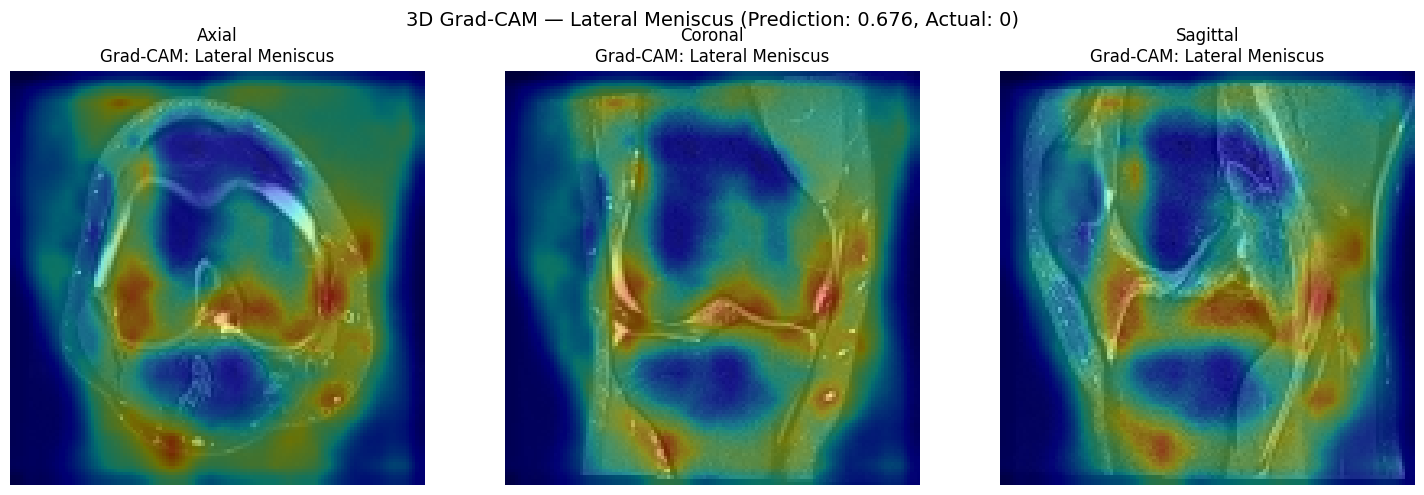

In [259]:
# VISUALIZE 3D GRAD-CAM
# Move image back to CPU
image_np = image.detach().cpu().numpy()[0]

# image_np shape = [3, 32, 128, 128]
# cam shape     = [8, 32, 32]

# Resize CAM back to the input volume size
cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0)

cam_resized = F.interpolate(
    cam_tensor,
    size=(32, 128, 128),
    mode="trilinear",
    align_corners=False
)

cam_resized = cam_resized[0, 0].numpy()

# Central depth slice
depth_idx = image_np.shape[1] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plane_names = ["Axial", "Coronal", "Sagittal"]

for i, (ax, plane) in enumerate(zip(axes, plane_names)):

    mri_slice = image_np[i, depth_idx]
    cam_slice = cam_resized[depth_idx]

    ax.imshow(mri_slice, cmap="gray")
    ax.imshow(
        cam_slice,
        cmap="jet",
        alpha=0.45,
        vmin=0,
        vmax=1
    )

    ax.set_title(f"{plane}\nGrad-CAM: {target_cols[target_class]}")
    ax.axis("off")

plt.suptitle(
    f"3D Grad-CAM — {target_cols[target_class]} "
    f"(Prediction: {probabilities[target_class]:.3f}, "
    f"Actual: {int(label_row[target_cols[target_class]])})",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [260]:
import os

print("Weak cache exists:", os.path.exists("/kaggle/working/weak_mri_cache"))
print("Weak dataset exists:", "weak_dataset" in globals())

if "weak_dataset" in globals():
    print("Weak dataset shape:", weak_dataset.shape)
    print("Columns:", weak_dataset.columns.tolist())

Weak cache exists: False
Weak dataset exists: True
Weak dataset shape: (3290, 10)
Columns: ['StudyInstanceUID', 'ACL_weak', 'Medial_Meniscus_weak', 'Lateral_Meniscus_weak', 'PF_OA_weak', 'Effusion_weak', 'Bakers_weak', 'Axial_SeriesUID', 'Coronal_SeriesUID', 'Sagittal_SeriesUID']


In [261]:
# Check overlap between official 58 labeled studies and weak-label studies
official_uids = set(train["StudyInstanceUID"].astype(str))
weak_uids = set(weak_dataset["StudyInstanceUID"].astype(str))

overlap = official_uids & weak_uids

print("Official studies:", len(official_uids))
print("Weak studies:", len(weak_uids))
print("Overlap:", len(overlap))

# Check weak-label availability
weak_label_cols = [
    "ACL_weak",
    "Medial_Meniscus_weak",
    "Lateral_Meniscus_weak",
    "PF_OA_weak",
    "Effusion_weak",
    "Bakers_weak"
]

print("\nWeak-label coverage:")
for col in weak_label_cols:
    print(f"{col:25s}: {weak_dataset[col].notna().sum()}")

print("\nAll 3 planes available:")
print(
    weak_dataset[
        ["Axial_SeriesUID", "Coronal_SeriesUID", "Sagittal_SeriesUID"]
    ].notna().all(axis=1).sum(),
    "/",
    len(weak_dataset)
)

Official studies: 4407
Weak studies: 3290
Overlap: 3290

Weak-label coverage:
ACL_weak                 : 1108
Medial_Meniscus_weak     : 2036
Lateral_Meniscus_weak    : 1915
PF_OA_weak               : 1739
Effusion_weak            : 2333
Bakers_weak              : 1070

All 3 planes available:
3290 / 3290


In [262]:
# Separate the 58 officially labeled studies from weak supervision

official_labeled_uids = set(
    train.loc[train[target_cols].notna().all(axis=1), "StudyInstanceUID"]
    .astype(str)
)

weak_train_df = weak_dataset[
    ~weak_dataset["StudyInstanceUID"].astype(str).isin(official_labeled_uids)
].copy()

print("Officially labeled studies:", len(official_labeled_uids))
print("Weak studies before removing official:", len(weak_dataset))
print("Weak studies after removing official:", len(weak_train_df))

print("\nWeak label availability:")
for col in weak_label_cols:
    print(f"{col:25s}: {weak_train_df[col].notna().sum()}")

Officially labeled studies: 58
Weak studies before removing official: 3290
Weak studies after removing official: 3290

Weak label availability:
ACL_weak                 : 1108
Medial_Meniscus_weak     : 2036
Lateral_Meniscus_weak    : 1915
PF_OA_weak               : 1739
Effusion_weak            : 2333
Bakers_weak              : 1070


In [263]:
import shutil

total, used, free = shutil.disk_usage("/kaggle/working")

print(f"Total storage : {total / (1024**3):.2f} GB")
print(f"Used storage  : {used / (1024**3):.2f} GB")
print(f"Free storage  : {free / (1024**3):.2f} GB")

Total storage : 19.52 GB
Used storage  : 0.07 GB
Free storage  : 19.43 GB


In [264]:
import os
import time
import torch

weak_cache_dir = "/kaggle/working/weak_mri_cache"
os.makedirs(weak_cache_dir, exist_ok=True)

# Only process studies that don't already have a cached file
cached = {
    os.path.splitext(f)[0]
    for f in os.listdir(weak_cache_dir)
    if f.endswith(".pt")
}

remaining = weak_train_df[
    ~weak_train_df["StudyInstanceUID"].astype(str).isin(cached)
].copy()

print("Weak studies:", len(weak_train_df))
print("Already cached:", len(cached))
print("Remaining:", len(remaining))

Weak studies: 3290
Already cached: 0
Remaining: 3290


In [265]:
import os
import time
import torch

weak_cache_dir = "/kaggle/working/weak_mri_cache"
os.makedirs(weak_cache_dir, exist_ok=True)

start_time = time.time()
success = 0
failed = 0

for i, (_, row) in enumerate(weak_train_df.iterrows(), 1):

    study_uid = str(row["StudyInstanceUID"])
    cache_path = os.path.join(weak_cache_dir, f"{study_uid}.pt")

    # Skip if already cached
    if os.path.exists(cache_path):
        success += 1
        continue

    try:
        # Load the three selected MRI series
        axial = load_series_volume(
            study_uid,
            str(row["Axial_SeriesUID"])
        )

        coronal = load_series_volume(
            study_uid,
            str(row["Coronal_SeriesUID"])
        )

        sagittal = load_series_volume(
            study_uid,
            str(row["Sagittal_SeriesUID"])
        )

        # Convert each volume to [1, 32, 128, 128]
        axial = prepare_volume(axial)
        coronal = prepare_volume(coronal)
        sagittal = prepare_volume(sagittal)

        # Combine planes → [3, 32, 128, 128]
        image = torch.cat([axial, coronal, sagittal], dim=0)

        torch.save(image, cache_path)
        success += 1

    except Exception as e:
        failed += 1
        print(f"\nFAILED {study_uid}")
        print("Error:", str(e))

    if i % 100 == 0:
        elapsed = time.time() - start_time
        print(
            f"{i}/{len(weak_train_df)} | "
            f"success={success} | failed={failed} | "
            f"elapsed={elapsed/60:.1f} min"
        )

print("\nCACHE COMPLETE")
print("Successful:", success)
print("Failed:", failed)
print(
    "Time:",
    round((time.time() - start_time) / 60, 2),
    "minutes"
)

100/3290 | success=100 | failed=0 | elapsed=2.5 min
200/3290 | success=200 | failed=0 | elapsed=4.9 min
300/3290 | success=300 | failed=0 | elapsed=7.5 min
400/3290 | success=400 | failed=0 | elapsed=9.4 min
500/3290 | success=500 | failed=0 | elapsed=11.5 min
600/3290 | success=600 | failed=0 | elapsed=13.7 min
700/3290 | success=700 | failed=0 | elapsed=16.1 min
800/3290 | success=800 | failed=0 | elapsed=18.5 min
900/3290 | success=900 | failed=0 | elapsed=20.6 min
1000/3290 | success=1000 | failed=0 | elapsed=22.8 min
1100/3290 | success=1100 | failed=0 | elapsed=24.6 min
1200/3290 | success=1200 | failed=0 | elapsed=27.3 min
1300/3290 | success=1300 | failed=0 | elapsed=29.1 min
1400/3290 | success=1400 | failed=0 | elapsed=31.2 min

FAILED 1.2.826.0.1.3680043.8.498.34685905030370793639196564723935583035
Error: The number of bytes of pixel data is less than expected (409600 vs 819200 bytes) - the dataset may be corrupted, have an invalid group 0028 element value, or the transfer s

In [266]:
import os
import shutil

cache_files = [
    f for f in os.listdir("/kaggle/working/weak_mri_cache")
    if f.endswith(".pt")
]

total, used, free = shutil.disk_usage("/kaggle/working")

print("Weak MRI cache files:", len(cache_files))
print(f"Cache size: {sum(os.path.getsize(os.path.join('/kaggle/working/weak_mri_cache', f)) for f in cache_files) / (1024**3):.2f} GB")
print(f"Free storage: {free / (1024**3):.2f} GB")

Weak MRI cache files: 3288
Cache size: 19.27 GB
Free storage: 0.15 GB


In [267]:
import os

for path in [
    "/kaggle/working/weak_mri_cache",
    "/kaggle/working/clean_eval_cache",
    "/kaggle/working/baseline_model.pth",
    "/kaggle/working/weak_supervised_model_epoch1.pth",
    "/kaggle/working/weak_supervised_model_epoch2.pth"
]:
    if os.path.exists(path):
        if os.path.isfile(path):
            size = os.path.getsize(path) / (1024**2)
            print(f"{path}: {size:.2f} MB")
        else:
            size = sum(
                os.path.getsize(os.path.join(root, f))
                for root, _, files in os.walk(path)
                for f in files
            ) / (1024**3)
            print(f"{path}: {size:.2f} GB")

/kaggle/working/weak_mri_cache: 19.27 GB
/kaggle/working/clean_eval_cache: 0.07 GB
/kaggle/working/baseline_model.pth: 0.86 MB
/kaggle/working/weak_supervised_model_epoch1.pth: 0.86 MB
/kaggle/working/weak_supervised_model_epoch2.pth: 0.86 MB


In [268]:
print("train_df exists:", "train_df" in globals())
print("train_dataset exists:", "train_dataset" in globals())
print("val_df exists:", "val_df" in globals())

if "train_df" in globals():
    print("Clean training studies:", len(train_df))

if "val_df" in globals():
    print("Clean validation studies:", len(val_df))

train_df exists: True
train_dataset exists: True
val_df exists: True
Clean training studies: 46
Clean validation studies: 12


In [269]:
from torch.utils.data import Dataset
import torch
import os
import numpy as np

weak_label_cols = [
    "ACL_weak",
    "Medial_Meniscus_weak",
    "Lateral_Meniscus_weak",
    "PF_OA_weak",
    "Effusion_weak",
    "Bakers_weak"
]

# Mapping weak labels → positions in the 12-class output
weak_to_target = {
    "ACL_weak": 0,
    "Medial_Meniscus_weak": 2,
    "Lateral_Meniscus_weak": 3,
    "PF_OA_weak": 6,
    "Effusion_weak": 7,
    "Bakers_weak": 9
}

class CombinedKneeDataset(Dataset):

    def __init__(self, clean_dataset, weak_df, weak_cache_dir):
        self.clean_dataset = clean_dataset
        self.weak_df = weak_df.reset_index(drop=True)
        self.weak_cache_dir = weak_cache_dir

        self.n_clean = len(clean_dataset)
        self.n_weak = len(self.weak_df)

    def __len__(self):
        return self.n_clean + self.n_weak

    def __getitem__(self, idx):

        # Clean official sample
        if idx < self.n_clean:

            image, labels = self.clean_dataset[idx]

            labels = torch.as_tensor(
                labels,
                dtype=torch.float32
            )

            # All 12 labels are valid
            mask = torch.ones(12, dtype=torch.bool)

            # Strong supervision
            weight = torch.tensor(1.0)

            return image, labels, mask, weight

        # Weakly supervised sample
        widx = idx - self.n_clean
        row = self.weak_df.iloc[widx]

        study_uid = str(row["StudyInstanceUID"])

        cache_path = os.path.join(
            self.weak_cache_dir,
            f"{study_uid}.pt"
        )

        image = torch.load(
            cache_path,
            map_location="cpu",
            weights_only=True
        )

        # Start with unknown labels
        labels = torch.zeros(12, dtype=torch.float32)
        mask = torch.zeros(12, dtype=torch.bool)

        # Insert only available weak labels
        for weak_col, target_idx in weak_to_target.items():

            value = row[weak_col]

            if not pd.isna(value):
                labels[target_idx] = float(value)
                mask[target_idx] = True

        # Weak supervision gets lower loss weight
        weight = torch.tensor(0.35)

        return image, labels, mask, weight

In [270]:
import pandas as pd

In [271]:
combined_dataset = CombinedKneeDataset(
    clean_dataset=train_dataset,
    weak_df=weak_train_df,
    weak_cache_dir="/kaggle/working/weak_mri_cache"
)

print("Combined dataset size:", len(combined_dataset))
print("Clean samples:", len(train_dataset))
print("Weak samples:", len(weak_train_df))

# Test one clean sample
x, y, mask, weight = combined_dataset[0]

print("\nClean sample:")
print("Image:", x.shape)
print("Labels:", y.shape)
print("Valid labels:", mask.sum().item())
print("Weight:", weight.item())

# Test one weak sample
x, y, mask, weight = combined_dataset[len(train_dataset)]

print("\nWeak sample:")
print("Image:", x.shape)
print("Labels:", y.shape)
print("Valid labels:", mask.sum().item())
print("Weight:", weight.item())

Combined dataset size: 3336
Clean samples: 46
Weak samples: 3290

Clean sample:
Image: torch.Size([3, 32, 128, 128])
Labels: torch.Size([12])
Valid labels: 12
Weight: 1.0

Weak sample:
Image: torch.Size([3, 32, 128, 128])
Labels: torch.Size([12])
Valid labels: 1
Weight: 0.3499999940395355
